# Temporal Stability of 6D Head Pose Estimation on BIWI-360 Video Sequences

**Authors:** Hugo García Souto and Adrián Martínez Balea  
**Course:** Computer Vision II — Master's Degree in Artificial Intelligence, Universidade de Santiago de Compostela

In this project, we study video-based head pose estimation within the context of gaze and pose-based interaction. Our goal is to evaluate not only the frame-level accuracy of a head pose estimator, but also the temporal stability of its predictions across consecutive frames.

We use BIWI-360, the fisheye-distorted version of the BIWI head pose benchmark included in HPE-360. This dataset allows us to study head pose estimation under a realistic domain shift caused by fisheye distortion.

Our research question is:

**Can a frame-by-frame 6D head pose estimator remain accurate and temporally stable on BIWI-360 video sequences, and can temporal post-processing reduce prediction jitter under fisheye distortion?**

In [87]:
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")
DATASETS_ROOT = INPUT_ROOT / "datasets"

HPE360_ROOT = DATASETS_ROOT / "nn1966" / "hpe-360" / "HPE-360" / "HPE-360"
BIWI_ROOT = HPE360_ROOT / "BIWI-360"

print("Available Kaggle inputs:")
for p in sorted(INPUT_ROOT.iterdir()):
    print(" -", p)

print("\nExpected HPE-360 root:", HPE360_ROOT)
print("HPE-360 root exists:", HPE360_ROOT.exists())

print("\nExpected BIWI-360 root:", BIWI_ROOT)
print("BIWI-360 root exists:", BIWI_ROOT.exists())

if not BIWI_ROOT.exists():
    raise FileNotFoundError("BIWI-360 was not found at the expected path. Please check the Kaggle input structure.")

Available Kaggle inputs:
 - /kaggle/input/datasets

Expected HPE-360 root: /kaggle/input/datasets/nn1966/hpe-360/HPE-360/HPE-360
HPE-360 root exists: True

Expected BIWI-360 root: /kaggle/input/datasets/nn1966/hpe-360/HPE-360/HPE-360/BIWI-360
BIWI-360 root exists: True


## 1. Dataset inspection

Before running any model, we first inspect the structure of the BIWI-360 dataset. This step is important because the dataset is organized as video sequences, and each sequence should contain RGB frames together with a corresponding label file.

We will check the number of available sequences, the number of label files, and the number of RGB frames per sequence.

In [88]:
print("BIWI-360 root:", BIWI_ROOT)

sequence_dirs = sorted([p for p in BIWI_ROOT.iterdir() if p.is_dir() and p.name.isdigit()])
label_files = sorted(BIWI_ROOT.glob("label*_planB.mat"))

print(f"\nNumber of sequence folders: {len(sequence_dirs)}")
print(f"Number of label files: {len(label_files)}")

print("\nFrames per sequence:")
for seq_dir in sequence_dirs:
    rgb_frames = sorted(seq_dir.glob("*_rgb.png"))
    print(f"Sequence {seq_dir.name}: {len(rgb_frames)} RGB frames")

print("\nFirst label files:")
for label_file in label_files[:10]:
    print(" -", label_file.name)

BIWI-360 root: /kaggle/input/datasets/nn1966/hpe-360/HPE-360/HPE-360/BIWI-360

Number of sequence folders: 24
Number of label files: 24

Frames per sequence:
Sequence 01: 499 RGB frames
Sequence 02: 511 RGB frames
Sequence 03: 730 RGB frames
Sequence 04: 744 RGB frames
Sequence 05: 946 RGB frames
Sequence 06: 542 RGB frames
Sequence 07: 745 RGB frames
Sequence 08: 772 RGB frames
Sequence 09: 882 RGB frames
Sequence 10: 726 RGB frames
Sequence 11: 572 RGB frames
Sequence 12: 732 RGB frames
Sequence 13: 485 RGB frames
Sequence 14: 797 RGB frames
Sequence 15: 654 RGB frames
Sequence 16: 914 RGB frames
Sequence 17: 395 RGB frames
Sequence 18: 614 RGB frames
Sequence 19: 502 RGB frames
Sequence 20: 556 RGB frames
Sequence 21: 634 RGB frames
Sequence 22: 665 RGB frames
Sequence 23: 569 RGB frames
Sequence 24: 492 RGB frames

First label files:
 - label01_planB.mat
 - label02_planB.mat
 - label03_planB.mat
 - label04_planB.mat
 - label05_planB.mat
 - label06_planB.mat
 - label07_planB.mat
 - 

## 2. Label file inspection

The BIWI-360 dataset provides one `.mat` label file per video sequence. Before building the frame-level dataset table, we inspect the internal structure of one label file to understand which variables are available and how they are shaped.

This will allow us to identify the ground-truth head pose annotations and match them with the RGB frames.

In [89]:
import scipy.io as sio

sample_label_file = label_files[0]
mat = sio.loadmat(sample_label_file)

print("Loaded label file:", sample_label_file.name)
print("\nAvailable keys:")

for key, value in mat.items():
    if not key.startswith("__"):
        print(f"{key}: type={type(value)}, shape={getattr(value, 'shape', None)}, dtype={getattr(value, 'dtype', None)}")

Loaded label file: label01_planB.mat

Available keys:
label_360: type=<class 'numpy.ndarray'>, shape=(499, 7), dtype=float64


### 2.1 Inspecting the label values

The first label file contains a single array named `label_360` with one row per RGB frame. We now inspect the first and last rows, together with the minimum and maximum value of each column, to infer the meaning of the seven columns.

At this stage, we do not rename the columns yet. We first verify their numerical ranges and how they correspond to the frame files.

In [90]:
import numpy as np
import pandas as pd

labels = mat["label_360"]

print("Label array shape:", labels.shape)

print("\nFirst 10 rows:")
display(pd.DataFrame(labels[:10]))

print("\nLast 10 rows:")
display(pd.DataFrame(labels[-10:]))

summary = pd.DataFrame({
    "min": labels.min(axis=0),
    "max": labels.max(axis=0),
    "mean": labels.mean(axis=0),
    "std": labels.std(axis=0)
})

print("\nColumn-wise summary:")
display(summary)

seq01_dir = BIWI_ROOT / "01"
seq01_frames = sorted(seq01_dir.glob("*_rgb.png"))

print("\nFirst 10 RGB frame filenames:")
for frame_path in seq01_frames[:10]:
    print(frame_path.name)

print("\nLast 10 RGB frame filenames:")
for frame_path in seq01_frames[-10:]:
    print(frame_path.name)

print("\nNumber of labels:", len(labels))
print("Number of RGB frames:", len(seq01_frames))

Label array shape: (499, 7)

First 10 rows:


,0,1,2,3,4,5,6
0,1.0,3.0,3.290994,-1.566632,7.607223,0.250498,-74.249642
1,1.0,4.0,3.889411,-1.930131,7.650885,0.465149,139.762830
2,1.0,5.0,3.664672,-1.946089,7.445381,0.670615,11.398345
3,1.0,6.0,3.795917,-1.896884,7.455991,0.756483,-98.073602
4,1.0,7.0,3.433040,-2.123386,7.729789,0.255294,101.986555
5,1.0,8.0,4.065578,-2.239335,7.529910,0.434607,-55.281263
6,1.0,9.0,3.619380,-1.837812,7.553633,0.322843,85.592478
7,1.0,10.0,3.785949,-2.175483,7.680194,0.279801,38.692073
8,1.0,11.0,3.594780,-2.192630,7.481102,0.503373,20.933092
9,1.0,12.0,3.791450,-1.956757,7.585290,0.290940,43.844597



Last 10 rows:


,0,1,2,3,4,5,6
0,1.0,492.0,-50.809113,41.742519,-56.415729,0.307111,-164.292400
1,1.0,493.0,-51.674920,40.173139,-55.161984,0.617853,77.969602
2,1.0,494.0,-52.374968,39.304608,-54.305304,0.116012,-30.242918
3,1.0,495.0,-51.567869,42.315288,-56.303669,0.072047,157.130696
4,1.0,496.0,-51.469255,41.025681,-54.961993,0.253545,52.833340
5,1.0,497.0,-51.680464,41.945054,-54.828453,0.410843,163.372422
6,1.0,498.0,-51.819007,41.816200,-56.548215,0.682507,-126.461582
7,1.0,499.0,-52.005886,41.772323,-55.555400,0.002198,-49.182329
8,1.0,500.0,-51.951749,41.825209,-55.759139,0.168659,-23.776903
9,1.0,501.0,-52.375719,41.554203,-54.919936,0.526956,-140.135868



Column-wise summary:


,min,max,mean,std
0,1.000000,1.000000,1.000000,0.000000
1,3.000000,501.000000,252.000000,144.048603
2,-64.346146,59.152489,2.292873,34.587135
3,-39.685246,44.679199,3.442469,17.215347
4,-57.487375,40.418107,-7.782420,30.723731
5,0.002198,0.799191,0.413519,0.222907
6,-178.484923,179.695795,1.381277,104.835364



First 10 RGB frame filenames:
frame_00003_rgb.png
frame_00004_rgb.png
frame_00005_rgb.png
frame_00006_rgb.png
frame_00007_rgb.png
frame_00008_rgb.png
frame_00009_rgb.png
frame_00010_rgb.png
frame_00011_rgb.png
frame_00012_rgb.png

Last 10 RGB frame filenames:
frame_00492_rgb.png
frame_00493_rgb.png
frame_00494_rgb.png
frame_00495_rgb.png
frame_00496_rgb.png
frame_00497_rgb.png
frame_00498_rgb.png
frame_00499_rgb.png
frame_00500_rgb.png
frame_00501_rgb.png

Number of labels: 499
Number of RGB frames: 499


### 2.2 Dataset documentation files

The label array appears to contain the sequence id, frame id, three head pose angles, and two additional metadata values. Before assigning final column names, we inspect the dataset directory for documentation files such as README files or text files that may describe the label format.

In [91]:
readme_files = [
    DATASETS_ROOT / "nn1966" / "hpe-360" / "README.txt",
    HPE360_ROOT / "README.txt",
    BIWI_ROOT / "label_biwi.txt",
]

for path in readme_files:
    print("=" * 100)
    print(path)
    print("=" * 100)
    
    if path.exists():
        text = path.read_text(errors="ignore")
        print(text[:4000])
    else:
        print("File not found.")
    
    print()

/kaggle/input/datasets/nn1966/hpe-360/README.txt
数据集名称 
HPE-360
The fisheye-distorted version of three popular public benchmark datasets.

数据集描述
我们在三个开源且流行的头部姿态估计数据集，BIWI，300W-LP，AFLW2000，上创建了对应的鱼眼失真版本。我们将新的鱼眼失真数据集命名为BIWI-360，300W-LP-360，AFLW2000-360，并将三个鱼眼失真数据集打包命名为HPE-360。我们使用相同的映射函数去执行原始图片到鱼眼失真图像的转换，同时对于鱼眼失真版本的头部姿态仍使用原始的头部姿态groundtruth。

数据来源
（说明数据的来源，包括数据收集的时间、地点和方法。）
由于鱼眼畸变数据集是已有的公开数据集的合成版本，因此只对鱼眼畸变的生成方式进行说明。对于原数据集中的直线图像，首先将人脸区域裁剪出来，然后创建一个五倍于人脸区域高和宽的画布，将人脸区域的中心点随机放置在画布的某个位置P处，P由极坐标rho和theta来表示。rho和theta分别从（0，0.8）以及（-180，180）的均匀分布中采样。接着使用特定的映射函数生成鱼眼畸变效果。最后将畸变后的人脸区域从画布上裁剪出来。

数据集结构
HPE-360
	AFLW2000-360
		image00002.jpg
		....
		label_aflw2000.txt
	BIWI-360
		01
		....
		label_biwi.txt
	300W-LP-360
		AFW
		AFW_Flip
		HELEN
		...
		label_300wlp.txt
	README

数据字段说明
（如果数据集包含表格数据，列出每个字段的名称和含义。）
AFLW2000-360 的标注文件为 label_aflw2000.txt 
BIWI-360 的标注文件为 label_biwi.txt
300W-LP-360 的标注文件为 label_300wlp.txt
txt文件中每行的内容为：图片路径   yaw   roll   pitch   rho   theta(°)
（注：rho为归一化径向位置，其范围为0-0.8）

数据集规模

### 2.3 Building the frame-level annotation table

According to the dataset documentation, each BIWI-360 annotation contains the image path followed by the head pose angles and the fisheye location parameters:

`image_path, yaw, roll, pitch, rho, theta`

In the `.mat` files, this information is stored numerically as:

`sequence_id, frame_id, yaw, roll, pitch, rho, theta`

Here, `rho` is the normalized radial position used to place the face before fisheye distortion, and `theta` is the angular position in degrees. We keep these two values as metadata because they may help us analyze failure cases related to fisheye distortion.

We now build a single frame-level table containing all BIWI-360 sequences.

## 3. Visual sanity check

The annotation table contains 15,678 frames and all referenced image files exist. We now visualize a few evenly spaced frames from one BIWI-360 sequence together with their ground-truth head pose and fisheye distortion metadata.

This helps us verify that the RGB images are correctly matched with the labels before moving to temporal analysis or model inference.

In [92]:
import scipy.io as sio
import pandas as pd
from pathlib import Path

records = []

for label_file in sorted(BIWI_ROOT.glob("label*_planB.mat")):
    labels = sio.loadmat(label_file)["label_360"]
    
    for row in labels:
        sequence_id = int(row[0])
        frame_id = int(row[1])
        
        image_path = BIWI_ROOT / f"{sequence_id:02d}" / f"frame_{frame_id:05d}_rgb.png"
        
        records.append({
            "sequence_id": sequence_id,
            "frame_id": frame_id,
            "image_path": str(image_path),
            "yaw": float(row[2]),
            "roll": float(row[3]),
            "pitch": float(row[4]),
            "rho": float(row[5]),
            "theta": float(row[6]),
        })

df = pd.DataFrame(records)

print("Frame-level table shape:", df.shape)
print("\nFirst rows:")
display(df.head())

print("\nLast rows:")
display(df.tail())

print("\nNumber of frames per sequence:")
display(df.groupby("sequence_id").size().rename("num_frames").reset_index())

print("\nMissing image files:", (~df["image_path"].apply(lambda p: Path(p).exists())).sum())

print("\nPose and fisheye metadata summary:")
display(df[["yaw", "roll", "pitch", "rho", "theta"]].describe())

Frame-level table shape: (15678, 8)

First rows:


,sequence_id,frame_id,image_path,yaw,roll,pitch,rho,theta
0,1,3,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,3.290994,-1.566632,7.607223,0.250498,-74.249642
1,1,4,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,3.889411,-1.930131,7.650885,0.465149,139.762830
2,1,5,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,3.664672,-1.946089,7.445381,0.670615,11.398345
3,1,6,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,3.795917,-1.896884,7.455991,0.756483,-98.073602
4,1,7,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,3.433040,-2.123386,7.729789,0.255294,101.986555



Last rows:


,sequence_id,frame_id,image_path,yaw,roll,pitch,rho,theta
15673,24,618,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,1.649785,-2.091429,27.829273,0.247761,-87.856909
15674,24,619,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,2.348748,-1.574616,27.642538,0.590965,-34.187572
15675,24,620,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,1.891242,-1.413197,26.657115,0.265551,-77.702273
15676,24,621,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,2.681086,-1.915508,25.749074,0.145223,124.581460
15677,24,622,/kaggle/input/datasets/nn1966/hpe-360/HPE-360/...,3.647070,-1.810187,23.973104,0.523816,-170.417969



Number of frames per sequence:


,sequence_id,num_frames
0,1,499
1,2,511
2,3,730
3,4,744
4,5,946
5,6,542
6,7,745
7,8,772
8,9,882
9,10,726



Missing image files: 0

Pose and fisheye metadata summary:


,yaw,roll,pitch,rho,theta
count,15678.000000,15678.000000,15678.000000,15678.000000,15678.000000
mean,7.920360,0.065513,9.257203,0.400516,0.301844
std,29.898830,13.294906,25.788349,0.230891,103.915334
min,-74.889528,-64.699638,-63.826999,0.000047,-179.959768
25%,-8.647094,-5.117293,-4.909459,0.198906,-89.080091
50%,6.094983,-0.318907,13.050165,0.399797,0.629272
75%,29.868050,5.943581,24.647709,0.599690,89.579228
max,77.971758,45.018895,84.369888,0.799940,179.977079


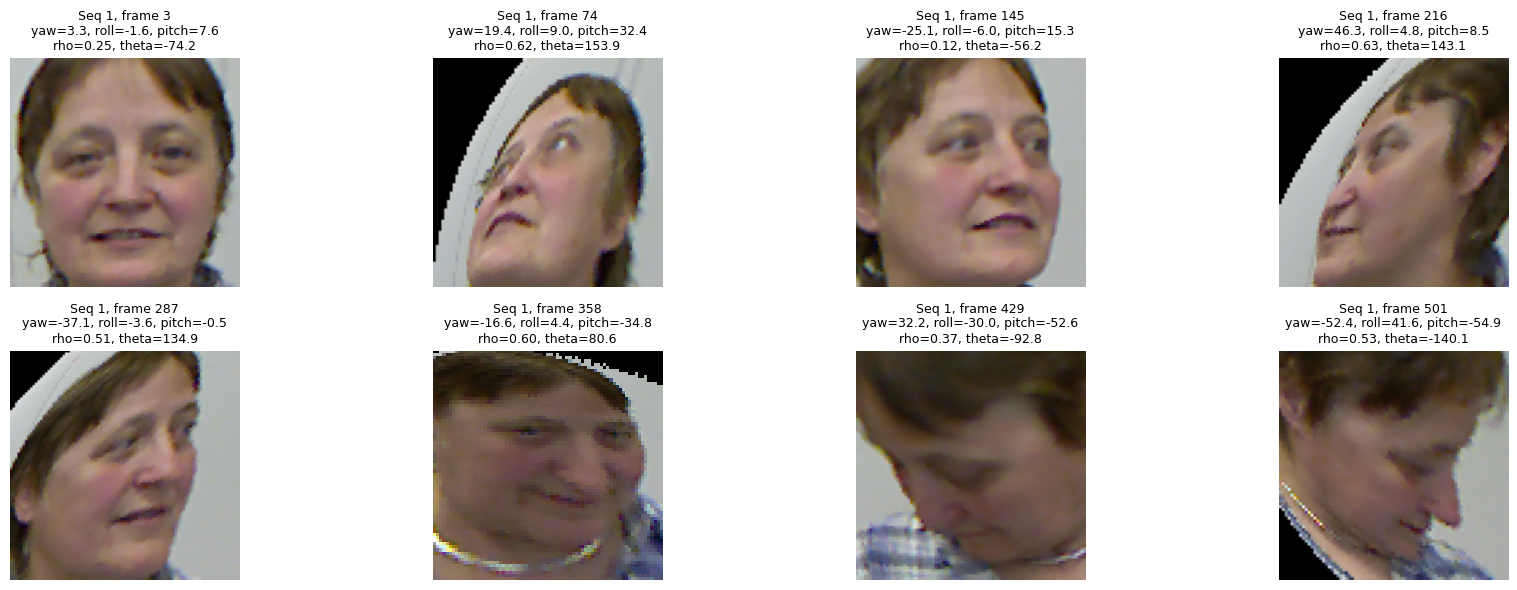

In [93]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

sample_sequence_id = 1
sample_df = df[df["sequence_id"] == sample_sequence_id].reset_index(drop=True)

sample_indices = np.linspace(0, len(sample_df) - 1, 8, dtype=int)
sample_rows = sample_df.iloc[sample_indices]

plt.figure(figsize=(18, 6))

for i, (_, row) in enumerate(sample_rows.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Seq {int(row['sequence_id'])}, frame {int(row['frame_id'])}\n"
        f"yaw={row['yaw']:.1f}, roll={row['roll']:.1f}, pitch={row['pitch']:.1f}\n"
        f"rho={row['rho']:.2f}, theta={row['theta']:.1f}",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## 4. Ground-truth temporal dynamics

Since our project focuses on video-based head pose estimation, we first analyze the temporal behavior of the ground-truth annotations. This allows us to understand how yaw, roll and pitch evolve across each BIWI-360 sequence.

We also compute a simple frame-to-frame motion magnitude based on the change in the three head pose angles. This will later help us identify fast-rotation regions, where temporal smoothing may reduce jitter but can also introduce lag.

Sequences sorted by average ground-truth frame-to-frame motion:


,sequence_id,num_frames,mean_abs_d_yaw,mean_abs_d_roll,mean_abs_d_pitch,mean_motion,max_motion
5,6,542,1.604304,1.769256,1.881088,3.525679,89.319183
20,21,634,1.466508,1.832553,1.634285,3.381508,23.939624
17,18,614,1.552501,1.403594,1.482300,3.004947,39.506805
22,23,569,1.509717,1.394925,1.272115,2.834752,49.203724
14,15,654,1.480130,1.502836,1.131363,2.782862,12.895282
18,19,502,1.508842,1.298426,1.083966,2.664223,11.023587
13,14,797,1.524503,1.352240,0.987444,2.616162,9.800047
16,17,395,1.476455,1.186578,1.031588,2.537387,15.323107
15,16,914,1.351605,1.160932,1.205906,2.505490,28.953744
23,24,492,1.499251,0.575445,1.281401,2.421893,21.873022


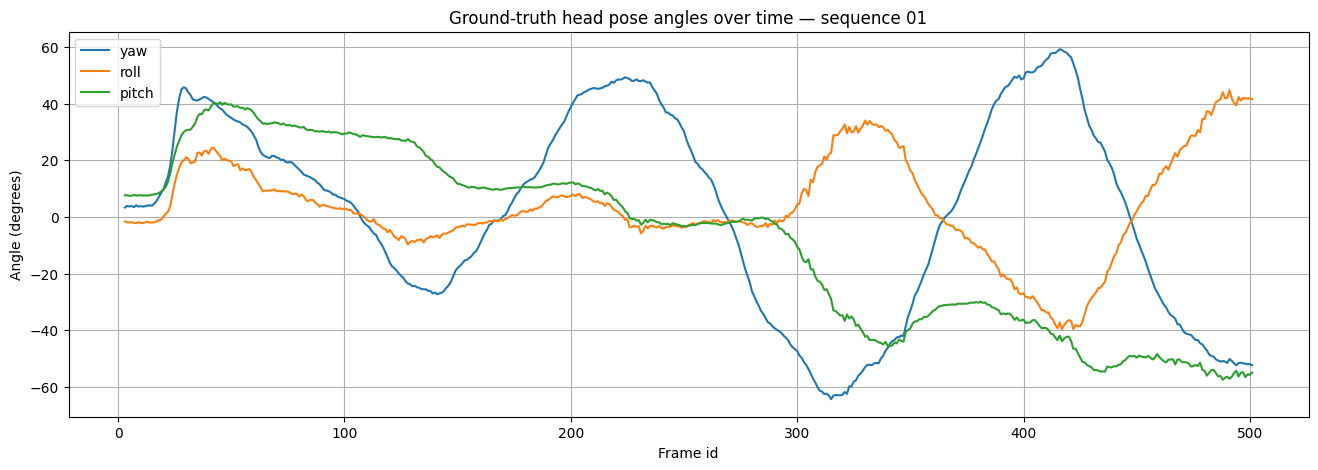

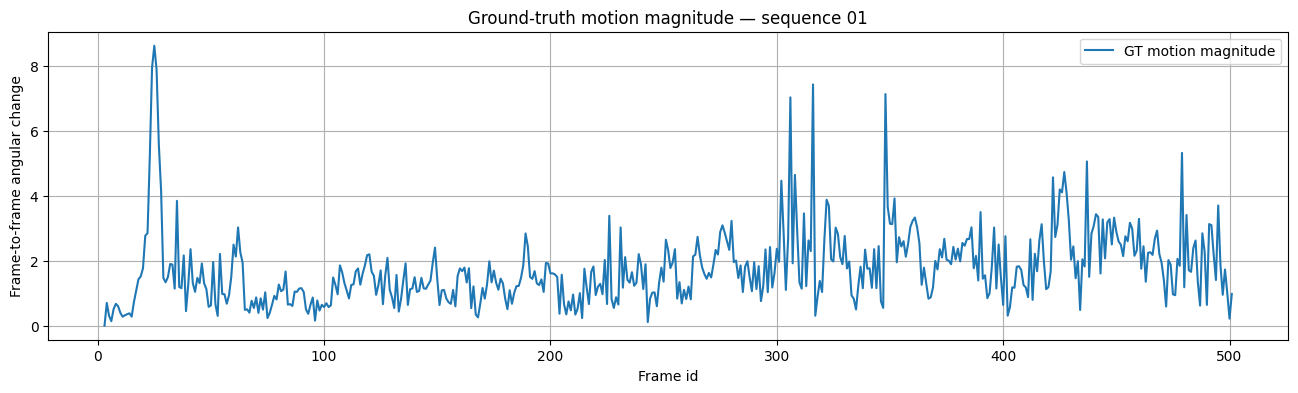

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def add_temporal_deltas(dataframe):
    df_out = dataframe.sort_values(["sequence_id", "frame_id"]).copy()
    
    for angle in ["yaw", "roll", "pitch"]:
        df_out[f"d_{angle}"] = df_out.groupby("sequence_id")[angle].diff()
        df_out[f"abs_d_{angle}"] = df_out[f"d_{angle}"].abs()
    
    df_out["gt_motion_magnitude"] = np.sqrt(
        df_out["d_yaw"].fillna(0) ** 2 +
        df_out["d_roll"].fillna(0) ** 2 +
        df_out["d_pitch"].fillna(0) ** 2
    )
    
    return df_out

df = add_temporal_deltas(df)

motion_summary = (
    df.groupby("sequence_id")
    .agg(
        num_frames=("frame_id", "count"),
        mean_abs_d_yaw=("abs_d_yaw", "mean"),
        mean_abs_d_roll=("abs_d_roll", "mean"),
        mean_abs_d_pitch=("abs_d_pitch", "mean"),
        mean_motion=("gt_motion_magnitude", "mean"),
        max_motion=("gt_motion_magnitude", "max"),
    )
    .reset_index()
    .sort_values("mean_motion", ascending=False)
)

print("Sequences sorted by average ground-truth frame-to-frame motion:")
display(motion_summary)

# Plot one representative sequence
sample_sequence_id = 1
seq_df = df[df["sequence_id"] == sample_sequence_id].sort_values("frame_id").reset_index(drop=True)

plt.figure(figsize=(16, 5))
plt.plot(seq_df["frame_id"], seq_df["yaw"], label="yaw")
plt.plot(seq_df["frame_id"], seq_df["roll"], label="roll")
plt.plot(seq_df["frame_id"], seq_df["pitch"], label="pitch")
plt.xlabel("Frame id")
plt.ylabel("Angle (degrees)")
plt.title(f"Ground-truth head pose angles over time — sequence {sample_sequence_id:02d}")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(seq_df["frame_id"], seq_df["gt_motion_magnitude"], label="GT motion magnitude")
plt.xlabel("Frame id")
plt.ylabel("Frame-to-frame angular change")
plt.title(f"Ground-truth motion magnitude — sequence {sample_sequence_id:02d}")
plt.legend()
plt.grid(True)
plt.show()

### 4.1 Inspecting high-motion events

The previous summary shows that some sequences contain much larger frame-to-frame pose changes than others. Before using these values to define fast-rotation regions, we inspect the largest motion events directly.

This helps us distinguish between genuine fast head rotations and possible annotation discontinuities or isolated outlier frames.

In [95]:
# Add previous frame information to inspect temporal continuity
df = df.sort_values(["sequence_id", "frame_id"]).copy()
df["prev_frame_id"] = df.groupby("sequence_id")["frame_id"].shift(1)
df["frame_gap"] = df["frame_id"] - df["prev_frame_id"]

top_motion_events = (
    df.dropna(subset=["prev_frame_id"])
    .sort_values("gt_motion_magnitude", ascending=False)
    .head(15)
    .copy()
)

cols_to_show = [
    "sequence_id", "prev_frame_id", "frame_id", "frame_gap",
    "yaw", "roll", "pitch",
    "d_yaw", "d_roll", "d_pitch",
    "gt_motion_magnitude", "rho", "theta"
]

print("Top frame-to-frame ground-truth motion events:")
display(top_motion_events[cols_to_show])

Top frame-to-frame ground-truth motion events:


,sequence_id,prev_frame_id,frame_id,frame_gap,yaw,roll,pitch,d_yaw,d_roll,d_pitch,gt_motion_magnitude,rho,theta
3795,6,364.0,389,25.0,21.347407,7.994134,66.860206,44.136246,-5.617533,77.449026,89.319183,0.211457,-18.920760
15130,23,512.0,579,67.0,28.157506,3.792424,21.993601,44.477462,-17.601795,11.529899,49.203724,0.481628,-73.632074
1682,3,674.0,683,9.0,12.241342,6.473249,-29.950556,40.091381,-14.879265,-1.948867,42.807819,0.322851,42.022116
12197,18,586.0,657,71.0,14.427515,-14.353755,13.944971,17.299827,-27.786437,-22.122783,39.506805,0.623778,-75.652655
12239,18,698.0,735,37.0,20.089098,33.500744,27.444129,28.645330,25.186956,-7.132467,38.804765,0.503953,-49.958129
11037,16,699.0,700,1.0,-4.531611,-23.328480,62.114505,11.837307,-23.144250,12.749163,28.953744,0.401233,46.038523
3412,5,930.0,931,1.0,-28.822712,7.258646,-1.304977,13.677272,-7.304183,21.672142,26.647713,0.380116,75.336407
11191,16,853.0,884,31.0,38.345789,3.644984,32.114347,25.076622,7.759899,3.638653,26.500807,0.557330,-23.373476
12127,18,480.0,481,1.0,-0.385993,-1.150562,81.481695,-0.771443,-21.339117,15.294205,26.265295,0.423622,-122.498173
15132,23,580.0,773,193.0,1.044262,-0.306037,17.738829,-25.391873,-3.431417,-3.175609,25.818721,0.377761,51.268127


### 4.2 Handling frame gaps

The inspection of high-motion events shows that some large pose changes occur when the frame id jumps by more than one. Therefore, these events are not true one-frame changes, but changes between two available annotated frames separated by a temporal gap.

To avoid overestimating fast motion, we separate two concepts:

- `observed_motion_magnitude`: angular change between two consecutive available rows in the dataset.
- `motion_per_frame`: the same angular change normalized by the frame id gap.
- `consecutive_motion_magnitude`: angular change only when the frame gap is exactly 1.

For temporal jitter analysis, we will mainly rely on consecutive-frame pairs, because they represent the actual frame-to-frame behavior of the sequence.

In [96]:
# Recompute temporal quantities while explicitly handling frame gaps
df = df.sort_values(["sequence_id", "frame_id"]).copy()

df["prev_frame_id"] = df.groupby("sequence_id")["frame_id"].shift(1)
df["frame_gap"] = df["frame_id"] - df["prev_frame_id"]

for angle in ["yaw", "roll", "pitch"]:
    df[f"d_{angle}"] = df.groupby("sequence_id")[angle].diff()
    df[f"abs_d_{angle}"] = df[f"d_{angle}"].abs()

df["observed_motion_magnitude"] = np.sqrt(
    df["d_yaw"].fillna(0) ** 2 +
    df["d_roll"].fillna(0) ** 2 +
    df["d_pitch"].fillna(0) ** 2
)

df["motion_per_frame"] = df["observed_motion_magnitude"] / df["frame_gap"]

df["is_consecutive_pair"] = df["frame_gap"] == 1

df["consecutive_motion_magnitude"] = np.where(
    df["is_consecutive_pair"],
    df["observed_motion_magnitude"],
    np.nan
)

gap_summary = (
    df.dropna(subset=["frame_gap"])
    .groupby("sequence_id")
    .agg(
        num_pairs=("frame_gap", "count"),
        consecutive_pairs=("is_consecutive_pair", "sum"),
        non_consecutive_pairs=("is_consecutive_pair", lambda x: (~x).sum()),
        max_frame_gap=("frame_gap", "max"),
        mean_consecutive_motion=("consecutive_motion_magnitude", "mean"),
        max_consecutive_motion=("consecutive_motion_magnitude", "max"),
        mean_motion_per_frame=("motion_per_frame", "mean"),
        max_motion_per_frame=("motion_per_frame", "max"),
    )
    .reset_index()
    .sort_values("mean_consecutive_motion", ascending=False)
)

print("Frame gap and corrected motion summary:")
display(gap_summary)

print("\nLargest true consecutive-frame motion events:")
display(
    df[df["is_consecutive_pair"]]
    .sort_values("consecutive_motion_magnitude", ascending=False)
    .head(15)[
        [
            "sequence_id", "prev_frame_id", "frame_id", "frame_gap",
            "yaw", "roll", "pitch",
            "d_yaw", "d_roll", "d_pitch",
            "consecutive_motion_magnitude",
            "rho", "theta"
        ]
    ]
)

Frame gap and corrected motion summary:


,sequence_id,num_pairs,consecutive_pairs,non_consecutive_pairs,max_frame_gap,mean_consecutive_motion,max_consecutive_motion,mean_motion_per_frame,max_motion_per_frame
5,6,541,539,2,34.0,3.361788,18.854102,3.356486,18.854102
20,21,633,628,5,56.0,3.297967,23.939624,3.281727,23.939624
17,18,613,609,4,71.0,2.849727,26.265295,2.836422,26.265295
14,15,653,651,2,30.0,2.783583,12.895282,2.775543,12.895282
22,23,568,566,2,193.0,2.717228,11.919311,2.709189,11.919311
18,19,501,500,1,22.0,2.669663,11.023587,2.664571,11.023587
13,14,796,796,0,1.0,2.619449,9.800047,2.619449,9.800047
16,17,394,392,2,45.0,2.492552,15.323107,2.481408,15.323107
15,16,913,911,2,31.0,2.471317,28.953744,2.467505,28.953744
23,24,491,489,2,84.0,2.362625,10.669820,2.354259,10.669820



Largest true consecutive-frame motion events:


,sequence_id,prev_frame_id,frame_id,frame_gap,yaw,roll,pitch,d_yaw,d_roll,d_pitch,consecutive_motion_magnitude,rho,theta
11037,16,699.0,700,1.0,-4.531611,-23.328480,62.114505,11.837307,-23.144250,12.749163,28.953744,0.401233,46.038523
3412,5,930.0,931,1.0,-28.822712,7.258646,-1.304977,13.677272,-7.304183,21.672142,26.647713,0.380116,75.336407
12127,18,480.0,481,1.0,-0.385993,-1.150562,81.481695,-0.771443,-21.339117,15.294205,26.265295,0.423622,-122.498173
11048,16,710.0,711,1.0,1.993040,23.932825,-11.547316,-15.563452,15.706857,10.507836,24.481443,0.126256,-56.713146
13457,21,138.0,139,1.0,-69.553207,2.718918,18.317681,-0.374926,-18.473249,15.221829,23.939624,0.090083,-18.011050
13670,21,358.0,359,1.0,3.818794,3.343178,62.249247,15.104764,-15.872656,0.661997,21.921071,0.714871,-38.537136
3293,5,811.0,812,1.0,-9.168125,6.079890,-43.387302,18.768912,-10.637561,0.148096,21.574329,0.687212,-143.537217
3411,5,929.0,930,1.0,-42.499984,14.562829,-22.977119,-2.304236,-9.910234,18.007334,20.682996,0.114303,-71.034853
11043,16,705.0,706,1.0,16.849036,-28.826517,-1.851251,4.627685,2.113813,-18.192720,18.890705,0.423010,-39.128496
3547,6,116.0,117,1.0,-74.670407,17.289399,6.903782,0.219121,14.224531,-12.373029,18.854102,0.223681,49.871457


### 4.3 Visual inspection of a true high-motion event

After correcting for frame gaps, the largest true consecutive-frame motion event occurs between two adjacent frames. We now inspect a short temporal window around that event.

This visualization helps us check whether the large angular change corresponds to an actual visual change in head pose or whether it may be caused by annotation noise, image distortion, or another dataset artifact.

Selected high-motion event:


sequence_id                            16
prev_frame_id                       699.0
frame_id                              700
frame_gap                             1.0
yaw                             -4.531611
roll                            -23.32848
pitch                           62.114505
d_yaw                           11.837307
d_roll                          -23.14425
d_pitch                         12.749163
consecutive_motion_magnitude    28.953744
rho                              0.401233
theta                           46.038523
Name: 11037, dtype: object


Temporal window around the event:


,sequence_id,frame_id,yaw,roll,pitch,consecutive_motion_magnitude,rho,theta
0,16,695,-3.849287,31.068011,17.068826,13.329200,0.043766,28.512174
1,16,696,-9.902146,28.386931,26.230939,11.303522,0.338310,154.639296
2,16,697,-13.112218,19.612712,35.943585,13.476905,0.029792,-35.893442
3,16,698,-11.159914,10.880800,45.226339,12.892916,0.007660,-13.499510
4,16,699,-16.368918,-0.184230,49.365342,12.911234,0.473448,-61.062751
5,16,700,-4.531611,-23.328480,62.114505,28.953744,0.401233,46.038523
6,16,701,-10.522929,-23.648027,62.986291,6.062839,0.500654,3.090260
7,16,702,1.660177,-28.409034,53.114007,16.387717,0.566981,77.256481
8,16,703,0.707695,-27.548295,45.644887,7.578644,0.607540,45.629462
9,16,704,5.593080,-28.812741,32.310065,14.257745,0.122861,-157.322498


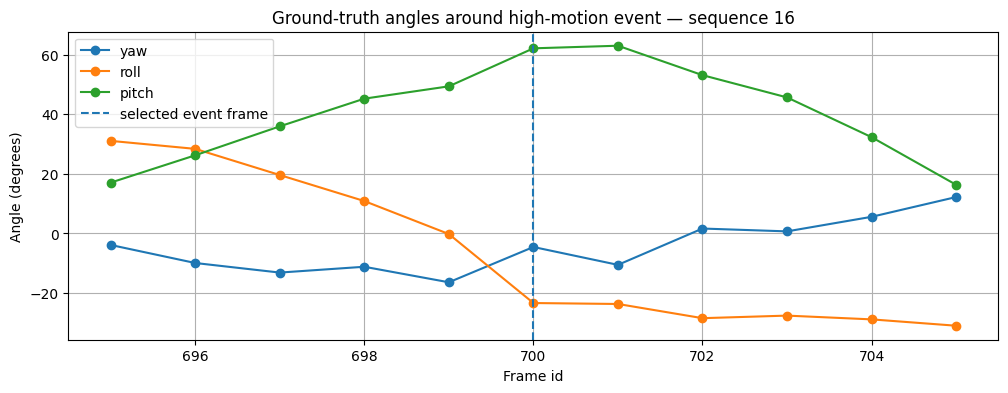

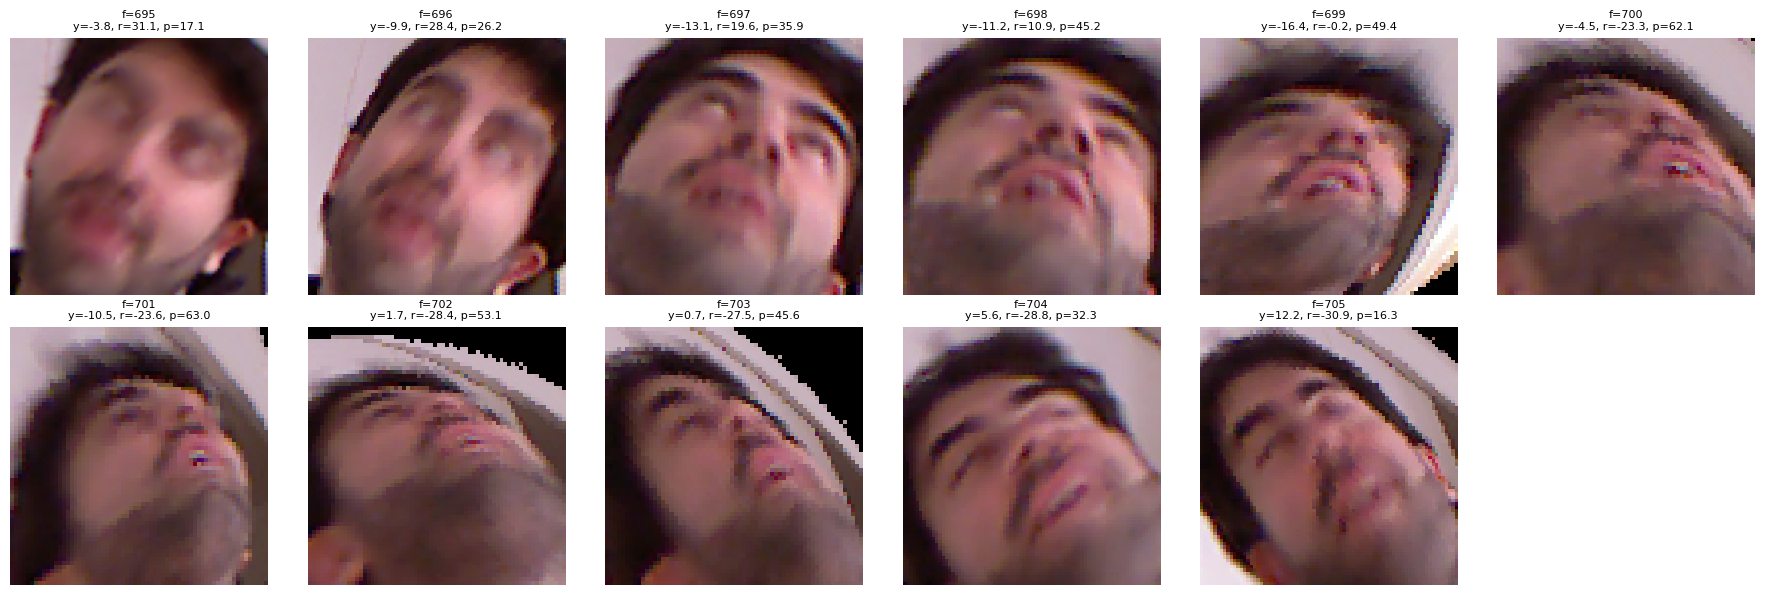

In [97]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Select the largest true consecutive-frame motion event
event = (
    df[df["is_consecutive_pair"]]
    .sort_values("consecutive_motion_magnitude", ascending=False)
    .iloc[0]
)

event_sequence = int(event["sequence_id"])
event_frame = int(event["frame_id"])
window = 5

event_window = (
    df[
        (df["sequence_id"] == event_sequence) &
        (df["frame_id"].between(event_frame - window, event_frame + window))
    ]
    .sort_values("frame_id")
    .reset_index(drop=True)
)

print("Selected high-motion event:")
display(event[[
    "sequence_id", "prev_frame_id", "frame_id", "frame_gap",
    "yaw", "roll", "pitch",
    "d_yaw", "d_roll", "d_pitch",
    "consecutive_motion_magnitude",
    "rho", "theta"
]])

print("\nTemporal window around the event:")
display(event_window[[
    "sequence_id", "frame_id",
    "yaw", "roll", "pitch",
    "consecutive_motion_magnitude",
    "rho", "theta"
]])

# Plot angle trajectories in the local window
plt.figure(figsize=(12, 4))
plt.plot(event_window["frame_id"], event_window["yaw"], marker="o", label="yaw")
plt.plot(event_window["frame_id"], event_window["roll"], marker="o", label="roll")
plt.plot(event_window["frame_id"], event_window["pitch"], marker="o", label="pitch")
plt.axvline(event_frame, linestyle="--", label="selected event frame")
plt.xlabel("Frame id")
plt.ylabel("Angle (degrees)")
plt.title(f"Ground-truth angles around high-motion event — sequence {event_sequence:02d}")
plt.legend()
plt.grid(True)
plt.show()

# Visualize frames around the event
num_frames_to_show = min(len(event_window), 12)
plt.figure(figsize=(18, 6))

for i, (_, row) in enumerate(event_window.iloc[:num_frames_to_show].iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")
    
    plt.subplot(2, 6, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"f={int(row['frame_id'])}\n"
        f"y={row['yaw']:.1f}, r={row['roll']:.1f}, p={row['pitch']:.1f}",
        fontsize=8
    )

plt.tight_layout()
plt.show()

### 4.4 Temporal behavior of fisheye distortion metadata

The visual inspection suggests that some apparent temporal changes may be influenced not only by head motion, but also by changes in the fisheye distortion parameters.

In BIWI-360, `rho` represents the normalized radial position used to generate the fisheye distortion, while `theta` represents the angular position in degrees. Since these values may vary from frame to frame, the visual input can change even when the underlying head pose changes smoothly.

We therefore inspect the temporal variation of `rho` and `theta`. This is important because prediction jitter may be caused by both head motion and frame-level distortion changes.

Temporal variation of fisheye distortion metadata in consecutive frame pairs:


,sequence_id,mean_abs_d_rho,max_abs_d_rho,mean_abs_d_theta,max_abs_d_theta,mean_consecutive_motion
1,2,0.293180,0.778485,92.099688,179.999919,1.465451
21,22,0.281305,0.773895,90.469284,179.771440,1.659451
22,23,0.277830,0.786281,89.114111,178.481651,2.717228
15,16,0.276735,0.780543,89.506495,179.801341,2.471317
23,24,0.276229,0.784355,90.746203,179.897569,2.362625
7,8,0.274179,0.784896,89.205556,179.978416,1.718165
20,21,0.274110,0.773897,86.763201,179.761454,3.297967
14,15,0.272847,0.784782,90.904430,179.945849,2.783583
11,12,0.270826,0.775445,91.189305,179.492981,1.085571
16,17,0.270562,0.759482,86.085297,179.631652,2.492552


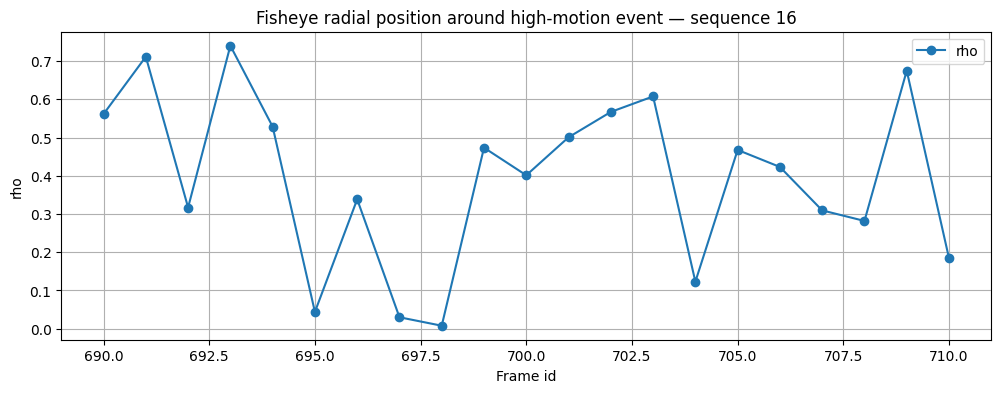

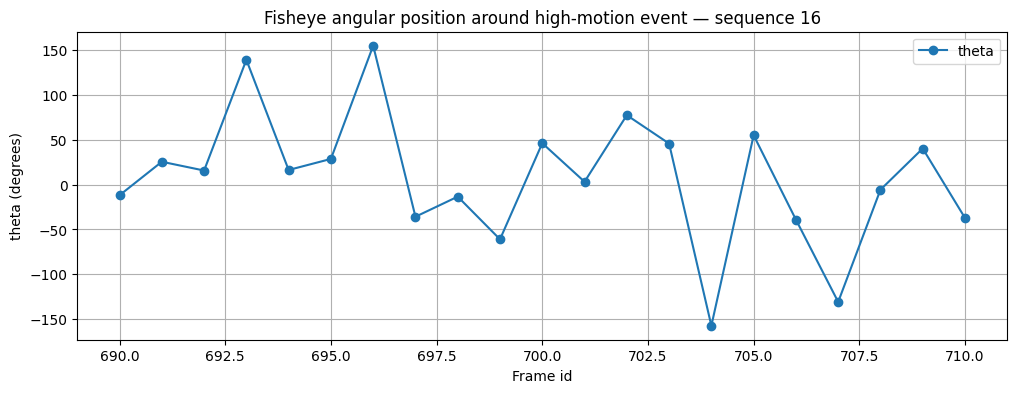

Fisheye metadata around the selected event:


,sequence_id,frame_id,yaw,roll,pitch,rho,theta,abs_d_rho,abs_d_theta_circular,consecutive_motion_magnitude
0,16,690,20.358862,-9.042987,-16.822059,0.561373,-11.948805,0.215088,30.080060,10.257547
1,16,691,16.694705,2.476415,-14.645219,0.711456,25.365397,0.150083,37.314202,12.282562
2,16,692,14.164224,12.970270,-9.381875,0.316937,15.582250,0.394519,9.783147,12.009459
3,16,693,10.273026,24.010633,-1.459435,0.740184,138.952373,0.423248,123.370123,14.134924
4,16,694,4.095913,29.027902,6.562670,0.528453,16.194854,0.211731,122.757519,11.299729
5,16,695,-3.849287,31.068011,17.068826,0.043766,28.512174,0.484687,12.317321,13.329200
6,16,696,-9.902146,28.386931,26.230939,0.338310,154.639296,0.294544,126.127122,11.303522
7,16,697,-13.112218,19.612712,35.943585,0.029792,-35.893442,0.308517,169.467262,13.476905
8,16,698,-11.159914,10.880800,45.226339,0.007660,-13.499510,0.022132,22.393931,12.892916
9,16,699,-16.368918,-0.184230,49.365342,0.473448,-61.062751,0.465788,47.563240,12.911234


In [98]:
# Compute temporal changes in fisheye metadata
df = df.sort_values(["sequence_id", "frame_id"]).copy()

df["d_rho"] = df.groupby("sequence_id")["rho"].diff()
df["abs_d_rho"] = df["d_rho"].abs()

# Circular difference for theta in degrees
def circular_angle_diff_deg(current, previous):
    diff = current - previous
    return (diff + 180) % 360 - 180

df["prev_theta"] = df.groupby("sequence_id")["theta"].shift(1)
df["d_theta_circular"] = circular_angle_diff_deg(df["theta"], df["prev_theta"])
df["abs_d_theta_circular"] = df["d_theta_circular"].abs()

fisheye_summary = (
    df[df["is_consecutive_pair"]]
    .groupby("sequence_id")
    .agg(
        mean_abs_d_rho=("abs_d_rho", "mean"),
        max_abs_d_rho=("abs_d_rho", "max"),
        mean_abs_d_theta=("abs_d_theta_circular", "mean"),
        max_abs_d_theta=("abs_d_theta_circular", "max"),
        mean_consecutive_motion=("consecutive_motion_magnitude", "mean"),
    )
    .reset_index()
    .sort_values("mean_abs_d_rho", ascending=False)
)

print("Temporal variation of fisheye distortion metadata in consecutive frame pairs:")
display(fisheye_summary)

# Plot fisheye metadata around the high-motion event already selected
event_sequence = int(event["sequence_id"])
event_frame = int(event["frame_id"])
window = 10

fisheye_window = (
    df[
        (df["sequence_id"] == event_sequence) &
        (df["frame_id"].between(event_frame - window, event_frame + window))
    ]
    .sort_values("frame_id")
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 4))
plt.plot(fisheye_window["frame_id"], fisheye_window["rho"], marker="o", label="rho")
plt.xlabel("Frame id")
plt.ylabel("rho")
plt.title(f"Fisheye radial position around high-motion event — sequence {event_sequence:02d}")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(fisheye_window["frame_id"], fisheye_window["theta"], marker="o", label="theta")
plt.xlabel("Frame id")
plt.ylabel("theta (degrees)")
plt.title(f"Fisheye angular position around high-motion event — sequence {event_sequence:02d}")
plt.legend()
plt.grid(True)
plt.show()

print("Fisheye metadata around the selected event:")
display(fisheye_window[[
    "sequence_id", "frame_id",
    "yaw", "roll", "pitch",
    "rho", "theta",
    "abs_d_rho", "abs_d_theta_circular",
    "consecutive_motion_magnitude"
]])

### 4.5 Defining temporal analysis regimes

The previous analysis shows that BIWI-360 preserves the sequential structure of BIWI, but the fisheye distortion metadata can vary strongly from one frame to the next. Therefore, temporal instability may come from two different sources:

1. actual head pose motion;
2. frame-level changes in fisheye distortion.

To make the later evaluation more interpretable, we define temporal regimes using only consecutive frame pairs. We classify each pair according to its ground-truth pose motion and its fisheye distortion change. This will allow us to compare model behavior in relatively stable conditions versus more challenging high-motion or high-distortion-change regions.


In [99]:
# Build a clean table of true consecutive frame pairs for temporal analysis
temporal_pairs = df[df["is_consecutive_pair"]].copy().reset_index(drop=True)

# Normalized fisheye change:
# - rho is in [0, 0.8], so we normalize by 0.8
# - theta circular difference is in [0, 180], so we normalize by 180
temporal_pairs["fisheye_change"] = np.sqrt(
    (temporal_pairs["abs_d_rho"] / 0.8) ** 2 +
    (temporal_pairs["abs_d_theta_circular"] / 180.0) ** 2
)

# Define thresholds using quantiles rather than fixed arbitrary values
motion_q75 = temporal_pairs["consecutive_motion_magnitude"].quantile(0.75)
motion_q90 = temporal_pairs["consecutive_motion_magnitude"].quantile(0.90)

fisheye_q75 = temporal_pairs["fisheye_change"].quantile(0.75)
fisheye_q90 = temporal_pairs["fisheye_change"].quantile(0.90)

def assign_level(value, q75, q90):
    if value >= q90:
        return "high"
    elif value >= q75:
        return "medium"
    else:
        return "low"

temporal_pairs["motion_level"] = temporal_pairs["consecutive_motion_magnitude"].apply(
    lambda x: assign_level(x, motion_q75, motion_q90)
)

temporal_pairs["fisheye_change_level"] = temporal_pairs["fisheye_change"].apply(
    lambda x: assign_level(x, fisheye_q75, fisheye_q90)
)

print("Number of consecutive frame pairs:", len(temporal_pairs))

print("\nMotion thresholds:")
print(f"75th percentile: {motion_q75:.3f}")
print(f"90th percentile: {motion_q90:.3f}")

print("\nFisheye-change thresholds:")
print(f"75th percentile: {fisheye_q75:.3f}")
print(f"90th percentile: {fisheye_q90:.3f}")

print("\nMotion level counts:")
display(temporal_pairs["motion_level"].value_counts().rename_axis("motion_level").reset_index(name="count"))

print("\nFisheye-change level counts:")
display(temporal_pairs["fisheye_change_level"].value_counts().rename_axis("fisheye_change_level").reset_index(name="count"))

print("\nJoint regime counts:")
display(
    temporal_pairs
    .groupby(["motion_level", "fisheye_change_level"])
    .size()
    .reset_index(name="count")
    .sort_values(["motion_level", "fisheye_change_level"])
)

print("\nExample high-motion and high-distortion-change pairs:")
display(
    temporal_pairs[
        (temporal_pairs["motion_level"] == "high") &
        (temporal_pairs["fisheye_change_level"] == "high")
    ][[
        "sequence_id", "prev_frame_id", "frame_id",
        "yaw", "roll", "pitch",
        "consecutive_motion_magnitude",
        "rho", "theta",
        "abs_d_rho", "abs_d_theta_circular",
        "fisheye_change",
        "motion_level", "fisheye_change_level"
    ]].head(10)
)

Number of consecutive frame pairs: 15628

Motion thresholds:
75th percentile: 2.535
90th percentile: 3.914

Fisheye-change thresholds:
75th percentile: 0.867
90th percentile: 0.996

Motion level counts:


,motion_level,count
0,low,11721
1,medium,2344
2,high,1563



Fisheye-change level counts:


,fisheye_change_level,count
0,low,11721
1,medium,2344
2,high,1563



Joint regime counts:


,motion_level,fisheye_change_level,count
0,high,high,140
1,high,low,1159
2,high,medium,264
3,low,high,1187
4,low,low,8785
5,low,medium,1749
6,medium,high,236
7,medium,low,1777
8,medium,medium,331



Example high-motion and high-distortion-change pairs:


,sequence_id,prev_frame_id,frame_id,yaw,roll,pitch,consecutive_motion_magnitude,rho,theta,abs_d_rho,abs_d_theta_circular,fisheye_change,motion_level,fisheye_change_level
19,1,22.0,23,17.959581,3.643839,15.247137,5.190434,0.103492,-152.658969,0.382351,158.168564,1.000282,high,high
304,1,307.0,308,-58.462280,15.803192,-21.067019,4.645668,0.258720,38.310167,0.540472,170.311493,1.162613,high,high
423,1,426.0,427,37.767735,-34.432472,-51.356571,4.733204,0.583560,10.015673,0.477031,161.111619,1.075500,high,high
833,2,338.0,339,-12.293116,21.179186,-53.616307,3.928912,0.158102,132.488993,0.528819,168.016834,1.143782,high,high
841,2,346.0,347,-5.046678,9.913918,-53.507912,4.050873,0.269263,-52.965853,0.308319,171.233517,1.026401,high,high
853,2,358.0,359,4.965018,-12.767263,-52.496013,5.210252,0.013459,-149.857898,0.718725,135.420136,1.171810,high,high
976,2,481.0,482,27.644811,-15.283466,-25.475475,4.471715,0.747373,166.805707,0.624250,134.182182,1.079163,high,high
1301,3,296.0,297,41.108193,25.703239,34.478895,4.106855,0.017811,-9.005829,0.398731,157.882408,1.008843,high,high
1411,3,406.0,407,-22.565788,-2.168420,12.432658,11.369611,0.072981,-158.419832,0.715091,128.635670,1.144424,high,high
1862,4,129.0,130,50.774036,33.549748,42.305406,5.000673,0.210213,25.409452,0.516394,160.001848,1.098546,high,high


## 5. Dataset analysis summary

The dataset inspection confirms that BIWI-360 contains 15,678 RGB frames organized into 24 video sequences, with one annotation row per available frame. All image paths referenced by the annotation table were found successfully.

The labels provide yaw, roll and pitch angles, together with two fisheye distortion metadata values: `rho`, the normalized radial position, and `theta`, the angular position in degrees. These metadata values are important because the fisheye transformation is not temporally smooth: both `rho` and `theta` can change strongly between consecutive frames.

For this reason, we will evaluate temporal behavior using only true consecutive frame pairs, where the frame gap is exactly one. We also define motion and fisheye-change regimes using quantile-based thresholds. This allows us to compare model behavior under low-motion, high-motion, low-distortion-change and high-distortion-change conditions.

This analysis reveals an important limitation of BIWI-360 for video-based evaluation: although the head pose sequence is temporal, the fisheye distortion may vary independently from frame to frame. Therefore, prediction instability can be caused by both actual head motion and artificial changes in image geometry.

In [100]:
import sys
import platform
import torch
from pathlib import Path

print("Python version:", sys.version)
print("Platform:", platform.platform())
print("PyTorch version:", torch.__version__)

if torch.cuda.is_available():
    print("CUDA is available.")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA is not available. Inference will run on CPU unless GPU is enabled.")

print("\nCurrent working directory:")
print(Path.cwd())

print("\nKaggle input root exists:", Path("/kaggle/input").exists())
print("Kaggle working directory exists:", Path("/kaggle/working").exists())

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch version: 2.10.0+cu128
CUDA is available.
GPU: Tesla T4

Current working directory:
/kaggle/working

Kaggle input root exists: True
Kaggle working directory exists: True


## 6. Model setup strategy

We will use a pretrained 6D head pose estimator as a frame-by-frame baseline. Before downloading or loading any external repository, we check whether internet access is available in the Kaggle environment and whether any pretrained model weights are already attached as Kaggle inputs.

This keeps the notebook reproducible and avoids hidden assumptions about the runtime environment.

In [101]:
import urllib.request

def check_url_available(url, timeout=10):
    try:
        with urllib.request.urlopen(url, timeout=timeout) as response:
            return True, response.status
    except Exception as e:
        return False, str(e)

github_ok, github_status = check_url_available("https://github.com", timeout=10)
weights_ok, weights_status = check_url_available(
    "https://cloud.ovgu.de/s/TewGC9TDLGgKkmS/download/6DRepNet360_Full-Rotation_300W_LP+Panoptic.pth",
    timeout=10
)

print("Internet check:")
print("GitHub reachable:", github_ok)
print("GitHub status / error:", github_status)

print("\nOfficial weights URL reachable:", weights_ok)
print("Weights status / error:", weights_status)

Internet check:
GitHub reachable: True
GitHub status / error: 200

Official weights URL reachable: True
Weights status / error: 200


### 6.1 Cloning the 6DRepNet360 repository

Since GitHub is reachable from the Kaggle environment, we clone the official 6DRepNet360 repository and inspect its contents. We first check the available files before deciding how to load the pretrained model.

This makes the model setup explicit and reproducible inside the notebook.

In [102]:
import subprocess
from pathlib import Path

EXTERNAL_DIR = Path("/kaggle/working/external")
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)

REPO_DIR = EXTERNAL_DIR / "6DRepNet360"
REPO_URL = "https://github.com/thohemp/6DRepNet360.git"

if REPO_DIR.exists():
    print("Repository already exists:", REPO_DIR)
else:
    print("Cloning repository...")
    result = subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)],
        capture_output=True,
        text=True
    )
    print("Return code:", result.returncode)
    if result.stdout:
        print("\nSTDOUT:")
        print(result.stdout)
    if result.stderr:
        print("\nSTDERR:")
        print(result.stderr)

print("\nRepository directory:")
print(REPO_DIR)

print("\nTop-level repository files:")
for path in sorted(REPO_DIR.iterdir()):
    print(" -", path.name)

print("\nCurrent repository commit:")
commit_result = subprocess.run(
    ["git", "-C", str(REPO_DIR), "rev-parse", "HEAD"],
    capture_output=True,
    text=True
)
print(commit_result.stdout.strip())

Repository already exists: /kaggle/working/external/6DRepNet360

Repository directory:
/kaggle/working/external/6DRepNet360

Top-level repository files:
 - .git
 - LICENSE.MD
 - README.MD
 - sixdrepnet360

Current repository commit:
b06e4fed77f802fbf05319b85bb65215087d5c7a


### 6.2 Inspecting the repository structure

After cloning the official 6DRepNet360 repository, we inspect its README and source files before importing the package. This allows us to understand the expected API, dependencies, and pretrained model loading mechanism without making assumptions.

In [103]:
from pathlib import Path

readme_path = REPO_DIR / "README.MD"

print("README exists:", readme_path.exists())

if readme_path.exists():
    readme_text = readme_path.read_text(errors="ignore")
    print("\nREADME preview:")
    print("=" * 100)
    print(readme_text[:6000])
    print("=" * 100)

print("\nRepository tree preview:")
for path in sorted(REPO_DIR.rglob("*")):
    relative = path.relative_to(REPO_DIR)
    depth = len(relative.parts)
    if depth <= 3:
        prefix = "  " * (depth - 1)
        print(f"{prefix}- {relative}")

README exists: True

README preview:
[![PWC](https://img.shields.io/endpoint.svg?url=https://paperswithcode.com/badge/towards-robust-and-unconstrained-full-range/head-pose-estimation-on-biwi)](https://paperswithcode.com/sota/head-pose-estimation-on-biwi?p=towards-robust-and-unconstrained-full-range)
[![PWC](https://img.shields.io/endpoint.svg?url=https://paperswithcode.com/badge/towards-robust-and-unconstrained-full-range/head-pose-estimation-on-cmu-panoptic-300w-lp)](https://paperswithcode.com/sota/head-pose-estimation-on-cmu-panoptic-300w-lp?p=towards-robust-and-unconstrained-full-range)
[![PWC](https://img.shields.io/endpoint.svg?url=https://paperswithcode.com/badge/towards-robust-and-unconstrained-full-range/head-pose-estimation-on-aflw2000)](https://paperswithcode.com/sota/head-pose-estimation-on-aflw2000?p=towards-robust-and-unconstrained-full-range)
# <div align="center"> **6DRepNet360** </div>

<p align="center">
  <img src="https://github.com/thohemp/archive/blob/main/6drepnet

### 6.3 Inspecting the 6DRepNet360 source code

The official README does not yet provide detailed usage instructions, so we inspect the available Python files before importing the model. This helps us understand whether the repository includes the model architecture, the inference pipeline, and the required preprocessing functions.

In [104]:
source_files = [
    REPO_DIR / "sixdrepnet360" / "test.py",
    REPO_DIR / "sixdrepnet360" / "utils.py",
    REPO_DIR / "sixdrepnet360" / "datasets.py",
]

for file_path in source_files:
    print("=" * 120)
    print(file_path)
    print("=" * 120)
    
    if file_path.exists():
        text = file_path.read_text(errors="ignore")
        print(text[:8000])
    else:
        print("File not found.")
    
    print("\n")

/kaggle/working/external/6DRepNet360/sixdrepnet360/test.py
import math
from matplotlib import pyplot as plt
import sys
import os
import argparse

import numpy as np
import cv2
from torchvision.utils import make_grid

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
import torch.backends.cudnn as cudnn
import torchvision
import torch.nn.functional as F
import datasets
import utils
from torch.hub import load_state_dict_from_url

#matplotlib.use("gtk")


class SixDRepNet360(nn.Module):
    def __init__(self, block, layers, fc_layers=1):
        self.inplanes = 64
        super(SixDRepNet360, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3,
                               bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[

### 6.4 Importing the model definition

The repository defines the `SixDRepNet360` architecture inside `test.py`. The model predicts a 6D rotation representation and then converts it into a valid 3D rotation matrix using the utility function `compute_rotation_matrix_from_ortho6d`.

We now import the model definition and instantiate the network on the available device. At this stage, we only check that the architecture can be created successfully; pretrained weights will be loaded in the next step.

In [105]:
import sys
import importlib
from pathlib import Path

import torch
import torchvision

SIXD_SRC_DIR = REPO_DIR / "sixdrepnet360"

# Add the source directory to Python path so that test.py can import utils.py and datasets.py
if str(SIXD_SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SIXD_SRC_DIR))

# Import repository modules
sixd_test = importlib.import_module("test")
sixd_utils = importlib.import_module("utils")

# Create model architecture
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = sixd_test.SixDRepNet360(
    torchvision.models.resnet.Bottleneck,
    [3, 4, 6, 3],
    6
).to(device)

model.eval()

num_params = sum(p.numel() for p in model.parameters())
num_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Device:", device)
print("Model created successfully.")
print(f"Total parameters: {num_params:,}")
print(f"Trainable parameters: {num_trainable_params:,}")

Device: cuda
Model created successfully.
Total parameters: 23,520,326
Trainable parameters: 23,520,326


### 6.5 Loading pretrained 6DRepNet360 weights

We use the official pretrained 6DRepNet360 Full Rotation weights. This model was fine-tuned on 300W-LP and CMU Panoptic, which makes it more suitable for wide-range head pose estimation than a model trained only on 300W-LP.

The model will be used as a frame-by-frame baseline. We do not fine-tune it on BIWI-360; instead, we evaluate how well a pretrained 6D rotation-based estimator transfers to fisheye-distorted video frames.

In [106]:
from torch.hub import load_state_dict_from_url

WEIGHTS_URL = "https://cloud.ovgu.de/s/TewGC9TDLGgKkmS/download/6DRepNet360_Full-Rotation_300W_LP+Panoptic.pth"

print("Downloading/loading pretrained weights...")
saved_state_dict = load_state_dict_from_url(
    WEIGHTS_URL,
    model_dir="/kaggle/working/model_weights",
    map_location=device,
    progress=True
)

if "model_state_dict" in saved_state_dict:
    state_dict = saved_state_dict["model_state_dict"]
else:
    state_dict = saved_state_dict

missing_keys, unexpected_keys = model.load_state_dict(state_dict, strict=False)

model.to(device)
model.eval()

print("Pretrained weights loaded.")
print("Missing keys:", missing_keys)
print("Unexpected keys:", unexpected_keys)

Downloading/loading pretrained weights...
Pretrained weights loaded.
Missing keys: []
Unexpected keys: []


### 6.6 Single-frame inference test

Before running inference on the full BIWI-360 dataset, we test the complete prediction pipeline on a single frame. This allows us to verify the preprocessing, model output format, Euler angle conversion, and comparison with the ground-truth annotation.

The model outputs a rotation matrix. We convert it to Euler angles using the repository utility function and then report yaw, roll and pitch in degrees.

Single-frame inference test
Image: /kaggle/input/datasets/nn1966/hpe-360/HPE-360/HPE-360/BIWI-360/01/frame_00003_rgb.png

Ground truth:
yaw   = 3.29
roll  = -1.57
pitch = 7.61

Prediction:
yaw   = -3.89
roll  = -3.66
pitch = -9.67

Absolute angular error:
yaw   = 7.18
roll  = 2.10
pitch = 17.27


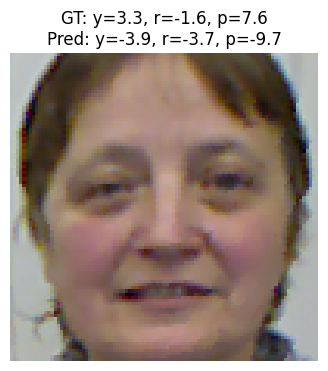

In [107]:
from torchvision import transforms
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt

# Same preprocessing used in the official test script
inference_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def angular_error_deg(pred, gt):
    """Smallest absolute angular difference in degrees."""
    return min(abs(pred - gt), abs(pred + 360 - gt), abs(pred - 360 - gt))

def predict_single_image(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = inference_transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        rotation_matrix = model(input_tensor)
        euler = sixd_utils.compute_euler_angles_from_rotation_matrices(rotation_matrix)
        euler_deg = euler[0].detach().cpu().numpy() * 180.0 / np.pi
    
    # Repository convention:
    # euler[:, 0] = pitch, euler[:, 1] = yaw, euler[:, 2] = roll
    pred_pitch = float(euler_deg[0])
    pred_yaw = float(euler_deg[1])
    pred_roll = float(euler_deg[2])
    
    return {
        "pred_yaw": pred_yaw,
        "pred_roll": pred_roll,
        "pred_pitch": pred_pitch,
    }

# Select one example frame
sample_row = df.iloc[0]
prediction = predict_single_image(sample_row["image_path"])

print("Single-frame inference test")
print("Image:", sample_row["image_path"])
print()

print("Ground truth:")
print(f"yaw   = {sample_row['yaw']:.2f}")
print(f"roll  = {sample_row['roll']:.2f}")
print(f"pitch = {sample_row['pitch']:.2f}")
print()

print("Prediction:")
print(f"yaw   = {prediction['pred_yaw']:.2f}")
print(f"roll  = {prediction['pred_roll']:.2f}")
print(f"pitch = {prediction['pred_pitch']:.2f}")
print()

print("Absolute angular error:")
print(f"yaw   = {angular_error_deg(prediction['pred_yaw'], sample_row['yaw']):.2f}")
print(f"roll  = {angular_error_deg(prediction['pred_roll'], sample_row['roll']):.2f}")
print(f"pitch = {angular_error_deg(prediction['pred_pitch'], sample_row['pitch']):.2f}")

# Visualize the tested frame
img = Image.open(sample_row["image_path"]).convert("RGB")
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"GT: y={sample_row['yaw']:.1f}, r={sample_row['roll']:.1f}, p={sample_row['pitch']:.1f}\n"
    f"Pred: y={prediction['pred_yaw']:.1f}, r={prediction['pred_roll']:.1f}, p={prediction['pred_pitch']:.1f}"
)
plt.show()

### 6.7 Checking angle convention alignment

The single-frame test suggests that some predicted angles may follow a different sign convention from the BIWI-360 labels. Before running full-dataset inference, we test several simple sign-convention variants on a small subset of frames.

This step is necessary because head pose datasets and models may use different coordinate conventions. We do not want to apply any correction manually unless it consistently reduces the error across multiple frames.

In [108]:
from tqdm.auto import tqdm
import itertools
import pandas as pd
import numpy as np

# Sample frames across the whole dataset to check convention alignment quickly
sample_eval_parts = []

for _, group in df.groupby("sequence_id"):
    sample_eval_parts.append(group.sample(min(len(group), 10), random_state=42))

sample_eval_df = pd.concat(sample_eval_parts).reset_index(drop=True)

print("Number of sampled frames:", len(sample_eval_df))

pred_rows = []

for _, row in tqdm(sample_eval_df.iterrows(), total=len(sample_eval_df)):
    pred = predict_single_image(row["image_path"])
    
    pred_rows.append({
        "sequence_id": row["sequence_id"],
        "frame_id": row["frame_id"],
        "gt_yaw": row["yaw"],
        "gt_roll": row["roll"],
        "gt_pitch": row["pitch"],
        "pred_yaw_raw": pred["pred_yaw"],
        "pred_roll_raw": pred["pred_roll"],
        "pred_pitch_raw": pred["pred_pitch"],
    })

convention_df = pd.DataFrame(pred_rows)

def mean_mae_for_signs(data, sy=1, sr=1, sp=1):
    yaw_errors = [
        angular_error_deg(sy * p, g)
        for p, g in zip(data["pred_yaw_raw"], data["gt_yaw"])
    ]
    roll_errors = [
        angular_error_deg(sr * p, g)
        for p, g in zip(data["pred_roll_raw"], data["gt_roll"])
    ]
    pitch_errors = [
        angular_error_deg(sp * p, g)
        for p, g in zip(data["pred_pitch_raw"], data["gt_pitch"])
    ]
    
    return {
        "sign_yaw": sy,
        "sign_roll": sr,
        "sign_pitch": sp,
        "mae_yaw": np.mean(yaw_errors),
        "mae_roll": np.mean(roll_errors),
        "mae_pitch": np.mean(pitch_errors),
        "mean_mae": np.mean([np.mean(yaw_errors), np.mean(roll_errors), np.mean(pitch_errors)])
    }

results = []

for sy, sr, sp in itertools.product([1, -1], repeat=3):
    results.append(mean_mae_for_signs(convention_df, sy=sy, sr=sr, sp=sp))

sign_results = pd.DataFrame(results).sort_values("mean_mae").reset_index(drop=True)

print("Sign convention comparison on sampled frames:")
display(sign_results)

print("\nSample predictions with raw model outputs:")
display(convention_df.head(10))

Number of sampled frames: 240


  0%|          | 0/240 [00:00<?, ?it/s]

Sign convention comparison on sampled frames:


,sign_yaw,sign_roll,sign_pitch,mae_yaw,mae_roll,mae_pitch,mean_mae
0,1,1,1,17.913169,22.210959,31.029293,23.717807
1,1,1,-1,17.913169,22.210959,41.967230,27.363786
2,1,-1,1,17.913169,33.793643,31.029293,27.578702
3,1,-1,-1,17.913169,33.793643,41.967230,31.224681
4,-1,1,1,48.381750,22.210959,31.029293,33.874001
5,-1,1,-1,48.381750,22.210959,41.967230,37.519979
6,-1,-1,1,48.381750,33.793643,31.029293,37.734895
7,-1,-1,-1,48.381750,33.793643,41.967230,41.380874



Sample predictions with raw model outputs:


,sequence_id,frame_id,gt_yaw,gt_roll,gt_pitch,pred_yaw_raw,pred_roll_raw,pred_pitch_raw
0,1,463,-31.972218,17.847537,-51.348841,-20.983072,8.452777,-34.629814
1,1,76,19.351829,8.534912,32.376030,-0.398311,-2.028677,-2.104806
2,1,234,47.351681,-4.116045,-1.959559,35.841503,2.887403,1.870802
3,1,178,10.137439,1.819631,10.255109,15.431098,4.674442,17.101084
4,1,240,39.711930,-3.933954,-2.544290,23.998280,4.107418,-13.424181
5,1,428,35.033410,-31.509099,-52.262954,-56.730854,-142.266083,177.015411
6,1,158,-12.308774,-2.795928,10.382256,-2.817593,-3.559524,1.084332
7,1,58,30.959831,16.883230,38.071361,33.708569,21.780138,30.355106
8,1,325,-58.149510,30.130960,-36.217105,-65.393150,-15.313673,31.947279
9,1,12,3.791450,-1.956757,7.585290,-8.933473,0.198416,-2.185977


### 6.8 Full BIWI-360 frame-by-frame inference

The sign-convention check shows that the raw model output provides the best alignment with the BIWI-360 labels among the tested variants. Therefore, we do not apply any manual sign correction.

We now run frame-by-frame inference on all BIWI-360 images. The resulting predictions will be stored together with the ground-truth annotations so that we can compute frame-level accuracy metrics and temporal stability metrics in the next sections.

In [109]:
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import time
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image

class BIWI360FrameDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)
        return image, index

# Keep a clean sorted inference table
inference_df = df.sort_values(["sequence_id", "frame_id"]).reset_index(drop=True).copy()

prediction_csv = Path("/kaggle/working/biwi360_6drepnet360_fullrotation_predictions.csv")

if prediction_csv.exists():
    print("Loading existing predictions from:", prediction_csv)
    pred_df = pd.read_csv(prediction_csv)
else:
    batch_size = 128

    inference_dataset = BIWI360FrameDataset(inference_df, inference_transform)
    inference_loader = DataLoader(
        inference_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    pred_yaw = np.zeros(len(inference_df), dtype=np.float32)
    pred_roll = np.zeros(len(inference_df), dtype=np.float32)
    pred_pitch = np.zeros(len(inference_df), dtype=np.float32)

    model.eval()
    start_time = time.time()

    with torch.no_grad():
        for images, indices in tqdm(inference_loader, desc="Running inference"):
            images = images.to(device, non_blocking=True)

            rotation_matrices = model(images)
            euler = sixd_utils.compute_euler_angles_from_rotation_matrices(rotation_matrices)
            euler_deg = euler.detach().cpu().numpy() * 180.0 / np.pi

            # Repository convention:
            # euler[:, 0] = pitch, euler[:, 1] = yaw, euler[:, 2] = roll
            indices_np = indices.numpy()
            pred_pitch[indices_np] = euler_deg[:, 0]
            pred_yaw[indices_np] = euler_deg[:, 1]
            pred_roll[indices_np] = euler_deg[:, 2]

    elapsed = time.time() - start_time

    pred_df = inference_df.copy()
    pred_df["pred_yaw"] = pred_yaw
    pred_df["pred_roll"] = pred_roll
    pred_df["pred_pitch"] = pred_pitch

    pred_df.to_csv(prediction_csv, index=False)

    print(f"Inference completed in {elapsed:.2f} seconds.")
    print(f"Average speed: {len(pred_df) / elapsed:.2f} frames/second.")
    print("Predictions saved to:", prediction_csv)

print("Prediction table shape:", pred_df.shape)

print("\nPrediction table preview:")
display(pred_df[[
    "sequence_id", "frame_id",
    "yaw", "roll", "pitch",
    "pred_yaw", "pred_roll", "pred_pitch",
    "rho", "theta"
]].head())

print("\nPrediction value summary:")
display(pred_df[["pred_yaw", "pred_roll", "pred_pitch"]].describe())

Loading existing predictions from: /kaggle/working/biwi360_6drepnet360_fullrotation_predictions.csv
Prediction table shape: (15678, 29)

Prediction table preview:


,sequence_id,frame_id,yaw,roll,pitch,pred_yaw,pred_roll,pred_pitch,rho,theta
0,1,3,3.290994,-1.566632,7.607223,-3.889712,-3.664211,-9.666253,0.250498,-74.249642
1,1,4,3.889411,-1.930131,7.650885,9.635563,-4.170786,2.779594,0.465149,139.762830
2,1,5,3.664672,-1.946089,7.445381,-16.904100,1.359497,3.938677,0.670615,11.398345
3,1,6,3.795917,-1.896884,7.455991,-14.823156,-4.605124,-15.515920,0.756483,-98.073602
4,1,7,3.433040,-2.123386,7.729789,0.830185,-6.454150,-8.736897,0.255294,101.986555



Prediction value summary:


,pred_yaw,pred_roll,pred_pitch
count,15678.000000,15678.000000,15678.000000
mean,-3.007759,4.919720,-5.559988
std,37.795027,47.464971,50.883317
min,-89.276630,-179.985120,-179.985500
25%,-28.806689,-6.633220,-17.649768
50%,-2.712913,0.007919,-5.165215
75%,20.828714,10.061334,6.281883
max,89.314650,179.871300,179.939060


### 6.9 Full-inference angle convention diagnostic

The full prediction summary shows very wide predicted roll and pitch values, which may indicate poor transfer to fisheye-distorted images. However, before interpreting the result as model failure, we check whether the predicted Euler angles are aligned with the BIWI-360 label convention.

We already tested sign flips on a small subset, but here we test all permutations of predicted angle assignments and sign combinations using the full prediction table. This helps us verify whether the apparent error is caused by a convention mismatch or by genuine prediction errors under fisheye distortion.

In [110]:
import itertools
import numpy as np
import pandas as pd
from pathlib import Path

# Load predictions if needed
prediction_csv = Path("/kaggle/working/biwi360_6drepnet360_fullrotation_predictions.csv")
pred_df = pd.read_csv(prediction_csv)

gt_cols = ["yaw", "roll", "pitch"]
pred_cols = ["pred_yaw", "pred_roll", "pred_pitch"]

def angular_diff_array_deg(pred, gt):
    """Smallest absolute angular difference in degrees, vectorized."""
    diff1 = np.abs(pred - gt)
    diff2 = np.abs(pred + 360 - gt)
    diff3 = np.abs(pred - 360 - gt)
    return np.minimum(np.minimum(diff1, diff2), diff3)

diagnostic_rows = []

for perm in itertools.permutations(pred_cols):
    for signs in itertools.product([1, -1], repeat=3):
        errors = {}
        
        for gt_col, pred_col, sign in zip(gt_cols, perm, signs):
            errors[gt_col] = angular_diff_array_deg(
                sign * pred_df[pred_col].values,
                pred_df[gt_col].values
            )
        
        mae_yaw = errors["yaw"].mean()
        mae_roll = errors["roll"].mean()
        mae_pitch = errors["pitch"].mean()
        mean_mae = np.mean([mae_yaw, mae_roll, mae_pitch])
        
        diagnostic_rows.append({
            "pred_for_yaw": perm[0],
            "pred_for_roll": perm[1],
            "pred_for_pitch": perm[2],
            "sign_yaw": signs[0],
            "sign_roll": signs[1],
            "sign_pitch": signs[2],
            "mae_yaw": mae_yaw,
            "mae_roll": mae_roll,
            "mae_pitch": mae_pitch,
            "mean_mae": mean_mae,
        })

angle_diagnostic = (
    pd.DataFrame(diagnostic_rows)
    .sort_values("mean_mae")
    .reset_index(drop=True)
)

print("Best angle assignment and sign combinations:")
display(angle_diagnostic.head(15))

print("\nCurrent raw convention result:")
raw_result = angle_diagnostic[
    (angle_diagnostic["pred_for_yaw"] == "pred_yaw") &
    (angle_diagnostic["pred_for_roll"] == "pred_roll") &
    (angle_diagnostic["pred_for_pitch"] == "pred_pitch") &
    (angle_diagnostic["sign_yaw"] == 1) &
    (angle_diagnostic["sign_roll"] == 1) &
    (angle_diagnostic["sign_pitch"] == 1)
]
display(raw_result)

Best angle assignment and sign combinations:


,pred_for_yaw,pred_for_roll,pred_for_pitch,sign_yaw,sign_roll,sign_pitch,mae_yaw,mae_roll,mae_pitch,mean_mae
0,pred_yaw,pred_roll,pred_pitch,1,1,1,16.875613,21.278923,30.079197,22.744578
1,pred_yaw,pred_pitch,pred_roll,1,1,1,16.875613,28.999096,30.583661,25.486123
2,pred_yaw,pred_roll,pred_pitch,1,1,-1,16.875613,21.278923,40.668673,26.274403
3,pred_yaw,pred_pitch,pred_roll,1,-1,1,16.875613,31.585857,30.583661,26.348377
4,pred_yaw,pred_roll,pred_pitch,1,-1,1,16.875613,32.099427,30.079197,26.351412
5,pred_yaw,pred_pitch,pred_roll,1,1,-1,16.875613,28.999096,37.043903,27.639537
6,pred_yaw,pred_pitch,pred_roll,1,-1,-1,16.875613,31.585857,37.043903,28.501791
7,pred_yaw,pred_roll,pred_pitch,1,-1,-1,16.875613,32.099427,40.668673,29.881237
8,pred_pitch,pred_roll,pred_yaw,-1,1,-1,36.692905,21.278923,33.205354,30.392394
9,pred_pitch,pred_roll,pred_yaw,1,1,-1,39.801944,21.278923,33.205354,31.428740



Current raw convention result:


,pred_for_yaw,pred_for_roll,pred_for_pitch,sign_yaw,sign_roll,sign_pitch,mae_yaw,mae_roll,mae_pitch,mean_mae
0,pred_yaw,pred_roll,pred_pitch,1,1,1,16.875613,21.278923,30.079197,22.744578


## 7. Experimental protocol

We do not fine-tune 6DRepNet360 on BIWI-360. Instead, we evaluate the pretrained model as a zero-shot frame-by-frame baseline under fisheye distortion. This is consistent with our research question, which focuses on transfer robustness and temporal stability rather than supervised adaptation.

The previous angle-convention diagnostic showed that the raw model output is the best alignment with the BIWI-360 labels among all tested permutations and sign combinations. Therefore, the high frame-level error should be interpreted as a transfer limitation under fisheye distortion, rather than as a simple coordinate-convention mismatch.

The temporal post-processing stage introduces a hyperparameter: the smoothing strength. To avoid choosing this parameter directly on the final evaluation data, we split BIWI-360 by video sequence into a validation subset and a test subset.

The validation subset will be used only to select the temporal smoothing parameter. The test subset will be used for the final comparison between raw frame-by-frame predictions and smoothed predictions.

We split by sequence rather than by individual frames to avoid temporal leakage between validation and test data.


In [111]:
# Sequence-level validation/test split.
# We do not train the model, so there is no training split.
# The validation split is only used later to choose the smoothing hyperparameter.

all_sequences = sorted([int(seq) for seq in pred_df["sequence_id"].unique()])

# Evenly spaced validation sequences across the 24 BIWI-360 sequences
validation_sequences = [4, 10, 16, 22]
test_sequences = [seq for seq in all_sequences if seq not in validation_sequences]

pred_df["split"] = np.where(
    pred_df["sequence_id"].isin(validation_sequences),
    "validation",
    "test"
)

# Keep the split also in temporal_pairs for later temporal metrics
temporal_pairs["split"] = np.where(
    temporal_pairs["sequence_id"].isin(validation_sequences),
    "validation",
    "test"
)

print("All sequences:", all_sequences)
print("Validation sequences:", validation_sequences)
print("Test sequences:", test_sequences)

print("\nFrame counts by split:")
display(pred_df.groupby("split").size().rename("num_frames").reset_index())

print("\nConsecutive temporal-pair counts by split:")
display(temporal_pairs.groupby("split").size().rename("num_pairs").reset_index())

print("\nSequence distribution by split:")
display(
    pred_df.groupby(["split", "sequence_id"])
    .size()
    .rename("num_frames")
    .reset_index()
)

All sequences: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Validation sequences: [4, 10, 16, 22]
Test sequences: [1, 2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 23, 24]

Frame counts by split:


,split,num_frames
0,test,12629
1,validation,3049



Consecutive temporal-pair counts by split:


,split,num_pairs
0,test,12585
1,validation,3043



Sequence distribution by split:


,split,sequence_id,num_frames
0,test,1,499
1,test,2,511
2,test,3,730
3,test,5,946
4,test,6,542
5,test,7,745
6,test,8,772
7,test,9,882
8,test,11,572
9,test,12,732


## 8. Frame-level accuracy metrics

We first evaluate the frame-level accuracy of the pretrained 6DRepNet360 model. At this stage, each frame is treated independently, because the model itself is frame-by-frame and does not use temporal context.

We report Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) for yaw, roll and pitch. We compute the angular error using the smallest equivalent angular difference, which accounts for the periodicity of angles.

In [112]:
import numpy as np
import pandas as pd

def angular_diff_array_deg(pred, gt):
    """Smallest absolute angular difference in degrees, vectorized."""
    pred = np.asarray(pred)
    gt = np.asarray(gt)
    
    diff1 = np.abs(pred - gt)
    diff2 = np.abs(pred + 360 - gt)
    diff3 = np.abs(pred - 360 - gt)
    
    return np.minimum(np.minimum(diff1, diff2), diff3)

# Compute frame-level absolute angular errors
pred_df["err_yaw"] = angular_diff_array_deg(pred_df["pred_yaw"], pred_df["yaw"])
pred_df["err_roll"] = angular_diff_array_deg(pred_df["pred_roll"], pred_df["roll"])
pred_df["err_pitch"] = angular_diff_array_deg(pred_df["pred_pitch"], pred_df["pitch"])
pred_df["err_mean"] = pred_df[["err_yaw", "err_roll", "err_pitch"]].mean(axis=1)

def summarize_frame_metrics(dataframe, split_name):
    subset = dataframe[dataframe["split"] == split_name]
    
    metrics = {
        "split": split_name,
        "num_frames": len(subset),
        "mae_yaw": subset["err_yaw"].mean(),
        "mae_roll": subset["err_roll"].mean(),
        "mae_pitch": subset["err_pitch"].mean(),
        "mean_mae": subset[["err_yaw", "err_roll", "err_pitch"]].mean().mean(),
        "rmse_yaw": np.sqrt(np.mean(subset["err_yaw"] ** 2)),
        "rmse_roll": np.sqrt(np.mean(subset["err_roll"] ** 2)),
        "rmse_pitch": np.sqrt(np.mean(subset["err_pitch"] ** 2)),
        "mean_rmse": np.mean([
            np.sqrt(np.mean(subset["err_yaw"] ** 2)),
            np.sqrt(np.mean(subset["err_roll"] ** 2)),
            np.sqrt(np.mean(subset["err_pitch"] ** 2)),
        ]),
    }
    
    return metrics

frame_metrics = pd.DataFrame([
    summarize_frame_metrics(pred_df, "validation"),
    summarize_frame_metrics(pred_df, "test"),
])

print("Frame-level accuracy metrics:")
display(frame_metrics)

print("\nFrame-level error distribution on the test split:")
display(
    pred_df[pred_df["split"] == "test"][["err_yaw", "err_roll", "err_pitch", "err_mean"]]
    .describe()
)

# Save updated prediction table with error columns and split
updated_prediction_csv = "/kaggle/working/biwi360_6drepnet360_predictions_with_errors.csv"
pred_df.to_csv(updated_prediction_csv, index=False)

print("\nUpdated prediction table saved to:")
print(updated_prediction_csv)

Frame-level accuracy metrics:


,split,num_frames,mae_yaw,mae_roll,mae_pitch,mean_mae,rmse_yaw,rmse_roll,rmse_pitch,mean_rmse
0,validation,3049,16.389506,21.885331,31.801848,23.358895,24.807456,44.752287,51.961620,40.507121
1,test,12629,16.992973,21.132519,29.663300,22.596264,25.984591,44.367790,48.104056,39.485479



Frame-level error distribution on the test split:


,err_yaw,err_roll,err_pitch,err_mean
count,12629.000000,12629.000000,12629.000000,12629.000000
mean,16.992973,21.132519,29.663300,22.596264
std,19.658801,39.013305,37.870864,28.792786
min,0.004771,0.001313,0.000009,0.338190
25%,4.688813,2.343530,7.874538,6.880685
50%,10.424165,5.541516,16.928966,11.774267
75%,20.669256,15.581273,30.760041,21.847122
max,147.080120,179.985586,179.984514,150.254814



Updated prediction table saved to:
/kaggle/working/biwi360_6drepnet360_predictions_with_errors.csv


## 9. Temporal stability metrics for raw predictions

The previous section evaluated each frame independently. We now evaluate temporal stability by comparing consecutive frame pairs.

For each true consecutive pair, we compute:

- the ground-truth angular change between two consecutive frames;
- the predicted angular change between the same two frames;
- the prediction jitter, defined as the magnitude of the predicted frame-to-frame change;
- the temporal motion error, defined as the mismatch between predicted motion and ground-truth motion.

This analysis is important because a frame-by-frame model can have unstable predictions even when the underlying head motion is relatively smooth.

In [113]:
import numpy as np
import pandas as pd

def signed_circular_diff_deg(current, previous):
    """
    Signed circular difference current - previous in degrees.
    Output is in [-180, 180).
    """
    diff = np.asarray(current) - np.asarray(previous)
    return (diff + 180) % 360 - 180

# Sort predictions temporally
pred_df = pred_df.sort_values(["sequence_id", "frame_id"]).reset_index(drop=True).copy()

# Previous frame information
pred_df["prev_frame_id_eval"] = pred_df.groupby("sequence_id")["frame_id"].shift(1)
pred_df["frame_gap_eval"] = pred_df["frame_id"] - pred_df["prev_frame_id_eval"]
pred_df["is_consecutive_pair_eval"] = pred_df["frame_gap_eval"] == 1

# Previous GT and prediction values
for col in ["yaw", "roll", "pitch", "pred_yaw", "pred_roll", "pred_pitch", "rho", "theta"]:
    pred_df[f"prev_{col}"] = pred_df.groupby("sequence_id")[col].shift(1)

# Keep only true consecutive frame pairs
raw_temporal_df = pred_df[pred_df["is_consecutive_pair_eval"]].copy().reset_index(drop=True)

# Ground-truth and predicted signed angular changes
for angle in ["yaw", "roll", "pitch"]:
    raw_temporal_df[f"gt_delta_{angle}"] = signed_circular_diff_deg(
        raw_temporal_df[angle],
        raw_temporal_df[f"prev_{angle}"]
    )
    
    raw_temporal_df[f"pred_delta_{angle}"] = signed_circular_diff_deg(
        raw_temporal_df[f"pred_{angle}"],
        raw_temporal_df[f"prev_pred_{angle}"]
    )
    
    raw_temporal_df[f"pred_jitter_{angle}"] = np.abs(raw_temporal_df[f"pred_delta_{angle}"])
    raw_temporal_df[f"temporal_error_{angle}"] = np.abs(
        raw_temporal_df[f"pred_delta_{angle}"] - raw_temporal_df[f"gt_delta_{angle}"]
    )

# Magnitudes over yaw, roll, pitch
raw_temporal_df["gt_motion_magnitude_eval"] = np.sqrt(
    raw_temporal_df["gt_delta_yaw"] ** 2 +
    raw_temporal_df["gt_delta_roll"] ** 2 +
    raw_temporal_df["gt_delta_pitch"] ** 2
)

raw_temporal_df["pred_jitter_magnitude"] = np.sqrt(
    raw_temporal_df["pred_delta_yaw"] ** 2 +
    raw_temporal_df["pred_delta_roll"] ** 2 +
    raw_temporal_df["pred_delta_pitch"] ** 2
)

raw_temporal_df["temporal_motion_error_magnitude"] = np.sqrt(
    raw_temporal_df["temporal_error_yaw"] ** 2 +
    raw_temporal_df["temporal_error_roll"] ** 2 +
    raw_temporal_df["temporal_error_pitch"] ** 2
)

# Fisheye metadata change for analysis
raw_temporal_df["delta_rho"] = raw_temporal_df["rho"] - raw_temporal_df["prev_rho"]
raw_temporal_df["abs_delta_rho"] = raw_temporal_df["delta_rho"].abs()

raw_temporal_df["delta_theta_circular"] = signed_circular_diff_deg(
    raw_temporal_df["theta"],
    raw_temporal_df["prev_theta"]
)
raw_temporal_df["abs_delta_theta_circular"] = raw_temporal_df["delta_theta_circular"].abs()

raw_temporal_df["fisheye_change"] = np.sqrt(
    (raw_temporal_df["abs_delta_rho"] / 0.8) ** 2 +
    (raw_temporal_df["abs_delta_theta_circular"] / 180.0) ** 2
)

# Assign motion and fisheye-change levels using the same quantile idea
motion_q75 = raw_temporal_df["gt_motion_magnitude_eval"].quantile(0.75)
motion_q90 = raw_temporal_df["gt_motion_magnitude_eval"].quantile(0.90)

fisheye_q75 = raw_temporal_df["fisheye_change"].quantile(0.75)
fisheye_q90 = raw_temporal_df["fisheye_change"].quantile(0.90)

def assign_level(value, q75, q90):
    if value >= q90:
        return "high"
    elif value >= q75:
        return "medium"
    else:
        return "low"

raw_temporal_df["motion_level"] = raw_temporal_df["gt_motion_magnitude_eval"].apply(
    lambda x: assign_level(x, motion_q75, motion_q90)
)

raw_temporal_df["fisheye_change_level"] = raw_temporal_df["fisheye_change"].apply(
    lambda x: assign_level(x, fisheye_q75, fisheye_q90)
)

print("Number of true consecutive temporal pairs:", len(raw_temporal_df))

print("\nTemporal thresholds:")
print(f"Motion q75: {motion_q75:.3f}")
print(f"Motion q90: {motion_q90:.3f}")
print(f"Fisheye-change q75: {fisheye_q75:.3f}")
print(f"Fisheye-change q90: {fisheye_q90:.3f}")

def summarize_temporal_metrics(dataframe, split_name):
    subset = dataframe[dataframe["split"] == split_name]
    
    return {
        "split": split_name,
        "num_pairs": len(subset),
        "mean_gt_motion": subset["gt_motion_magnitude_eval"].mean(),
        "mean_pred_jitter": subset["pred_jitter_magnitude"].mean(),
        "mean_temporal_motion_error": subset["temporal_motion_error_magnitude"].mean(),
        "jitter_yaw": subset["pred_jitter_yaw"].mean(),
        "jitter_roll": subset["pred_jitter_roll"].mean(),
        "jitter_pitch": subset["pred_jitter_pitch"].mean(),
        "temporal_error_yaw": subset["temporal_error_yaw"].mean(),
        "temporal_error_roll": subset["temporal_error_roll"].mean(),
        "temporal_error_pitch": subset["temporal_error_pitch"].mean(),
    }

raw_temporal_metrics = pd.DataFrame([
    summarize_temporal_metrics(raw_temporal_df, "validation"),
    summarize_temporal_metrics(raw_temporal_df, "test"),
])

print("\nRaw temporal stability metrics:")
display(raw_temporal_metrics)

print("\nRaw temporal metrics by motion level on the test split:")
display(
    raw_temporal_df[raw_temporal_df["split"] == "test"]
    .groupby("motion_level")
    .agg(
        num_pairs=("frame_id", "count"),
        mean_gt_motion=("gt_motion_magnitude_eval", "mean"),
        mean_pred_jitter=("pred_jitter_magnitude", "mean"),
        mean_temporal_motion_error=("temporal_motion_error_magnitude", "mean"),
    )
    .reset_index()
)

print("\nRaw temporal metrics by fisheye-change level on the test split:")
display(
    raw_temporal_df[raw_temporal_df["split"] == "test"]
    .groupby("fisheye_change_level")
    .agg(
        num_pairs=("frame_id", "count"),
        mean_fisheye_change=("fisheye_change", "mean"),
        mean_pred_jitter=("pred_jitter_magnitude", "mean"),
        mean_temporal_motion_error=("temporal_motion_error_magnitude", "mean"),
    )
    .reset_index()
)

Number of true consecutive temporal pairs: 15628

Temporal thresholds:
Motion q75: 2.535
Motion q90: 3.914
Fisheye-change q75: 0.867
Fisheye-change q90: 0.996

Raw temporal stability metrics:


,split,num_pairs,mean_gt_motion,mean_pred_jitter,mean_temporal_motion_error,jitter_yaw,jitter_roll,jitter_pitch,temporal_error_yaw,temporal_error_roll,temporal_error_pitch
0,validation,3043,1.970591,46.223222,46.179548,18.166867,23.790126,29.104040,18.121980,23.774832,29.098326
1,test,12585,2.067324,44.273643,44.272610,18.044373,23.178325,26.628358,17.980129,23.214268,26.660763



Raw temporal metrics by motion level on the test split:


,motion_level,num_pairs,mean_gt_motion,mean_pred_jitter,mean_temporal_motion_error
0,high,1293,5.966938,60.432561,60.542117
1,low,9383,1.318549,40.103852,40.099157
2,medium,1909,3.106378,53.824018,53.766078



Raw temporal metrics by fisheye-change level on the test split:


,fisheye_change_level,num_pairs,mean_fisheye_change,mean_pred_jitter,mean_temporal_motion_error
0,high,1269,1.085865,49.564813,49.522650
1,low,9418,0.537099,43.508640,43.503529
2,medium,1898,0.929675,44.531970,44.578669


## 10. Temporal post-processing with exponential moving average

The raw frame-by-frame predictions show strong temporal jitter. We now apply a simple temporal post-processing method: exponential moving average (EMA).

EMA smooths the prediction at time `t` using the previous smoothed prediction:

`smoothed_t = alpha * raw_t + (1 - alpha) * smoothed_{t-1}`

A smaller `alpha` produces stronger smoothing, while a larger `alpha` stays closer to the raw frame-by-frame predictions.

We select `alpha` on the validation sequences only. The selection criterion is the mean temporal motion error, because the goal of smoothing is to make the predicted frame-to-frame motion more consistent with the ground-truth frame-to-frame motion.

In [114]:
import numpy as np
import pandas as pd

def wrap_angle_deg(angle):
    """Wrap angle values to [-180, 180)."""
    return (angle + 180) % 360 - 180

def ema_1d(values, alpha):
    """Standard exponential moving average for a 1D array."""
    smoothed = np.zeros_like(values, dtype=np.float32)
    smoothed[0] = values[0]
    
    for i in range(1, len(values)):
        smoothed[i] = alpha * values[i] + (1 - alpha) * smoothed[i - 1]
    
    return smoothed

def smooth_predictions_by_sequence(dataframe, alpha):
    """
    Apply EMA independently to each sequence and each predicted angle.
    We unwrap angles before smoothing to avoid artificial jumps around ±180 degrees.
    """
    out = dataframe.sort_values(["sequence_id", "frame_id"]).copy()
    
    for angle in ["yaw", "roll", "pitch"]:
        out[f"smooth_pred_{angle}"] = np.nan
    
    for sequence_id, seq_df in out.groupby("sequence_id"):
        idx = seq_df.index
        
        for angle in ["yaw", "roll", "pitch"]:
            raw_values_deg = seq_df[f"pred_{angle}"].values
            
            # Unwrap in radians, smooth, then convert back to degrees and wrap
            raw_values_rad = np.deg2rad(raw_values_deg)
            unwrapped_deg = np.rad2deg(np.unwrap(raw_values_rad))
            
            smoothed_deg = ema_1d(unwrapped_deg, alpha=alpha)
            smoothed_deg = wrap_angle_deg(smoothed_deg)
            
            out.loc[idx, f"smooth_pred_{angle}"] = smoothed_deg
    
    return out

def compute_smoothed_frame_errors(dataframe):
    """Compute frame-level angular errors for smoothed predictions."""
    out = dataframe.copy()
    
    for angle in ["yaw", "roll", "pitch"]:
        out[f"smooth_err_{angle}"] = angular_diff_array_deg(
            out[f"smooth_pred_{angle}"],
            out[angle]
        )
    
    out["smooth_err_mean"] = out[[
        "smooth_err_yaw",
        "smooth_err_roll",
        "smooth_err_pitch"
    ]].mean(axis=1)
    
    return out

def compute_temporal_metrics_for_prediction_columns(dataframe, pred_prefix):
    """
    Compute temporal metrics for either raw predictions or smoothed predictions.
    pred_prefix should be 'pred' or 'smooth_pred'.
    """
    temp = dataframe.sort_values(["sequence_id", "frame_id"]).copy()
    
    temp["prev_frame_id_eval"] = temp.groupby("sequence_id")["frame_id"].shift(1)
    temp["frame_gap_eval"] = temp["frame_id"] - temp["prev_frame_id_eval"]
    temp = temp[temp["frame_gap_eval"] == 1].copy().reset_index(drop=True)
    
    for angle in ["yaw", "roll", "pitch"]:
        temp[f"prev_{angle}"] = temp.groupby("sequence_id")[angle].shift(1)
        temp[f"prev_{pred_prefix}_{angle}"] = temp.groupby("sequence_id")[f"{pred_prefix}_{angle}"].shift(1)
        
        temp[f"gt_delta_{angle}"] = signed_circular_diff_deg(
            temp[angle],
            temp[f"prev_{angle}"]
        )
        
        temp[f"{pred_prefix}_delta_{angle}"] = signed_circular_diff_deg(
            temp[f"{pred_prefix}_{angle}"],
            temp[f"prev_{pred_prefix}_{angle}"]
        )
        
        temp[f"{pred_prefix}_jitter_{angle}"] = np.abs(temp[f"{pred_prefix}_delta_{angle}"])
        temp[f"{pred_prefix}_temporal_error_{angle}"] = np.abs(
            temp[f"{pred_prefix}_delta_{angle}"] - temp[f"gt_delta_{angle}"]
        )
    
    temp = temp.dropna().reset_index(drop=True)
    
    temp["gt_motion_magnitude"] = np.sqrt(
        temp["gt_delta_yaw"] ** 2 +
        temp["gt_delta_roll"] ** 2 +
        temp["gt_delta_pitch"] ** 2
    )
    
    temp[f"{pred_prefix}_jitter_magnitude"] = np.sqrt(
        temp[f"{pred_prefix}_delta_yaw"] ** 2 +
        temp[f"{pred_prefix}_delta_roll"] ** 2 +
        temp[f"{pred_prefix}_delta_pitch"] ** 2
    )
    
    temp[f"{pred_prefix}_temporal_motion_error_magnitude"] = np.sqrt(
        temp[f"{pred_prefix}_temporal_error_yaw"] ** 2 +
        temp[f"{pred_prefix}_temporal_error_roll"] ** 2 +
        temp[f"{pred_prefix}_temporal_error_pitch"] ** 2
    )
    
    return temp

def summarize_smoothed_metrics(dataframe, temporal_dataframe, alpha, split_name):
    frame_subset = dataframe[dataframe["split"] == split_name]
    temporal_subset = temporal_dataframe[temporal_dataframe["split"] == split_name]
    
    return {
        "alpha": alpha,
        "split": split_name,
        "num_frames": len(frame_subset),
        "num_pairs": len(temporal_subset),
        "smooth_mae_yaw": frame_subset["smooth_err_yaw"].mean(),
        "smooth_mae_roll": frame_subset["smooth_err_roll"].mean(),
        "smooth_mae_pitch": frame_subset["smooth_err_pitch"].mean(),
        "smooth_mean_mae": frame_subset[[
            "smooth_err_yaw",
            "smooth_err_roll",
            "smooth_err_pitch"
        ]].mean().mean(),
        "smooth_mean_jitter": temporal_subset["smooth_pred_jitter_magnitude"].mean(),
        "smooth_mean_temporal_motion_error": temporal_subset["smooth_pred_temporal_motion_error_magnitude"].mean(),
    }

candidate_alphas = [0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.90]
smoothing_results = []

for alpha in candidate_alphas:
    smoothed_df = smooth_predictions_by_sequence(pred_df, alpha=alpha)
    smoothed_df = compute_smoothed_frame_errors(smoothed_df)
    
    smoothed_temporal_df = compute_temporal_metrics_for_prediction_columns(
        smoothed_df,
        pred_prefix="smooth_pred"
    )
    
    smoothing_results.append(
        summarize_smoothed_metrics(smoothed_df, smoothed_temporal_df, alpha, "validation")
    )
    
    smoothing_results.append(
        summarize_smoothed_metrics(smoothed_df, smoothed_temporal_df, alpha, "test")
    )

smoothing_results_df = pd.DataFrame(smoothing_results)

print("EMA smoothing results:")
display(smoothing_results_df)

validation_smoothing_results = (
    smoothing_results_df[smoothing_results_df["split"] == "validation"]
    .sort_values("smooth_mean_temporal_motion_error")
    .reset_index(drop=True)
)

best_alpha = float(validation_smoothing_results.iloc[0]["alpha"])

print("Best alpha selected on validation:")
print(best_alpha)

print("\nValidation results sorted by temporal motion error:")
display(validation_smoothing_results)

EMA smoothing results:


,alpha,split,num_frames,num_pairs,smooth_mae_yaw,smooth_mae_roll,smooth_mae_pitch,smooth_mean_mae,smooth_mean_jitter,smooth_mean_temporal_motion_error
0,0.05,validation,3049,3039,16.440476,31.269845,47.858935,31.856419,5.916312,6.436632
1,0.05,test,12629,12565,17.729794,26.357604,35.652063,26.579820,4.092073,4.594871
2,0.10,validation,3049,3039,13.888574,24.567120,38.179171,25.544955,7.810029,8.104319
3,0.10,test,12629,12565,14.482017,21.003332,30.110014,21.865121,5.866798,6.110942
4,0.20,validation,3049,3039,12.839133,21.014418,33.070133,22.307894,11.104378,11.184436
5,0.20,test,12629,12565,13.414557,18.930861,27.463568,19.936329,9.223032,9.291907
6,0.30,validation,3049,3039,12.830188,20.099677,31.321034,21.416966,14.563846,14.567065
7,0.30,test,12629,12565,13.469331,18.661341,26.945568,19.692080,12.767041,12.783467
8,0.50,validation,3049,3039,13.388551,19.980726,30.545340,21.304872,22.187513,22.139953
9,0.50,test,12629,12565,14.118045,19.008754,27.255049,20.127282,20.447187,20.443005


Best alpha selected on validation:
0.05

Validation results sorted by temporal motion error:


,alpha,split,num_frames,num_pairs,smooth_mae_yaw,smooth_mae_roll,smooth_mae_pitch,smooth_mean_mae,smooth_mean_jitter,smooth_mean_temporal_motion_error
0,0.05,validation,3049,3039,16.440476,31.269845,47.858935,31.856419,5.916312,6.436632
1,0.10,validation,3049,3039,13.888574,24.567120,38.179171,25.544955,7.810029,8.104319
2,0.20,validation,3049,3039,12.839133,21.014418,33.070133,22.307894,11.104378,11.184436
3,0.30,validation,3049,3039,12.830188,20.099677,31.321034,21.416966,14.563846,14.567065
4,0.50,validation,3049,3039,13.388551,19.980726,30.545340,21.304872,22.187513,22.139953
5,0.70,validation,3049,3039,14.317052,20.456931,30.809417,21.861133,30.803051,30.741494
6,0.90,validation,3049,3039,15.580183,21.269221,31.399881,22.749762,40.667735,40.613975


### 10.1 Raw versus smoothed predictions

The validation search selected the strongest smoothing value among the tested candidates (`alpha = 0.05`) because it minimizes temporal motion error. This choice prioritizes temporal stability over frame-level accuracy.

We now apply this selected smoothing parameter to all sequences and compare raw predictions against smoothed predictions on both validation and test splits.

In [115]:
# Apply the selected EMA smoothing parameter
final_smoothed_df = smooth_predictions_by_sequence(pred_df, alpha=best_alpha)
final_smoothed_df = compute_smoothed_frame_errors(final_smoothed_df)

final_smoothed_temporal_df = compute_temporal_metrics_for_prediction_columns(
    final_smoothed_df,
    pred_prefix="smooth_pred"
)

def summarize_raw_vs_smooth_frame(dataframe, split_name):
    subset = dataframe[dataframe["split"] == split_name]
    
    return {
        "split": split_name,
        "num_frames": len(subset),
        "raw_mae_yaw": subset["err_yaw"].mean(),
        "raw_mae_roll": subset["err_roll"].mean(),
        "raw_mae_pitch": subset["err_pitch"].mean(),
        "raw_mean_mae": subset[["err_yaw", "err_roll", "err_pitch"]].mean().mean(),
        "smooth_mae_yaw": subset["smooth_err_yaw"].mean(),
        "smooth_mae_roll": subset["smooth_err_roll"].mean(),
        "smooth_mae_pitch": subset["smooth_err_pitch"].mean(),
        "smooth_mean_mae": subset[["smooth_err_yaw", "smooth_err_roll", "smooth_err_pitch"]].mean().mean(),
        "delta_mean_mae": (
            subset[["smooth_err_yaw", "smooth_err_roll", "smooth_err_pitch"]].mean().mean()
            -
            subset[["err_yaw", "err_roll", "err_pitch"]].mean().mean()
        )
    }

def summarize_raw_vs_smooth_temporal(raw_temporal, smooth_temporal, split_name):
    raw_subset = raw_temporal[raw_temporal["split"] == split_name]
    smooth_subset = smooth_temporal[smooth_temporal["split"] == split_name]
    
    return {
        "split": split_name,
        "num_pairs_raw": len(raw_subset),
        "num_pairs_smooth": len(smooth_subset),
        "raw_mean_jitter": raw_subset["pred_jitter_magnitude"].mean(),
        "smooth_mean_jitter": smooth_subset["smooth_pred_jitter_magnitude"].mean(),
        "delta_jitter": (
            smooth_subset["smooth_pred_jitter_magnitude"].mean()
            -
            raw_subset["pred_jitter_magnitude"].mean()
        ),
        "jitter_reduction_percent": (
            100.0 *
            (raw_subset["pred_jitter_magnitude"].mean() - smooth_subset["smooth_pred_jitter_magnitude"].mean())
            / raw_subset["pred_jitter_magnitude"].mean()
        ),
        "raw_temporal_motion_error": raw_subset["temporal_motion_error_magnitude"].mean(),
        "smooth_temporal_motion_error": smooth_subset["smooth_pred_temporal_motion_error_magnitude"].mean(),
        "delta_temporal_motion_error": (
            smooth_subset["smooth_pred_temporal_motion_error_magnitude"].mean()
            -
            raw_subset["temporal_motion_error_magnitude"].mean()
        ),
        "temporal_error_reduction_percent": (
            100.0 *
            (raw_subset["temporal_motion_error_magnitude"].mean() - smooth_subset["smooth_pred_temporal_motion_error_magnitude"].mean())
            / raw_subset["temporal_motion_error_magnitude"].mean()
        ),
    }

frame_raw_vs_smooth = pd.DataFrame([
    summarize_raw_vs_smooth_frame(final_smoothed_df, "validation"),
    summarize_raw_vs_smooth_frame(final_smoothed_df, "test"),
])

temporal_raw_vs_smooth = pd.DataFrame([
    summarize_raw_vs_smooth_temporal(raw_temporal_df, final_smoothed_temporal_df, "validation"),
    summarize_raw_vs_smooth_temporal(raw_temporal_df, final_smoothed_temporal_df, "test"),
])

print("Frame-level raw vs smoothed comparison:")
display(frame_raw_vs_smooth)

print("\nTemporal raw vs smoothed comparison:")
display(temporal_raw_vs_smooth)

# Save final table
final_output_csv = "/kaggle/working/biwi360_6drepnet360_raw_and_smoothed_predictions.csv"
final_smoothed_df.to_csv(final_output_csv, index=False)

print("\nFinal prediction table saved to:")
print(final_output_csv)

Frame-level raw vs smoothed comparison:


,split,num_frames,raw_mae_yaw,raw_mae_roll,raw_mae_pitch,raw_mean_mae,smooth_mae_yaw,smooth_mae_roll,smooth_mae_pitch,smooth_mean_mae,delta_mean_mae
0,validation,3049,16.389506,21.885331,31.801848,23.358895,16.440476,31.269845,47.858935,31.856419,8.497524
1,test,12629,16.992973,21.132519,29.663300,22.596264,17.729794,26.357604,35.652063,26.579820,3.983556



Temporal raw vs smoothed comparison:


,split,num_pairs_raw,num_pairs_smooth,raw_mean_jitter,smooth_mean_jitter,delta_jitter,jitter_reduction_percent,raw_temporal_motion_error,smooth_temporal_motion_error,delta_temporal_motion_error,temporal_error_reduction_percent
0,validation,3043,3039,46.223222,5.916312,-40.30691,87.200564,46.179548,6.436632,-39.742917,86.061726
1,test,12585,12565,44.273643,4.092073,-40.18157,90.757316,44.272610,4.594871,-39.677739,89.621414



Final prediction table saved to:
/kaggle/working/biwi360_6drepnet360_raw_and_smoothed_predictions.csv


### 10.2 Visualizing raw and smoothed temporal trajectories

The quantitative results show a strong reduction in temporal jitter after EMA smoothing, but also an increase in frame-level MAE. We now visualize this trade-off on a representative test sequence.

The plots compare the ground-truth pose, the raw frame-by-frame predictions, and the smoothed predictions over time. This allows us to inspect whether the smoothing stage stabilizes the prediction trajectory and whether it introduces temporal lag or loss of responsiveness.

Visualizing sequence 01
Number of frames: 499


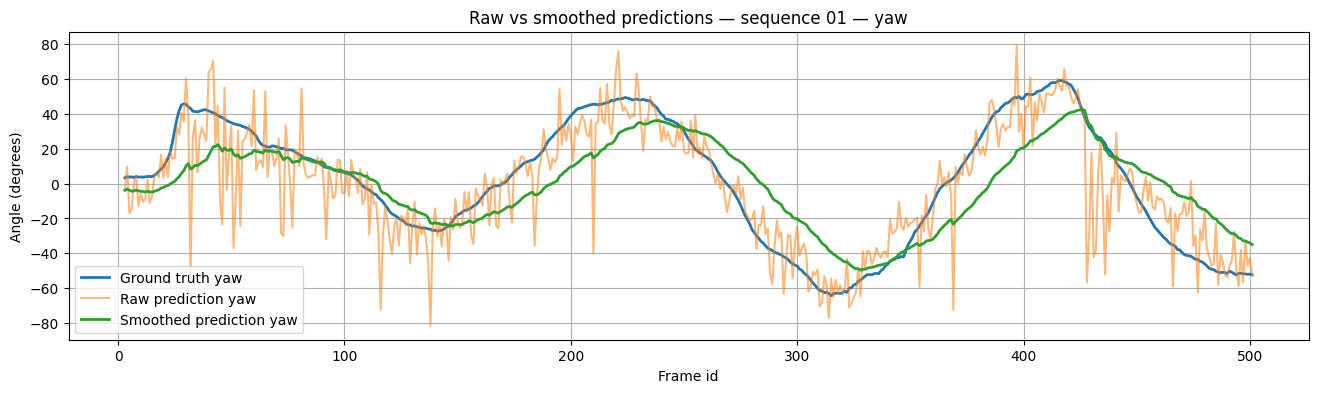

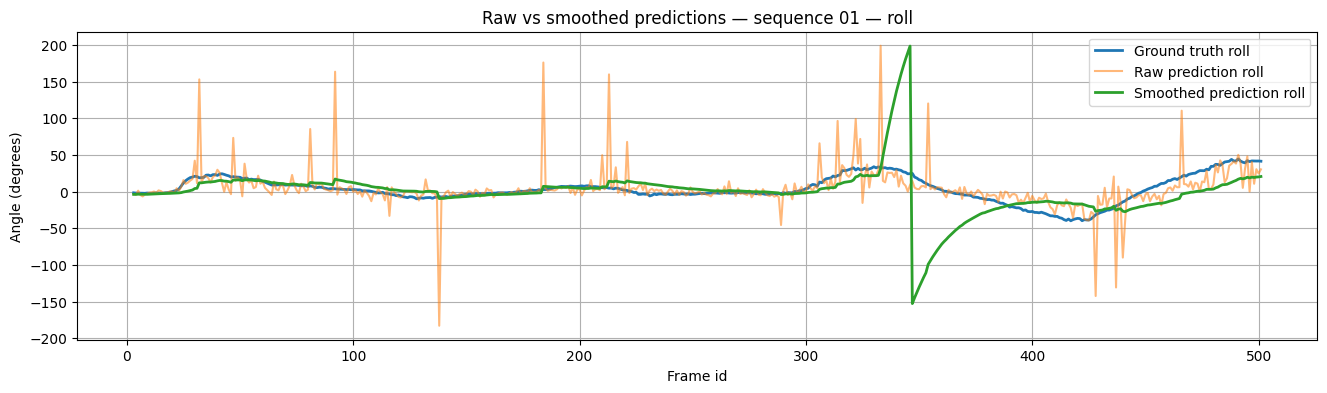

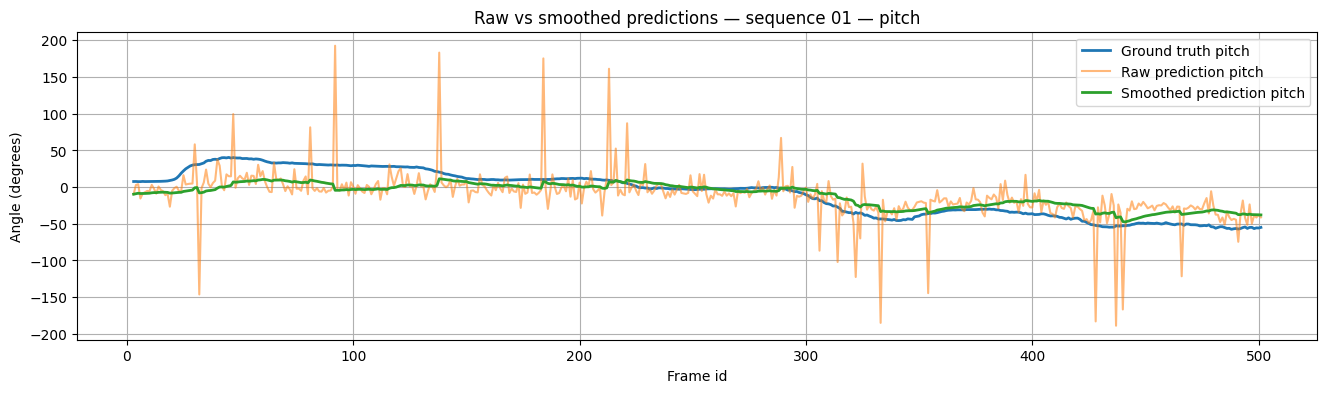

In [116]:
import matplotlib.pyplot as plt
import numpy as np

def align_angle_series_to_reference(angle_values, reference_values):
    """
    For visualization only.
    Shifts each angle by multiples of 360 so that it is closest to the reference angle.
    This avoids misleading vertical jumps at the ±180 degree boundary.
    """
    angle_values = np.asarray(angle_values, dtype=float)
    reference_values = np.asarray(reference_values, dtype=float)
    
    candidates = np.stack([
        angle_values - 360,
        angle_values,
        angle_values + 360
    ], axis=0)
    
    best_indices = np.argmin(np.abs(candidates - reference_values), axis=0)
    aligned = candidates[best_indices, np.arange(len(angle_values))]
    
    return aligned

# Choose a representative test sequence
plot_sequence_id = 1

plot_df = (
    final_smoothed_df[final_smoothed_df["sequence_id"] == plot_sequence_id]
    .sort_values("frame_id")
    .reset_index(drop=True)
)

print(f"Visualizing sequence {plot_sequence_id:02d}")
print("Number of frames:", len(plot_df))

for angle in ["yaw", "roll", "pitch"]:
    gt_values = plot_df[angle].values
    raw_values = align_angle_series_to_reference(
        plot_df[f"pred_{angle}"].values,
        gt_values
    )
    smooth_values = align_angle_series_to_reference(
        plot_df[f"smooth_pred_{angle}"].values,
        gt_values
    )
    
    plt.figure(figsize=(16, 4))
    
    plt.plot(
        plot_df["frame_id"],
        gt_values,
        label=f"Ground truth {angle}",
        linewidth=2
    )
    
    plt.plot(
        plot_df["frame_id"],
        raw_values,
        label=f"Raw prediction {angle}",
        alpha=0.55
    )
    
    plt.plot(
        plot_df["frame_id"],
        smooth_values,
        label=f"Smoothed prediction {angle}",
        linewidth=2
    )
    
    plt.xlabel("Frame id")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Raw vs smoothed predictions — sequence {plot_sequence_id:02d} — {angle}")
    plt.legend()
    plt.grid(True)
    plt.show()

### 10.3 Raw versus smoothed temporal metrics by difficulty regime

We now compare raw and smoothed temporal behavior under different difficulty regimes.

The regimes are defined using the ground-truth motion magnitude and the fisheye-change magnitude. This allows us to check whether smoothing helps similarly in easy and difficult temporal regions, or whether its effect depends on head motion and distortion changes.

In [117]:
# Attach motion and fisheye-change levels from the raw temporal table
# to the smoothed temporal table using the same consecutive pair identifier.

level_columns = [
    "sequence_id",
    "frame_id",
    "motion_level",
    "fisheye_change_level",
    "gt_motion_magnitude_eval",
    "fisheye_change"
]

levels_for_merge = raw_temporal_df[level_columns].copy()

smooth_temporal_with_levels = final_smoothed_temporal_df.merge(
    levels_for_merge,
    on=["sequence_id", "frame_id"],
    how="inner"
)

raw_temporal_for_comparison = raw_temporal_df.merge(
    smooth_temporal_with_levels[["sequence_id", "frame_id"]],
    on=["sequence_id", "frame_id"],
    how="inner"
)

print("Raw temporal pairs used for comparison:", len(raw_temporal_for_comparison))
print("Smoothed temporal pairs used for comparison:", len(smooth_temporal_with_levels))

def compare_temporal_by_group(raw_df, smooth_df, group_col, split_name):
    raw_subset = raw_df[raw_df["split"] == split_name].copy()
    smooth_subset = smooth_df[smooth_df["split"] == split_name].copy()
    
    raw_grouped = (
        raw_subset
        .groupby(group_col)
        .agg(
            num_pairs=("frame_id", "count"),
            raw_mean_gt_motion=("gt_motion_magnitude_eval", "mean"),
            raw_mean_jitter=("pred_jitter_magnitude", "mean"),
            raw_temporal_motion_error=("temporal_motion_error_magnitude", "mean"),
        )
        .reset_index()
    )
    
    smooth_grouped = (
        smooth_subset
        .groupby(group_col)
        .agg(
            smooth_mean_jitter=("smooth_pred_jitter_magnitude", "mean"),
            smooth_temporal_motion_error=("smooth_pred_temporal_motion_error_magnitude", "mean"),
        )
        .reset_index()
    )
    
    comparison = raw_grouped.merge(smooth_grouped, on=group_col, how="inner")
    
    comparison["jitter_reduction_percent"] = (
        100.0 *
        (comparison["raw_mean_jitter"] - comparison["smooth_mean_jitter"])
        / comparison["raw_mean_jitter"]
    )
    
    comparison["temporal_error_reduction_percent"] = (
        100.0 *
        (comparison["raw_temporal_motion_error"] - comparison["smooth_temporal_motion_error"])
        / comparison["raw_temporal_motion_error"]
    )
    
    comparison["split"] = split_name
    
    return comparison

motion_regime_comparison_test = compare_temporal_by_group(
    raw_temporal_for_comparison,
    smooth_temporal_with_levels,
    group_col="motion_level",
    split_name="test"
)

fisheye_regime_comparison_test = compare_temporal_by_group(
    raw_temporal_for_comparison,
    smooth_temporal_with_levels,
    group_col="fisheye_change_level",
    split_name="test"
)

print("Raw vs smoothed temporal metrics by motion level — test split:")
display(motion_regime_comparison_test)

print("\nRaw vs smoothed temporal metrics by fisheye-change level — test split:")
display(fisheye_regime_comparison_test)

Raw temporal pairs used for comparison: 15604
Smoothed temporal pairs used for comparison: 15604
Raw vs smoothed temporal metrics by motion level — test split:


,motion_level,num_pairs,raw_mean_gt_motion,raw_mean_jitter,raw_temporal_motion_error,smooth_mean_jitter,smooth_temporal_motion_error,jitter_reduction_percent,temporal_error_reduction_percent,split
0,high,1293,5.966938,60.432561,60.542117,6.785016,9.178958,88.772582,84.838722,test
1,low,9364,1.320024,40.144778,40.139727,3.455194,3.626563,91.393168,90.965153,test
2,medium,1908,3.106619,53.850748,53.791608,5.392786,6.240580,89.985681,88.398599,test



Raw vs smoothed temporal metrics by fisheye-change level — test split:


,fisheye_change_level,num_pairs,raw_mean_gt_motion,raw_mean_jitter,raw_temporal_motion_error,smooth_mean_jitter,smooth_temporal_motion_error,jitter_reduction_percent,temporal_error_reduction_percent,split
0,high,1269,2.047047,49.564813,49.522650,4.313981,4.780806,91.296283,90.346224,test
1,low,9401,2.061711,43.552209,43.546489,4.059843,4.556064,90.678215,89.537471,test
2,medium,1895,2.123238,44.575285,44.622146,4.103360,4.662878,90.794540,89.550305,test


## 11. Failure analysis

The quantitative results show two main issues:

1. the pretrained frame-by-frame model has high angular error on BIWI-360;
2. the raw predictions contain strong temporal outliers, which produce severe jitter.

We now inspect failure cases visually. First, we look at the frames with the largest mean angular error on the test split. This helps us identify whether large errors are associated with strong fisheye distortion, black warped regions, extreme poses, or unstable model predictions.

Worst frame-level prediction errors on the test split:


,sequence_id,frame_id,yaw,roll,pitch,pred_yaw,pred_roll,pred_pitch,smooth_pred_yaw,smooth_pred_roll,smooth_pred_pitch,err_yaw,err_roll,err_pitch,err_mean,rho,theta
5998,9,512,53.874055,6.076503,16.725867,-70.876396,154.25322,-165.43686,8.473740,10.775421,-4.071411,124.750451,148.176717,177.837273,150.254814,0.482496,-85.453781
15637,24,534,14.971824,-4.028159,6.872905,-74.167760,176.19992,-168.28963,-7.277557,-9.203247,-4.326202,89.139584,179.771921,175.162535,148.024680,0.764363,88.145918
8856,13,458,65.697734,-14.164451,-2.924440,-24.145378,161.19873,-179.78734,52.129761,-20.203674,-40.058105,89.843112,175.363181,176.862900,147.356398,0.787802,105.030581
13012,20,260,25.871164,-2.158364,32.035123,-81.230270,164.13070,-162.92656,-31.184189,19.515717,-12.975464,107.101434,166.289064,165.038317,146.142938,0.026026,-80.254180
6232,9,746,44.697928,-15.289349,-26.799036,-70.539070,179.87130,179.38560,15.950272,-12.196503,-30.042114,115.236998,164.839351,153.815364,144.630571,0.794175,-71.966720
7494,11,400,27.597994,-1.569234,6.479314,-51.126816,174.05353,-174.37563,-3.176453,17.723389,-9.972748,78.724810,175.622764,179.145056,144.497543,0.752066,91.713675
7334,11,240,44.975228,9.912768,24.229610,-37.337852,-176.06473,-167.56093,7.707504,28.344070,-150.153381,82.313080,174.022502,168.209460,141.515014,0.555003,77.461124
9918,15,235,64.012936,26.642886,41.764675,-58.325558,154.30006,-144.19913,-1.556046,57.978149,12.026672,122.338494,127.657174,174.036195,141.343954,0.086545,133.379167


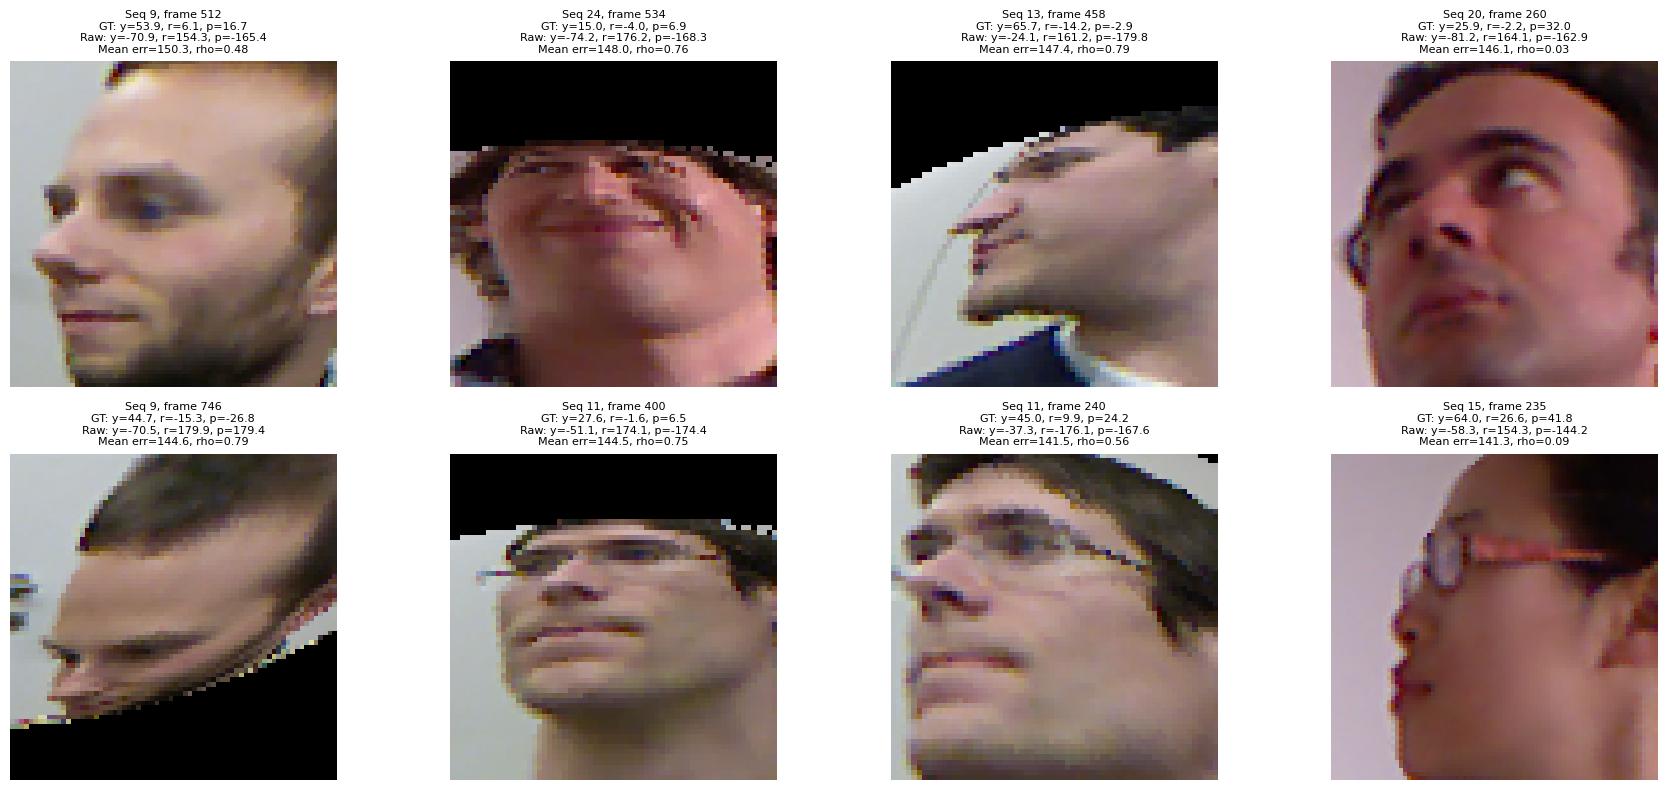

In [118]:
from PIL import Image
import matplotlib.pyplot as plt

# Worst frame-level errors on the test split
worst_frame_errors = (
    final_smoothed_df[final_smoothed_df["split"] == "test"]
    .sort_values("err_mean", ascending=False)
    .head(8)
    .copy()
)

print("Worst frame-level prediction errors on the test split:")
display(
    worst_frame_errors[
        [
            "sequence_id", "frame_id",
            "yaw", "roll", "pitch",
            "pred_yaw", "pred_roll", "pred_pitch",
            "smooth_pred_yaw", "smooth_pred_roll", "smooth_pred_pitch",
            "err_yaw", "err_roll", "err_pitch", "err_mean",
            "rho", "theta"
        ]
    ]
)

plt.figure(figsize=(18, 8))

for i, (_, row) in enumerate(worst_frame_errors.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB")
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Seq {int(row['sequence_id'])}, frame {int(row['frame_id'])}\n"
        f"GT: y={row['yaw']:.1f}, r={row['roll']:.1f}, p={row['pitch']:.1f}\n"
        f"Raw: y={row['pred_yaw']:.1f}, r={row['pred_roll']:.1f}, p={row['pred_pitch']:.1f}\n"
        f"Mean err={row['err_mean']:.1f}, rho={row['rho']:.2f}",
        fontsize=8
    )

plt.tight_layout()
plt.show()

### 11.1 Temporal outlier analysis

The previous examples show large frame-level errors, often associated with strong distortion, partial facial visibility, or extreme predicted angles. We now inspect temporal outliers: consecutive frame pairs where the raw prediction changes abruptly.

This is important because a single extreme prediction can strongly affect both temporal jitter metrics and EMA smoothing. If the model produces isolated outliers, the smoothed trajectory may remain affected for several subsequent frames.

Worst raw temporal jitter events on the test split:


,sequence_id,prev_frame_id_eval,frame_id,yaw,roll,pitch,pred_yaw,pred_roll,pred_pitch,prev_pred_yaw,prev_pred_roll,prev_pred_pitch,gt_motion_magnitude_eval,pred_jitter_magnitude,temporal_motion_error_magnitude,rho,theta,fisheye_change,motion_level,fisheye_change_level
6221,9,746.0,747,45.283021,-15.549258,-27.010221,57.941845,-10.454374,-10.483975,-70.539070,179.871300,179.385600,0.674155,272.472171,272.490825,0.604487,169.163724,0.701663,low,low
9111,14,244.0,245,42.555184,16.676752,46.589256,-61.984715,170.711960,-164.895360,59.483510,5.289853,14.148080,1.537699,272.351899,272.056957,0.620889,77.338989,0.799688,low,low
13584,21,312.0,313,19.580200,-8.361921,49.509294,62.063877,177.983430,178.060620,-44.113594,0.382460,-9.775119,1.553873,269.177066,268.112685,0.768827,81.387184,0.582709,low,low
3780,6,356.0,357,-7.524319,-6.962738,-10.527960,-74.348360,-176.063690,175.764390,-5.367944,4.659939,-8.558890,1.805258,260.308711,259.648789,0.706512,96.833040,0.933843,low,medium
5040,8,336.0,337,-28.264267,-5.642783,5.196704,48.797886,-161.741400,-179.430000,-46.777030,7.263602,-6.369237,2.070266,260.090913,260.636776,0.795389,64.148201,0.810171,low,low
8841,13,458.0,459,62.854153,-11.349928,1.516954,62.476498,-8.597188,-3.520119,-24.145378,161.198730,-179.787340,5.977749,259.623066,259.465889,0.058342,168.221665,0.977072,high,medium
7524,11,443.0,444,55.035073,-14.944150,-10.899110,-5.352636,175.599170,168.757130,64.841960,-8.095066,-8.082684,1.662220,259.390292,259.557453,0.792853,88.593497,0.627647,low,low
13287,21,6.0,7,8.984659,-6.466477,10.876358,-52.573340,164.370160,178.480680,37.992825,-4.031319,3.595054,1.273732,259.125974,259.504118,0.735575,96.430176,0.417729,low,low


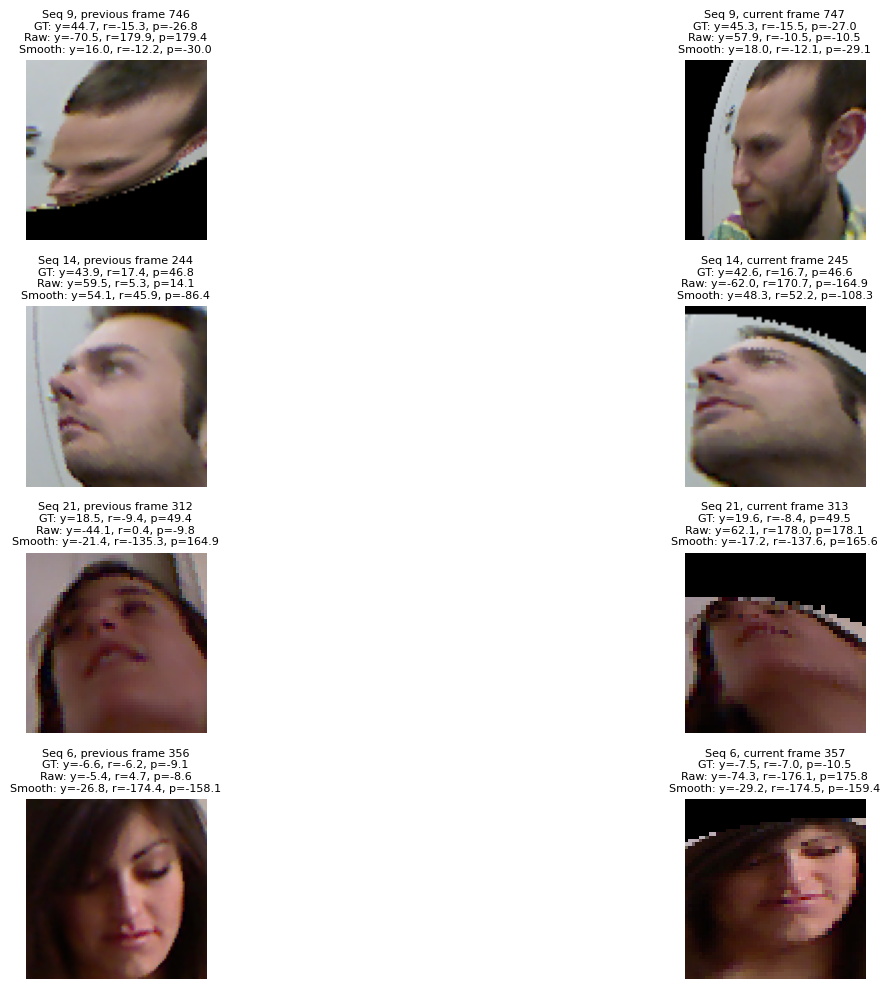

In [119]:
# Worst temporal jitter events on the test split
worst_temporal_outliers = (
    raw_temporal_df[raw_temporal_df["split"] == "test"]
    .sort_values("pred_jitter_magnitude", ascending=False)
    .head(8)
    .copy()
)

print("Worst raw temporal jitter events on the test split:")
display(
    worst_temporal_outliers[
        [
            "sequence_id", "prev_frame_id_eval", "frame_id",
            "yaw", "roll", "pitch",
            "pred_yaw", "pred_roll", "pred_pitch",
            "prev_pred_yaw", "prev_pred_roll", "prev_pred_pitch",
            "gt_motion_magnitude_eval",
            "pred_jitter_magnitude",
            "temporal_motion_error_magnitude",
            "rho", "theta",
            "fisheye_change",
            "motion_level", "fisheye_change_level"
        ]
    ]
)

# Visualize previous/current frames for the top temporal outliers
plt.figure(figsize=(18, 10))

plot_events = worst_temporal_outliers.head(4).reset_index(drop=True)

for i, (_, event_row) in enumerate(plot_events.iterrows()):
    seq_id = int(event_row["sequence_id"])
    prev_frame = int(event_row["prev_frame_id_eval"])
    curr_frame = int(event_row["frame_id"])
    
    prev_row = final_smoothed_df[
        (final_smoothed_df["sequence_id"] == seq_id) &
        (final_smoothed_df["frame_id"] == prev_frame)
    ].iloc[0]
    
    curr_row = final_smoothed_df[
        (final_smoothed_df["sequence_id"] == seq_id) &
        (final_smoothed_df["frame_id"] == curr_frame)
    ].iloc[0]
    
    for j, row in enumerate([prev_row, curr_row]):
        img = Image.open(row["image_path"]).convert("RGB")
        
        subplot_idx = i * 2 + j + 1
        plt.subplot(4, 2, subplot_idx)
        plt.imshow(img)
        plt.axis("off")
        
        label = "previous" if j == 0 else "current"
        plt.title(
            f"Seq {seq_id}, {label} frame {int(row['frame_id'])}\n"
            f"GT: y={row['yaw']:.1f}, r={row['roll']:.1f}, p={row['pitch']:.1f}\n"
            f"Raw: y={row['pred_yaw']:.1f}, r={row['pred_roll']:.1f}, p={row['pred_pitch']:.1f}\n"
            f"Smooth: y={row['smooth_pred_yaw']:.1f}, r={row['smooth_pred_roll']:.1f}, p={row['smooth_pred_pitch']:.1f}",
            fontsize=8
        )

plt.tight_layout()
plt.show()

### 11.2 Interpretation of temporal failures

The temporal failure cases show that the ground-truth head pose often changes only slightly between consecutive frames, while the raw model prediction can jump by more than 250 degrees in angular prediction space.

Visually, these pairs usually contain very similar head poses, but the fisheye distortion pattern may change noticeably. This suggests that the model is not only sensitive to the actual head orientation, but also to the artificial geometric deformation introduced by BIWI-360.

These examples explain why the raw temporal jitter is extremely high. They also explain why EMA smoothing is helpful but imperfect: when a raw prediction contains an extreme outlier near the angular boundary, the smoothed trajectory can be pulled away from the correct pose for several subsequent frames.


In [120]:
# Quantify extreme prediction outliers in the test split

test_df = final_smoothed_df[final_smoothed_df["split"] == "test"].copy()

# Frames where at least one raw predicted angle is close to the ±180 boundary
test_df["has_extreme_raw_angle"] = (
    (test_df["pred_yaw"].abs() > 150) |
    (test_df["pred_roll"].abs() > 150) |
    (test_df["pred_pitch"].abs() > 150)
)

# Frames with very high mean angular error
high_error_threshold = test_df["err_mean"].quantile(0.95)
test_df["is_high_error_frame"] = test_df["err_mean"] >= high_error_threshold

outlier_summary = pd.DataFrame([
    {
        "subset": "all test frames",
        "num_frames": len(test_df),
        "mean_error": test_df["err_mean"].mean(),
        "median_error": test_df["err_mean"].median(),
        "extreme_raw_angle_rate_percent": 100 * test_df["has_extreme_raw_angle"].mean(),
        "high_error_threshold_95pct": high_error_threshold,
    },
    {
        "subset": "frames with extreme raw angle",
        "num_frames": int(test_df["has_extreme_raw_angle"].sum()),
        "mean_error": test_df.loc[test_df["has_extreme_raw_angle"], "err_mean"].mean(),
        "median_error": test_df.loc[test_df["has_extreme_raw_angle"], "err_mean"].median(),
        "extreme_raw_angle_rate_percent": 100.0,
        "high_error_threshold_95pct": high_error_threshold,
    },
    {
        "subset": "frames without extreme raw angle",
        "num_frames": int((~test_df["has_extreme_raw_angle"]).sum()),
        "mean_error": test_df.loc[~test_df["has_extreme_raw_angle"], "err_mean"].mean(),
        "median_error": test_df.loc[~test_df["has_extreme_raw_angle"], "err_mean"].median(),
        "extreme_raw_angle_rate_percent": 0.0,
        "high_error_threshold_95pct": high_error_threshold,
    },
])

print("Extreme raw prediction angle summary:")
display(outlier_summary)

print("\nRelationship between extreme raw angles and high-error frames:")
display(
    pd.crosstab(
        test_df["has_extreme_raw_angle"],
        test_df["is_high_error_frame"],
        rownames=["has_extreme_raw_angle"],
        colnames=["is_high_error_frame"]
    )
)

print("\nWorst frames with extreme raw angles:")
display(
    test_df[test_df["has_extreme_raw_angle"]]
    .sort_values("err_mean", ascending=False)
    .head(10)[
        [
            "sequence_id", "frame_id",
            "yaw", "roll", "pitch",
            "pred_yaw", "pred_roll", "pred_pitch",
            "err_yaw", "err_roll", "err_pitch", "err_mean",
            "rho", "theta"
        ]
    ]
)

Extreme raw prediction angle summary:


,subset,num_frames,mean_error,median_error,extreme_raw_angle_rate_percent,high_error_threshold_95pct
0,all test frames,12629,22.596264,11.774267,5.218149,102.931086
1,frames with extreme raw angle,659,110.339710,110.659281,100.000000,102.931086
2,frames without extreme raw angle,11970,17.765610,11.200104,0.000000,102.931086



Relationship between extreme raw angles and high-error frames:


is_high_error_frame,False,True
has_extreme_raw_angle,,
False,11797,173
True,200,459



Worst frames with extreme raw angles:


,sequence_id,frame_id,yaw,roll,pitch,pred_yaw,pred_roll,pred_pitch,err_yaw,err_roll,err_pitch,err_mean,rho,theta
5998,9,512,53.874055,6.076503,16.725867,-70.876396,154.25322,-165.43686,124.750451,148.176717,177.837273,150.254814,0.482496,-85.453781
15637,24,534,14.971824,-4.028159,6.872905,-74.167760,176.19992,-168.28963,89.139584,179.771921,175.162535,148.024680,0.764363,88.145918
8856,13,458,65.697734,-14.164451,-2.924440,-24.145378,161.19873,-179.78734,89.843112,175.363181,176.862900,147.356398,0.787802,105.030581
13012,20,260,25.871164,-2.158364,32.035123,-81.230270,164.13070,-162.92656,107.101434,166.289064,165.038317,146.142938,0.026026,-80.254180
6232,9,746,44.697928,-15.289349,-26.799036,-70.539070,179.87130,179.38560,115.236998,164.839351,153.815364,144.630571,0.794175,-71.966720
7494,11,400,27.597994,-1.569234,6.479314,-51.126816,174.05353,-174.37563,78.724810,175.622764,179.145056,144.497543,0.752066,91.713675
7334,11,240,44.975228,9.912768,24.229610,-37.337852,-176.06473,-167.56093,82.313080,174.022502,168.209460,141.515014,0.555003,77.461124
9918,15,235,64.012936,26.642886,41.764675,-58.325558,154.30006,-144.19913,122.338494,127.657174,174.036195,141.343954,0.086545,133.379167
12625,19,386,52.912167,15.735368,29.212049,-62.136765,-155.68860,164.30592,115.048932,171.423968,135.093871,140.522257,0.573721,112.395776
610,2,114,-4.871459,1.881710,21.358199,-81.260440,167.20880,-155.18895,76.388981,165.327090,176.547149,139.421073,0.345597,76.328412


### 11.3 Failure analysis summary

The failure analysis shows that the largest errors are not uniformly distributed across all frames. A small subset of frames produces extreme predictions close to the angular boundary, especially in roll and pitch.

On the test split, only about 5.2% of frames contain at least one raw predicted angle with absolute value above 150 degrees. However, these frames have a much higher mean error than the rest of the test set. This indicates that a small number of extreme prediction outliers has a large impact on the overall error distribution and on the temporal jitter.

Visually, many of these failures correspond to frames with strong fisheye deformation, black warped regions, profile-like views, or partial facial visibility. In these cases, the physical head pose label is still valid, but the visual evidence available to the model is strongly distorted. Since 6DRepNet360 is applied frame by frame and was not adapted to BIWI-360, it can interpret the distorted appearance as a very different orientation.

The temporal failures are especially informative. In several consecutive-frame pairs, the ground-truth head pose changes by only a few degrees, while the raw prediction jumps by more than 250 degrees. This suggests that the instability is not caused by true head motion, but by sensitivity to frame-level geometric distortion and isolated prediction outliers.

This also explains the behavior of EMA smoothing: it strongly reduces jitter, but it is not robust to extreme isolated outliers. Once a large outlier enters the smoothed trajectory, the smoothed prediction may remain biased for several subsequent frames.

In [121]:
# Compact summary of the main experimental results

test_frame_row = frame_raw_vs_smooth[frame_raw_vs_smooth["split"] == "test"].iloc[0]
test_temporal_row = temporal_raw_vs_smooth[temporal_raw_vs_smooth["split"] == "test"].iloc[0]

main_results_summary = pd.DataFrame([
    {
        "metric_group": "Frame-level accuracy",
        "metric": "Mean MAE",
        "raw": test_frame_row["raw_mean_mae"],
        "smoothed": test_frame_row["smooth_mean_mae"],
        "change": test_frame_row["delta_mean_mae"],
        "relative_change_percent": 100.0 * test_frame_row["delta_mean_mae"] / test_frame_row["raw_mean_mae"],
        "interpretation": "Smoothed predictions are less accurate frame by frame."
    },
    {
        "metric_group": "Temporal stability",
        "metric": "Mean prediction jitter",
        "raw": test_temporal_row["raw_mean_jitter"],
        "smoothed": test_temporal_row["smooth_mean_jitter"],
        "change": test_temporal_row["delta_jitter"],
        "relative_change_percent": -test_temporal_row["jitter_reduction_percent"],
        "interpretation": "EMA strongly reduces prediction jitter."
    },
    {
        "metric_group": "Temporal consistency",
        "metric": "Mean temporal motion error",
        "raw": test_temporal_row["raw_temporal_motion_error"],
        "smoothed": test_temporal_row["smooth_temporal_motion_error"],
        "change": test_temporal_row["delta_temporal_motion_error"],
        "relative_change_percent": -test_temporal_row["temporal_error_reduction_percent"],
        "interpretation": "EMA makes predicted motion much closer to ground-truth motion."
    }
])

print("Main test-set result summary:")
display(main_results_summary)

summary_csv = "/kaggle/working/main_results_summary.csv"
main_results_summary.to_csv(summary_csv, index=False)

print("Main summary saved to:")
print(summary_csv)

Main test-set result summary:


,metric_group,metric,raw,smoothed,change,relative_change_percent,interpretation
0,Frame-level accuracy,Mean MAE,22.596264,26.579820,3.983556,17.629271,Smoothed predictions are less accurate frame b...
1,Temporal stability,Mean prediction jitter,44.273643,4.092073,-40.181570,-90.757316,EMA strongly reduces prediction jitter.
2,Temporal consistency,Mean temporal motion error,44.272610,4.594871,-39.677739,-89.621414,EMA makes predicted motion much closer to grou...


Main summary saved to:
/kaggle/working/main_results_summary.csv


## 12. Conclusion and thesis direction

This project evaluated the temporal stability of a pretrained 6D head pose estimator on BIWI-360, a fisheye-distorted version of the BIWI head pose dataset. We used 6DRepNet360 as a zero-shot frame-by-frame baseline, without fine-tuning it on BIWI-360.

The frame-level results show that zero-shot transfer to BIWI-360 is difficult. On the test split, the raw predictions obtained a mean MAE of approximately 22.6 degrees. This indicates that the pretrained model is not sufficiently robust to the fisheye-distorted appearance of the input frames. The failure analysis suggests that the largest errors are associated with strong geometric distortion, profile-like views, partial facial visibility, black warped regions, and extreme prediction outliers near the angular boundary.

The temporal analysis shows an even stronger effect. Although the ground-truth head pose usually changes smoothly between consecutive frames, the raw frame-by-frame predictions often jump abruptly. On the test split, the raw mean prediction jitter was approximately 44.3 degrees per frame.

Applying exponential moving average smoothing reduced this temporal instability substantially. With the smoothing parameter selected on the validation split, the test-set mean prediction jitter decreased from approximately 44.3 to 4.1 degrees per frame, corresponding to a reduction of about 90.8%. The temporal motion error was also reduced by about 89.6%.

However, this improvement in temporal stability came at a cost. The test-set mean MAE increased from approximately 22.6 to 26.6 degrees. This confirms the expected trade-off: temporal smoothing can stabilize the prediction signal, but it does not solve the underlying frame-level pose estimation error and can introduce lag or propagate the effect of isolated outliers.

Overall, the hypothesis is partially supported. Temporal post-processing is effective for reducing jitter, but it does not make a frame-by-frame model accurate under fisheye distortion. A stronger solution would require a model explicitly adapted to fisheye geometry, fine-tuning on BIWI-360 or HPE-360, or a more robust temporal method with outlier rejection.

A concrete next step would be to compare EMA against a robust temporal filter, such as median filtering or a Kalman filter with outlier rejection. Another direction would be to fine-tune 6DRepNet360 on fisheye-distorted training data and evaluate whether domain adaptation improves both frame-level accuracy and temporal stability.


In [122]:
print("Notebook completed successfully.")
print()
print("Generated output files:")
print(" - /kaggle/working/biwi360_6drepnet360_fullrotation_predictions.csv")
print(" - /kaggle/working/biwi360_6drepnet360_predictions_with_errors.csv")
print(" - /kaggle/working/biwi360_6drepnet360_raw_and_smoothed_predictions.csv")
print(" - /kaggle/working/main_results_summary.csv")
print()
print("Main test-set results:")
display(main_results_summary)

Notebook completed successfully.

Generated output files:
 - /kaggle/working/biwi360_6drepnet360_fullrotation_predictions.csv
 - /kaggle/working/biwi360_6drepnet360_predictions_with_errors.csv
 - /kaggle/working/biwi360_6drepnet360_raw_and_smoothed_predictions.csv
 - /kaggle/working/main_results_summary.csv

Main test-set results:


,metric_group,metric,raw,smoothed,change,relative_change_percent,interpretation
0,Frame-level accuracy,Mean MAE,22.596264,26.579820,3.983556,17.629271,Smoothed predictions are less accurate frame b...
1,Temporal stability,Mean prediction jitter,44.273643,4.092073,-40.181570,-90.757316,EMA strongly reduces prediction jitter.
2,Temporal consistency,Mean temporal motion error,44.272610,4.594871,-39.677739,-89.621414,EMA makes predicted motion much closer to grou...


# Appendix A. Sanity check on non-fisheye AFLW2000-3D

The main experiment showed that 6DRepNet360 performs poorly on BIWI-360 under fisheye distortion. Before attributing this behavior only to the model, we perform a sanity check on a standard non-fisheye head pose benchmark: AFLW2000-3D.

The goal of this appendix is not to change the main experiment, but to verify that the same pretrained model and inference pipeline behave more reasonably on conventional, non-fisheye face images with standard head pose annotations.

In [123]:
from pathlib import Path

INPUT_ROOT = Path("/kaggle/input")
DATASETS_ROOT = INPUT_ROOT / "datasets"

AFLW2000_ROOT = DATASETS_ROOT / "mohamedadlyi" / "aflw2000-3d" / "AFLW2000"

print("AFLW2000-3D root:", AFLW2000_ROOT)
print("Exists:", AFLW2000_ROOT.exists())

if not AFLW2000_ROOT.exists():
    raise FileNotFoundError("AFLW2000-3D was not found at the expected path. Please check the Kaggle input structure.")

aflw_jpg_count = len(list(AFLW2000_ROOT.glob("*.jpg")))
aflw_mat_count = len(list(AFLW2000_ROOT.glob("*.mat")))

print("Number of .jpg files:", aflw_jpg_count)
print("Number of .mat files:", aflw_mat_count)

AFLW2000-3D root: /kaggle/input/datasets/mohamedadlyi/aflw2000-3d/AFLW2000
Exists: True
Number of .jpg files: 2000
Number of .mat files: 2000


## A.1 Inspecting AFLW2000-3D annotations

AFLW2000-3D contains 2,000 non-fisheye face images with one `.jpg` image and one `.mat` annotation file per sample. Before running inference, we inspect one annotation file to confirm that it contains the expected pose parameters and facial landmarks.

The 6DRepNet360 repository expects AFLW2000-style annotations with `Pose_Para` and `pt2d`, so this check verifies that the dataset is compatible with the model evaluation pipeline.

In [124]:
import scipy.io as sio
import numpy as np
import pandas as pd
from pathlib import Path

aflw_images = sorted(AFLW2000_ROOT.glob("*.jpg"))
aflw_mats = sorted(AFLW2000_ROOT.glob("*.mat"))

sample_mat_path = aflw_mats[0]
sample_mat = sio.loadmat(sample_mat_path)

print("Sample annotation file:")
print(sample_mat_path)

print("\nAvailable keys:")
for key, value in sample_mat.items():
    if not key.startswith("__"):
        print(f"{key}: type={type(value)}, shape={getattr(value, 'shape', None)}, dtype={getattr(value, 'dtype', None)}")

if "Pose_Para" in sample_mat:
    print("\nPose_Para sample:")
    print(sample_mat["Pose_Para"])
    print("\nPose_Para first three values interpreted as pitch, yaw, roll in radians:")
    pose_para = sample_mat["Pose_Para"][0]
    print("pitch rad:", pose_para[0])
    print("yaw rad:  ", pose_para[1])
    print("roll rad: ", pose_para[2])
    print("\nConverted to degrees:")
    print("pitch deg:", pose_para[0] * 180 / np.pi)
    print("yaw deg:  ", pose_para[1] * 180 / np.pi)
    print("roll deg: ", pose_para[2] * 180 / np.pi)

if "pt2d" in sample_mat:
    print("\npt2d shape:")
    print(sample_mat["pt2d"].shape)

Sample annotation file:
/kaggle/input/datasets/mohamedadlyi/aflw2000-3d/AFLW2000/image00002.mat

Available keys:
pt2d: type=<class 'numpy.ndarray'>, shape=(2, 21), dtype=float64
Illum_Para: type=<class 'numpy.ndarray'>, shape=(1, 10), dtype=float64
Color_Para: type=<class 'numpy.ndarray'>, shape=(1, 7), dtype=float32
Tex_Para: type=<class 'numpy.ndarray'>, shape=(199, 1), dtype=float64
Shape_Para: type=<class 'numpy.ndarray'>, shape=(199, 1), dtype=float64
Exp_Para: type=<class 'numpy.ndarray'>, shape=(29, 1), dtype=float64
Pose_Para: type=<class 'numpy.ndarray'>, shape=(1, 7), dtype=float32
roi: type=<class 'numpy.ndarray'>, shape=(1, 4), dtype=int16
pt3d_68: type=<class 'numpy.ndarray'>, shape=(3, 68), dtype=float32

Pose_Para sample:
[[-3.9923078e-01  1.8226579e-02  8.5676216e-02  2.3146532e+02
   2.6206659e+02 -1.0279360e+02  1.5874623e-03]]

Pose_Para first three values interpreted as pitch, yaw, roll in radians:
pitch rad: -0.39923078
yaw rad:   0.018226579
roll rad:  0.085676216

## A.2 Building the AFLW2000-3D evaluation table

The AFLW2000-3D `.mat` files contain the head pose in `Pose_Para`. The first three values correspond to pitch, yaw and roll in radians. For consistency with the rest of the notebook, we convert them to degrees and store them as yaw, roll and pitch.

This appendix is used only as a non-fisheye sanity check. Therefore, we keep the inference pipeline as close as possible to the BIWI-360 experiment.

In [125]:
import scipy.io as sio
import pandas as pd
import numpy as np
from pathlib import Path

def wrap_angle_deg(angle):
    """Wrap angle values to [-180, 180)."""
    return (angle + 180) % 360 - 180

aflw_records = []

for image_path in sorted(AFLW2000_ROOT.glob("*.jpg")):
    mat_path = image_path.with_suffix(".mat")
    
    if not mat_path.exists():
        continue
    
    mat = sio.loadmat(mat_path)
    pose_para = mat["Pose_Para"][0]
    
    # AFLW2000-3D convention in Pose_Para:
    # [pitch, yaw, roll, tdx, tdy, tdz, scale_factor]
    # The first three values are in radians, but some Euler values may appear
    # outside the principal angular range. We therefore convert to degrees
    # and wrap them to [-180, 180).
    pitch_raw_deg = float(pose_para[0]) * 180.0 / np.pi
    yaw_raw_deg = float(pose_para[1]) * 180.0 / np.pi
    roll_raw_deg = float(pose_para[2]) * 180.0 / np.pi
    
    aflw_records.append({
        "image_name": image_path.name,
        "image_path": str(image_path),
        "mat_path": str(mat_path),
        "yaw_raw": yaw_raw_deg,
        "roll_raw": roll_raw_deg,
        "pitch_raw": pitch_raw_deg,
        "yaw": wrap_angle_deg(yaw_raw_deg),
        "roll": wrap_angle_deg(roll_raw_deg),
        "pitch": wrap_angle_deg(pitch_raw_deg),
    })

aflw_df = pd.DataFrame(aflw_records)

print("AFLW2000-3D evaluation table shape:", aflw_df.shape)

print("\nFirst rows:")
display(aflw_df.head())

print("\nRaw pose summary before wrapping:")
display(aflw_df[["yaw_raw", "roll_raw", "pitch_raw"]].describe())

print("\nWrapped pose summary used for evaluation:")
display(aflw_df[["yaw", "roll", "pitch"]].describe())

AFLW2000-3D evaluation table shape: (2000, 9)

First rows:


,image_name,image_path,mat_path,yaw_raw,roll_raw,pitch_raw,yaw,roll,pitch
0,image00002.jpg,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,1.044306,4.908886,-22.874239,1.044306,4.908886,-22.874239
1,image00004.jpg,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,68.155241,17.243670,26.932742,68.155241,17.243670,26.932742
2,image00006.jpg,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,50.485412,-13.570645,-10.579652,50.485412,-13.570645,-10.579652
3,image00008.jpg,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,17.143374,-21.392783,-10.048456,17.143374,-21.392783,-10.048456
4,image00010.jpg,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,/kaggle/input/datasets/mohamedadlyi/aflw2000-3...,68.640546,-59.207973,-50.544581,68.640546,-59.207973,-50.544581



Raw pose summary before wrapping:


,yaw_raw,roll_raw,pitch_raw
count,2000.000000,2000.000000,2000.000000
mean,0.806547,-1.975500,-6.138931
std,37.482043,41.024606,35.988570
min,-351.226933,-972.272838,-713.745097
25%,-16.859080,-10.015671,-14.811132
50%,1.128854,-1.036931,-7.005438
75%,19.177740,7.699269,2.302842
max,187.786940,333.999693,893.746536



Wrapped pose summary used for evaluation:


,yaw,roll,pitch
count,2000.000000,2000.000000,2000.000000
mean,0.806547,-1.075500,-5.418931
std,36.611833,24.235566,22.281393
min,-172.213060,-161.077284,-164.131403
25%,-16.859080,-9.955861,-14.655580
50%,1.128854,-1.010890,-6.922283
75%,19.170067,7.714045,2.403465
max,118.907542,159.192097,173.746536


## A.3 Visual sanity check on AFLW2000-3D

Before running inference, we visualize a few AFLW2000-3D samples together with their wrapped ground-truth yaw, roll and pitch angles. This confirms that the sanity-check dataset contains conventional non-fisheye face images.

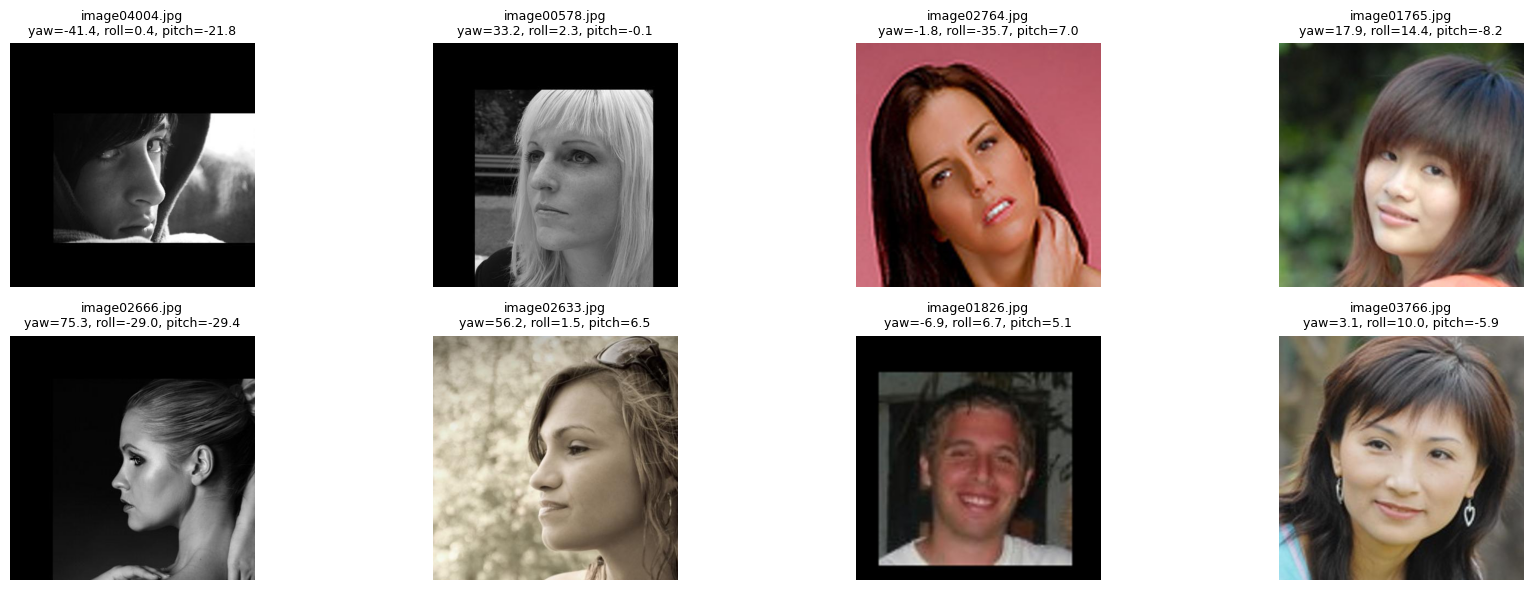

In [126]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

sample_aflw = aflw_df.sample(8, random_state=42).reset_index(drop=True)

plt.figure(figsize=(18, 6))

for i, row in sample_aflw.iterrows():
    img = Image.open(row["image_path"]).convert("RGB")
    
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"{row['image_name']}\n"
        f"yaw={row['yaw']:.1f}, roll={row['roll']:.1f}, pitch={row['pitch']:.1f}",
        fontsize=9
    )

plt.tight_layout()
plt.show()

## A.4 Running 6DRepNet360 on AFLW2000-3D

We now run the same pretrained 6DRepNet360 model on AFLW2000-3D. Unlike BIWI-360, AFLW2000-3D is a conventional non-fisheye benchmark, so this experiment acts as a sanity check for the model and inference pipeline.

For AFLW2000-3D, we crop the face region using the available 2D landmarks (`pt2d`) before applying the same resize, center crop and normalization used by the model.

In [127]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm
import scipy.io as sio
import numpy as np
import pandas as pd
import time
from pathlib import Path

class AFLW2000DatasetForInference(Dataset):
    def __init__(self, dataframe, transform):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def crop_face_with_pt2d(self, image, mat_path):
        mat = sio.loadmat(mat_path)
        pt2d = mat["pt2d"]

        x_min = float(np.min(pt2d[0, :]))
        y_min = float(np.min(pt2d[1, :]))
        x_max = float(np.max(pt2d[0, :]))
        y_max = float(np.max(pt2d[1, :]))

        width = x_max - x_min
        height = y_max - y_min

        # Loose crop, similar in spirit to the official AFLW2000 preprocessing.
        k = 0.20
        x_min = x_min - 2 * k * width
        y_min = y_min - 2 * k * height
        x_max = x_max + 2 * k * width
        y_max = y_max + 0.6 * k * height

        return image.crop((int(x_min), int(y_min), int(x_max), int(y_max)))

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.crop_face_with_pt2d(image, row["mat_path"])

        image = self.transform(image)

        return image, index

aflw_prediction_csv = Path("/kaggle/working/aflw2000_6drepnet360_predictions.csv")

if aflw_prediction_csv.exists():
    print("Loading existing AFLW2000-3D predictions from:", aflw_prediction_csv)
    aflw_pred_df = pd.read_csv(aflw_prediction_csv)
else:
    aflw_dataset = AFLW2000DatasetForInference(aflw_df, inference_transform)
    aflw_loader = DataLoader(
        aflw_dataset,
        batch_size=128,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    pred_yaw = np.zeros(len(aflw_df), dtype=np.float32)
    pred_roll = np.zeros(len(aflw_df), dtype=np.float32)
    pred_pitch = np.zeros(len(aflw_df), dtype=np.float32)

    model.eval()
    start_time = time.time()

    with torch.no_grad():
        for images, indices in tqdm(aflw_loader, desc="Running AFLW2000-3D inference"):
            images = images.to(device, non_blocking=True)

            rotation_matrices = model(images)
            euler = sixd_utils.compute_euler_angles_from_rotation_matrices(rotation_matrices)
            euler_deg = euler.detach().cpu().numpy() * 180.0 / np.pi

            # Repository convention:
            # euler[:, 0] = pitch, euler[:, 1] = yaw, euler[:, 2] = roll
            indices_np = indices.numpy()
            pred_pitch[indices_np] = euler_deg[:, 0]
            pred_yaw[indices_np] = euler_deg[:, 1]
            pred_roll[indices_np] = euler_deg[:, 2]

    elapsed = time.time() - start_time

    aflw_pred_df = aflw_df.copy()
    aflw_pred_df["pred_yaw"] = pred_yaw
    aflw_pred_df["pred_roll"] = pred_roll
    aflw_pred_df["pred_pitch"] = pred_pitch

    aflw_pred_df.to_csv(aflw_prediction_csv, index=False)

    print(f"AFLW2000-3D inference completed in {elapsed:.2f} seconds.")
    print(f"Average speed: {len(aflw_pred_df) / elapsed:.2f} frames/second.")
    print("Predictions saved to:", aflw_prediction_csv)

print("AFLW2000-3D prediction table shape:", aflw_pred_df.shape)

print("\nPrediction preview:")
display(aflw_pred_df[[
    "image_name",
    "yaw", "roll", "pitch",
    "pred_yaw", "pred_roll", "pred_pitch"
]].head())

print("\nPrediction summary:")
display(aflw_pred_df[["pred_yaw", "pred_roll", "pred_pitch"]].describe())

Loading existing AFLW2000-3D predictions from: /kaggle/working/aflw2000_6drepnet360_predictions.csv
AFLW2000-3D prediction table shape: (2000, 12)

Prediction preview:


,image_name,yaw,roll,pitch,pred_yaw,pred_roll,pred_pitch
0,image00002.jpg,1.044306,4.908886,-22.874239,2.653513,4.699481,-17.231188
1,image00004.jpg,68.155241,17.243670,26.932742,63.499775,15.963361,24.122458
2,image00006.jpg,50.485412,-13.570645,-10.579652,36.625687,-8.763353,-10.252538
3,image00008.jpg,17.143374,-21.392783,-10.048456,14.361500,-21.054016,-17.879030
4,image00010.jpg,68.640546,-59.207973,-50.544581,68.612160,-70.097840,-72.951760



Prediction summary:


,pred_yaw,pred_roll,pred_pitch
count,2000.000000,2000.000000,2000.000000
mean,-2.382340,-1.909897,-4.871856
std,37.862806,30.883994,28.941095
min,-88.062000,-179.480670,-177.180080
25%,-22.325544,-10.634272,-12.481963
50%,-1.687401,-1.363595,-5.921751
75%,16.066055,6.453628,1.650722
max,88.667770,179.611190,168.595020


## A.5 AFLW2000-3D angle convention diagnostic and metrics

Before using AFLW2000-3D as a sanity check, we repeat the same angle convention diagnostic used for BIWI-360. We test all permutations of predicted angles and sign combinations.

If the raw convention is again the best option, we compute MAE and RMSE directly using the same yaw, roll and pitch assignment.

In [128]:
import itertools
import numpy as np
import pandas as pd

gt_cols = ["yaw", "roll", "pitch"]
pred_cols = ["pred_yaw", "pred_roll", "pred_pitch"]

diagnostic_rows = []

for perm in itertools.permutations(pred_cols):
    for signs in itertools.product([1, -1], repeat=3):
        errors = {}
        
        for gt_col, pred_col, sign in zip(gt_cols, perm, signs):
            errors[gt_col] = angular_diff_array_deg(
                sign * aflw_pred_df[pred_col].values,
                aflw_pred_df[gt_col].values
            )
        
        mae_yaw = errors["yaw"].mean()
        mae_roll = errors["roll"].mean()
        mae_pitch = errors["pitch"].mean()
        mean_mae = np.mean([mae_yaw, mae_roll, mae_pitch])
        
        diagnostic_rows.append({
            "pred_for_yaw": perm[0],
            "pred_for_roll": perm[1],
            "pred_for_pitch": perm[2],
            "sign_yaw": signs[0],
            "sign_roll": signs[1],
            "sign_pitch": signs[2],
            "mae_yaw": mae_yaw,
            "mae_roll": mae_roll,
            "mae_pitch": mae_pitch,
            "mean_mae": mean_mae,
        })

aflw_angle_diagnostic = (
    pd.DataFrame(diagnostic_rows)
    .sort_values("mean_mae")
    .reset_index(drop=True)
)

print("Best AFLW2000-3D angle assignment and sign combinations:")
display(aflw_angle_diagnostic.head(15))

print("\nRaw convention result:")
aflw_raw_result = aflw_angle_diagnostic[
    (aflw_angle_diagnostic["pred_for_yaw"] == "pred_yaw") &
    (aflw_angle_diagnostic["pred_for_roll"] == "pred_roll") &
    (aflw_angle_diagnostic["pred_for_pitch"] == "pred_pitch") &
    (aflw_angle_diagnostic["sign_yaw"] == 1) &
    (aflw_angle_diagnostic["sign_roll"] == 1) &
    (aflw_angle_diagnostic["sign_pitch"] == 1)
]
display(aflw_raw_result)

# Compute final AFLW2000-3D frame-level errors using raw convention
for angle in ["yaw", "roll", "pitch"]:
    aflw_pred_df[f"err_{angle}"] = angular_diff_array_deg(
        aflw_pred_df[f"pred_{angle}"],
        aflw_pred_df[angle]
    )

aflw_pred_df["err_mean"] = aflw_pred_df[["err_yaw", "err_roll", "err_pitch"]].mean(axis=1)

aflw_metrics = pd.DataFrame([{
    "dataset": "AFLW2000-3D non-fisheye",
    "num_frames": len(aflw_pred_df),
    "mae_yaw": aflw_pred_df["err_yaw"].mean(),
    "mae_roll": aflw_pred_df["err_roll"].mean(),
    "mae_pitch": aflw_pred_df["err_pitch"].mean(),
    "mean_mae": aflw_pred_df[["err_yaw", "err_roll", "err_pitch"]].mean().mean(),
    "rmse_yaw": np.sqrt(np.mean(aflw_pred_df["err_yaw"] ** 2)),
    "rmse_roll": np.sqrt(np.mean(aflw_pred_df["err_roll"] ** 2)),
    "rmse_pitch": np.sqrt(np.mean(aflw_pred_df["err_pitch"] ** 2)),
}])

aflw_metrics["mean_rmse"] = aflw_metrics[["rmse_yaw", "rmse_roll", "rmse_pitch"]].mean(axis=1)

print("\nAFLW2000-3D sanity-check metrics:")
display(aflw_metrics)

print("\nAFLW2000-3D error distribution:")
display(aflw_pred_df[["err_yaw", "err_roll", "err_pitch", "err_mean"]].describe())

aflw_output_csv = "/kaggle/working/aflw2000_6drepnet360_predictions_with_errors.csv"
aflw_pred_df.to_csv(aflw_output_csv, index=False)

print("\nAFLW2000-3D predictions with errors saved to:")
print(aflw_output_csv)

Best AFLW2000-3D angle assignment and sign combinations:


,pred_for_yaw,pred_for_roll,pred_for_pitch,sign_yaw,sign_roll,sign_pitch,mae_yaw,mae_roll,mae_pitch,mean_mae
0,pred_yaw,pred_roll,pred_pitch,1,1,1,5.476733,5.866819,7.822874,6.388808
1,pred_yaw,pred_roll,pred_pitch,1,1,-1,5.476733,5.866819,29.465042,13.602864
2,pred_yaw,pred_roll,pred_pitch,1,-1,1,5.476733,30.093771,7.822874,14.464459
3,pred_yaw,pred_pitch,pred_roll,1,1,1,5.476733,19.994818,21.183583,15.551711
4,pred_yaw,pred_pitch,pred_roll,1,1,-1,5.476733,19.994818,21.417165,15.629572
5,pred_yaw,pred_pitch,pred_roll,1,-1,1,5.476733,20.572983,21.183583,15.744433
6,pred_yaw,pred_pitch,pred_roll,1,-1,-1,5.476733,20.572983,21.417165,15.822294
7,pred_roll,pred_yaw,pred_pitch,-1,-1,1,27.559397,28.967982,7.822874,21.450084
8,pred_yaw,pred_roll,pred_pitch,1,-1,-1,5.476733,30.093771,29.465042,21.678515
9,pred_pitch,pred_roll,pred_yaw,-1,1,1,28.729967,5.866819,31.166319,21.921035



Raw convention result:


,pred_for_yaw,pred_for_roll,pred_for_pitch,sign_yaw,sign_roll,sign_pitch,mae_yaw,mae_roll,mae_pitch,mean_mae
0,pred_yaw,pred_roll,pred_pitch,1,1,1,5.476733,5.866819,7.822874,6.388808



AFLW2000-3D sanity-check metrics:


,dataset,num_frames,mae_yaw,mae_roll,mae_pitch,mean_mae,rmse_yaw,rmse_roll,rmse_pitch,mean_rmse
0,AFLW2000-3D non-fisheye,2000,5.476733,5.866819,7.822874,6.388808,10.083944,19.602597,20.038184,16.574909



AFLW2000-3D error distribution:


,err_yaw,err_roll,err_pitch,err_mean
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,5.476733,5.866819,7.822874,6.388808
std,8.469191,18.708748,18.452689,13.674932
min,0.009722,0.000907,0.002940,0.147978
25%,1.724605,0.756170,1.706054,2.170510
50%,3.694763,1.736460,3.922340,3.553771
75%,6.611863,3.642508,7.594737,5.518661
max,152.512930,179.784733,179.165655,142.277996



AFLW2000-3D predictions with errors saved to:
/kaggle/working/aflw2000_6drepnet360_predictions_with_errors.csv


## A.6 Comparing the sanity check with BIWI-360

The AFLW2000-3D sanity check provides an important reference point. If the model and angle-conversion pipeline were incorrect, we would expect poor results on AFLW2000-3D as well.

Instead, the same pretrained 6DRepNet360 model achieves much lower error on AFLW2000-3D than on BIWI-360. This supports the interpretation that the poor BIWI-360 performance is mainly caused by the fisheye domain shift and frame-wise geometric distortions, rather than by a broken inference implementation.

In [129]:
# Compare BIWI-360 test performance with AFLW2000-3D sanity-check performance

biwi_test_metrics_for_comparison = frame_metrics[frame_metrics["split"] == "test"].iloc[0]

dataset_comparison = pd.DataFrame([
    {
        "dataset": "BIWI-360 fisheye test",
        "num_frames": int(biwi_test_metrics_for_comparison["num_frames"]),
        "mae_yaw": biwi_test_metrics_for_comparison["mae_yaw"],
        "mae_roll": biwi_test_metrics_for_comparison["mae_roll"],
        "mae_pitch": biwi_test_metrics_for_comparison["mae_pitch"],
        "mean_mae": biwi_test_metrics_for_comparison["mean_mae"],
        "mean_rmse": biwi_test_metrics_for_comparison["mean_rmse"],
    },
    {
        "dataset": "AFLW2000-3D non-fisheye",
        "num_frames": int(aflw_metrics.iloc[0]["num_frames"]),
        "mae_yaw": aflw_metrics.iloc[0]["mae_yaw"],
        "mae_roll": aflw_metrics.iloc[0]["mae_roll"],
        "mae_pitch": aflw_metrics.iloc[0]["mae_pitch"],
        "mean_mae": aflw_metrics.iloc[0]["mean_mae"],
        "mean_rmse": aflw_metrics.iloc[0]["mean_rmse"],
    }
])

print("BIWI-360 vs AFLW2000-3D comparison:")
display(dataset_comparison)

print("\nRelative increase in mean MAE from AFLW2000-3D to BIWI-360:")
relative_increase = (
    (dataset_comparison.loc[0, "mean_mae"] - dataset_comparison.loc[1, "mean_mae"])
    / dataset_comparison.loc[1, "mean_mae"]
    * 100.0
)
print(f"{relative_increase:.2f}%")

comparison_csv = "/kaggle/working/biwi360_vs_aflw2000_sanity_check.csv"
dataset_comparison.to_csv(comparison_csv, index=False)

print("\nComparison saved to:")
print(comparison_csv)

BIWI-360 vs AFLW2000-3D comparison:


,dataset,num_frames,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_rmse
0,BIWI-360 fisheye test,12629,16.992973,21.132519,29.663300,22.596264,39.485479
1,AFLW2000-3D non-fisheye,2000,5.476733,5.866819,7.822874,6.388808,16.574909



Relative increase in mean MAE from AFLW2000-3D to BIWI-360:
253.69%

Comparison saved to:
/kaggle/working/biwi360_vs_aflw2000_sanity_check.csv


## A.7 Visual comparison of BIWI-360 and AFLW2000-3D results

To make the sanity check easier to interpret, we visualize the difference between the BIWI-360 fisheye test split and the non-fisheye AFLW2000-3D benchmark.

The goal of these plots is to show whether the same model and inference pipeline behave substantially better on conventional non-fisheye images than on BIWI-360.

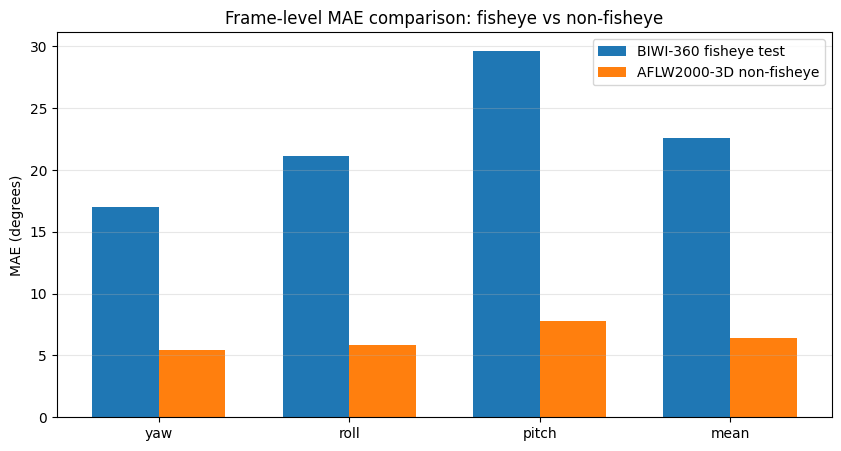

/tmp/ipykernel_58/674775543.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


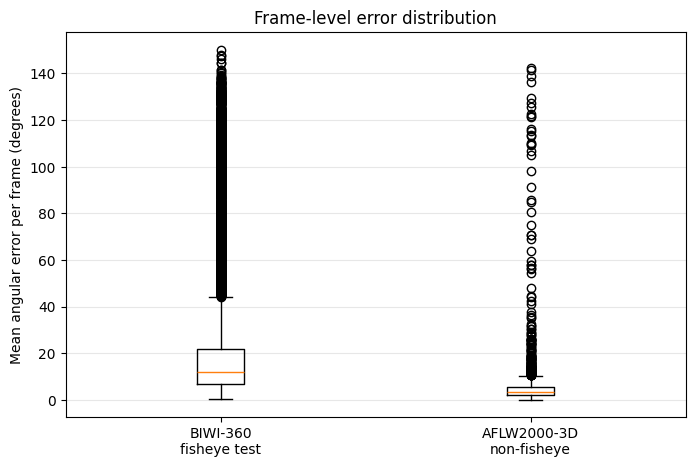

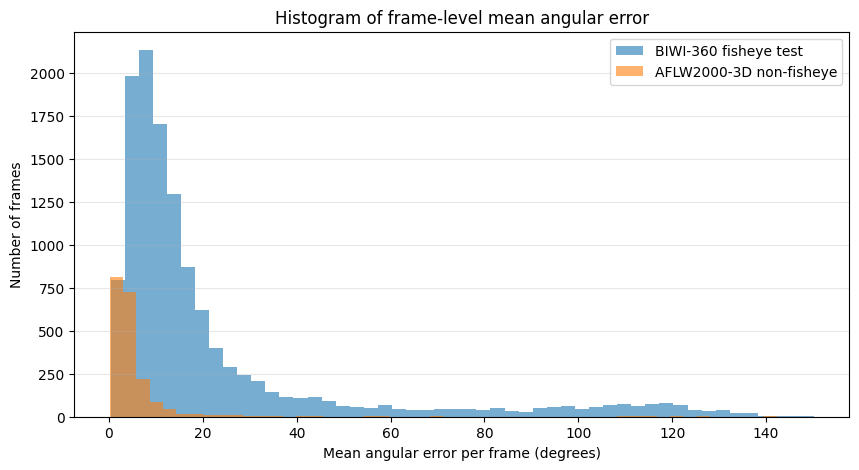

In [130]:
import matplotlib.pyplot as plt
import numpy as np

# --- Bar plot: MAE by angle for both datasets ---
angle_labels = ["yaw", "roll", "pitch", "mean"]
biwi_mae_values = [
    dataset_comparison.loc[dataset_comparison["dataset"] == "BIWI-360 fisheye test", "mae_yaw"].iloc[0],
    dataset_comparison.loc[dataset_comparison["dataset"] == "BIWI-360 fisheye test", "mae_roll"].iloc[0],
    dataset_comparison.loc[dataset_comparison["dataset"] == "BIWI-360 fisheye test", "mae_pitch"].iloc[0],
    dataset_comparison.loc[dataset_comparison["dataset"] == "BIWI-360 fisheye test", "mean_mae"].iloc[0],
]

aflw_mae_values = [
    dataset_comparison.loc[dataset_comparison["dataset"] == "AFLW2000-3D non-fisheye", "mae_yaw"].iloc[0],
    dataset_comparison.loc[dataset_comparison["dataset"] == "AFLW2000-3D non-fisheye", "mae_roll"].iloc[0],
    dataset_comparison.loc[dataset_comparison["dataset"] == "AFLW2000-3D non-fisheye", "mae_pitch"].iloc[0],
    dataset_comparison.loc[dataset_comparison["dataset"] == "AFLW2000-3D non-fisheye", "mean_mae"].iloc[0],
]

x = np.arange(len(angle_labels))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width / 2, biwi_mae_values, width, label="BIWI-360 fisheye test")
plt.bar(x + width / 2, aflw_mae_values, width, label="AFLW2000-3D non-fisheye")

plt.xticks(x, angle_labels)
plt.ylabel("MAE (degrees)")
plt.title("Frame-level MAE comparison: fisheye vs non-fisheye")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

# --- Boxplot: mean error distribution ---
biwi_test_errors = final_smoothed_df[final_smoothed_df["split"] == "test"]["err_mean"].values
aflw_errors = aflw_pred_df["err_mean"].values

plt.figure(figsize=(8, 5))
plt.boxplot(
    [biwi_test_errors, aflw_errors],
    labels=["BIWI-360\nfisheye test", "AFLW2000-3D\nnon-fisheye"],
    showfliers=True
)
plt.ylabel("Mean angular error per frame (degrees)")
plt.title("Frame-level error distribution")
plt.grid(axis="y", alpha=0.3)
plt.show()

# --- Histogram: error distribution with same range ---
plt.figure(figsize=(10, 5))
plt.hist(biwi_test_errors, bins=50, alpha=0.6, label="BIWI-360 fisheye test")
plt.hist(aflw_errors, bins=50, alpha=0.6, label="AFLW2000-3D non-fisheye")
plt.xlabel("Mean angular error per frame (degrees)")
plt.ylabel("Number of frames")
plt.title("Histogram of frame-level mean angular error")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

## A.8 Standard angle-range protocol check

Some head pose papers report AFLW2000-3D results using a standard angular range protocol, commonly keeping only samples whose Euler angles lie within approximately ±99 degrees. Our previous AFLW2000-3D sanity check used all 2,000 images after wrapping the Euler angles to the principal range.

This sanity check is not intended to exactly reproduce the benchmark protocol from the papers, because we may use a slightly different checkpoint, crop procedure, and Kaggle copy of the dataset. However, we also report the metrics on the ±99 degree subset to make the comparison more transparent.

AFLW2000-3D total frames: 2000
AFLW2000-3D frames within ±99°: 1969
Frames removed by ±99° filter: 31

AFLW2000-3D sanity-check metrics with and without ±99° filtering:


,subset,num_frames,mae_yaw,mae_roll,mae_pitch,mean_mae,rmse_yaw,rmse_roll,rmse_pitch,mean_rmse
0,all AFLW2000-3D samples,2000,5.476733,5.866819,7.822874,6.388808,10.083944,19.602597,20.038184,16.574909
1,AFLW2000-3D within ±99°,1969,5.318565,5.102971,7.220922,5.880820,9.280864,16.897497,17.812437,14.663599


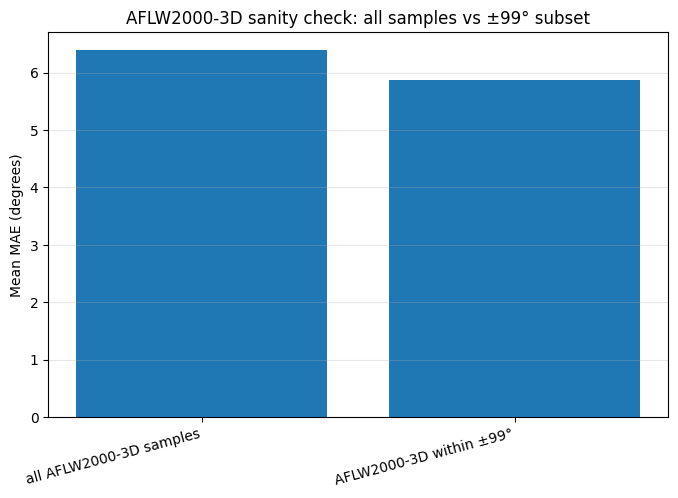

In [131]:
# AFLW2000-3D metrics with and without the common ±99 degree angular range filter

aflw_range_mask = (
    (aflw_pred_df["yaw"].abs() <= 99) &
    (aflw_pred_df["roll"].abs() <= 99) &
    (aflw_pred_df["pitch"].abs() <= 99)
)

print("AFLW2000-3D total frames:", len(aflw_pred_df))
print("AFLW2000-3D frames within ±99°:", int(aflw_range_mask.sum()))
print("Frames removed by ±99° filter:", int((~aflw_range_mask).sum()))

def summarize_aflw_subset(dataframe, label):
    return {
        "subset": label,
        "num_frames": len(dataframe),
        "mae_yaw": dataframe["err_yaw"].mean(),
        "mae_roll": dataframe["err_roll"].mean(),
        "mae_pitch": dataframe["err_pitch"].mean(),
        "mean_mae": dataframe[["err_yaw", "err_roll", "err_pitch"]].mean().mean(),
        "rmse_yaw": np.sqrt(np.mean(dataframe["err_yaw"] ** 2)),
        "rmse_roll": np.sqrt(np.mean(dataframe["err_roll"] ** 2)),
        "rmse_pitch": np.sqrt(np.mean(dataframe["err_pitch"] ** 2)),
        "mean_rmse": np.mean([
            np.sqrt(np.mean(dataframe["err_yaw"] ** 2)),
            np.sqrt(np.mean(dataframe["err_roll"] ** 2)),
            np.sqrt(np.mean(dataframe["err_pitch"] ** 2)),
        ]),
    }

aflw_range_comparison = pd.DataFrame([
    summarize_aflw_subset(aflw_pred_df, "all AFLW2000-3D samples"),
    summarize_aflw_subset(aflw_pred_df[aflw_range_mask].copy(), "AFLW2000-3D within ±99°"),
])

print("\nAFLW2000-3D sanity-check metrics with and without ±99° filtering:")
display(aflw_range_comparison)

# Plot the comparison
plt.figure(figsize=(8, 5))
plt.bar(
    aflw_range_comparison["subset"],
    aflw_range_comparison["mean_mae"]
)
plt.ylabel("Mean MAE (degrees)")
plt.title("AFLW2000-3D sanity check: all samples vs ±99° subset")
plt.xticks(rotation=15, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

## A.9 Sanity check conclusion

The AFLW2000-3D sanity check confirms that the 6DRepNet360 inference pipeline is working correctly. Using the same model and angle convention, the mean MAE is much lower on non-fisheye AFLW2000-3D than on BIWI-360.

When all AFLW2000-3D samples are used, the model obtains a mean MAE of approximately 6.39 degrees. When applying the common ±99 degree angle-range filter, only 31 out of 2,000 samples are removed and the mean MAE decreases to approximately 5.88 degrees.

These values are still not intended to exactly reproduce the benchmark results reported in the literature, because our checkpoint, cropping procedure and dataset copy may not be identical to the original protocol. However, the sanity check shows that the model behaves reasonably on conventional non-fisheye images.

Therefore, the much larger error on BIWI-360 is unlikely to be caused by a basic implementation error in model loading, angle conversion or inference. It is more consistent with a strong domain shift caused by fisheye distortion and frame-wise geometric deformation in HPE-360.

# Appendix B. BIWI-360 sensitivity analysis and simple baselines

The official BIWI-360 results are computed using all test frames. However, the previous analysis showed that the zero-shot model is strongly affected by fisheye deformation and by isolated extreme predictions near the angular boundary.

This appendix does not replace the official evaluation. Instead, it performs a sensitivity analysis to better understand why the pretrained frame-by-frame model performs poorly on BIWI-360.

We analyze four aspects:

1. whether the error increases with the fisheye radial parameter `rho`;
2. whether the common ±99 degree angle-range protocol changes the BIWI-360 evaluation;
3. whether 6DRepNet360 performs better than simple trivial baselines;
4. how much extreme raw prediction outliers affect both frame-level accuracy and temporal smoothing.

Filtered results in this appendix should not be interpreted as the main benchmark result. They are used only to understand the behavior of the model under different subsets and assumptions.

In [132]:
# Appendix B.0: Setup and official reference metrics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_objects = [
    "final_smoothed_df",
    "raw_temporal_df",
    "final_smoothed_temporal_df",
    "frame_raw_vs_smooth",
    "temporal_raw_vs_smooth",
]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(
        "The following required objects are missing. "
        "Please run the main BIWI-360 experiment before Appendix B: "
        + ", ".join(missing_objects)
    )

# Main BIWI-360 test table used throughout Appendix B
biwi_test_df = final_smoothed_df[final_smoothed_df["split"] == "test"].copy()

# Add an extreme raw prediction flag.
# This is based only on the raw model output, not on the ground-truth error.
biwi_test_df["has_extreme_raw_angle"] = (
    (biwi_test_df["pred_yaw"].abs() > 150) |
    (biwi_test_df["pred_roll"].abs() > 150) |
    (biwi_test_df["pred_pitch"].abs() > 150)
)

# Official reference results from the main experiment
official_frame_test = frame_raw_vs_smooth[frame_raw_vs_smooth["split"] == "test"].iloc[0]
official_temporal_test = temporal_raw_vs_smooth[temporal_raw_vs_smooth["split"] == "test"].iloc[0]

official_reference = pd.DataFrame([
    {
        "metric_group": "Frame-level accuracy",
        "metric": "Mean MAE",
        "raw": official_frame_test["raw_mean_mae"],
        "smoothed": official_frame_test["smooth_mean_mae"],
        "change_smooth_minus_raw": official_frame_test["delta_mean_mae"],
    },
    {
        "metric_group": "Temporal stability",
        "metric": "Mean prediction jitter",
        "raw": official_temporal_test["raw_mean_jitter"],
        "smoothed": official_temporal_test["smooth_mean_jitter"],
        "change_smooth_minus_raw": official_temporal_test["delta_jitter"],
    },
    {
        "metric_group": "Temporal consistency",
        "metric": "Mean temporal motion error",
        "raw": official_temporal_test["raw_temporal_motion_error"],
        "smoothed": official_temporal_test["smooth_temporal_motion_error"],
        "change_smooth_minus_raw": official_temporal_test["delta_temporal_motion_error"],
    },
])

print("BIWI-360 test frames used in Appendix B:", len(biwi_test_df))
print("Frames with at least one extreme raw predicted angle:",
      int(biwi_test_df["has_extreme_raw_angle"].sum()))
print("Extreme raw angle rate (%):",
      100.0 * biwi_test_df["has_extreme_raw_angle"].mean())

print("\nOfficial BIWI-360 test reference metrics:")
display(official_reference)

BIWI-360 test frames used in Appendix B: 12629
Frames with at least one extreme raw predicted angle: 659
Extreme raw angle rate (%): 5.218148705360678

Official BIWI-360 test reference metrics:


,metric_group,metric,raw,smoothed,change_smooth_minus_raw
0,Frame-level accuracy,Mean MAE,22.596264,26.579820,3.983556
1,Temporal stability,Mean prediction jitter,44.273643,4.092073,-40.181570
2,Temporal consistency,Mean temporal motion error,44.272610,4.594871,-39.677739


## B.1 Error by fisheye distortion level

We first analyze performance by `rho`, the normalized radial position used to generate the fisheye distortion. Larger `rho` values indicate that the face was placed farther from the fisheye center before distortion, which should generally lead to stronger geometric deformation.

We split the valid `rho` range `[0, 0.8]` into three fixed intervals: low, medium and high. This analysis uses only metadata from the dataset and does not depend on model error, so it is not a post-hoc filtering criterion.

We report both raw and EMA-smoothed frame-level errors, together with the percentage of frames that contain at least one extreme raw predicted angle.

Frame-level BIWI-360 test metrics by rho level:


,rho_level,num_frames,mean_rho,raw_mae_yaw,raw_mae_roll,raw_mae_pitch,raw_mean_mae,smooth_mae_yaw,smooth_mae_roll,smooth_mae_pitch,smooth_mean_mae,extreme_raw_angle_rate_percent,delta_smooth_minus_raw_mae
0,low rho,4272,0.133492,15.354798,16.906745,24.298531,18.853358,17.674597,25.699394,35.115667,26.163219,4.026217,7.309861
1,medium rho,4158,0.401450,15.701070,18.787271,27.409839,20.632727,17.760235,27.405143,36.242938,27.136105,3.944204,6.503379
2,high rho,4199,0.665275,19.938916,27.754106,37.352794,28.348605,17.755809,25.989944,35.612680,26.452811,7.692308,-1.895794


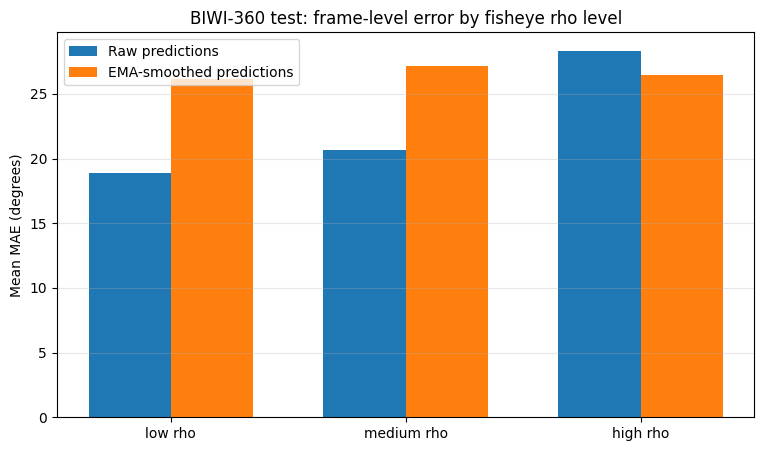

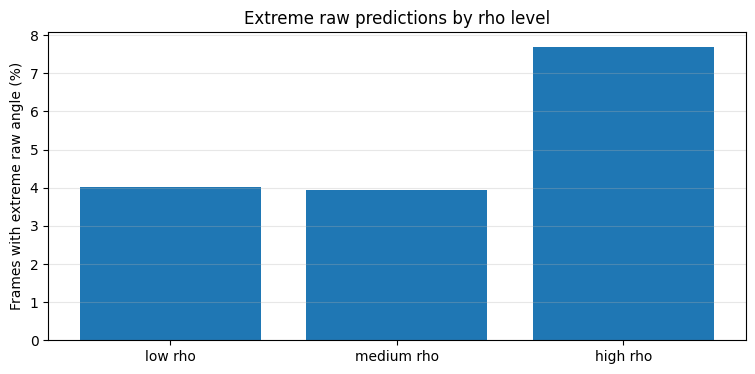

In [133]:
# Appendix B.1: Frame-level raw and smoothed errors by rho level

rho_bins = [0.0, 0.8 / 3, 2 * 0.8 / 3, 0.8 + 1e-6]
rho_labels = ["low rho", "medium rho", "high rho"]

biwi_test_df["rho_level"] = pd.cut(
    biwi_test_df["rho"],
    bins=rho_bins,
    labels=rho_labels,
    include_lowest=True
)

rho_frame_summary = (
    biwi_test_df
    .groupby("rho_level", observed=False)
    .agg(
        num_frames=("frame_id", "count"),
        mean_rho=("rho", "mean"),
        raw_mae_yaw=("err_yaw", "mean"),
        raw_mae_roll=("err_roll", "mean"),
        raw_mae_pitch=("err_pitch", "mean"),
        raw_mean_mae=("err_mean", "mean"),
        smooth_mae_yaw=("smooth_err_yaw", "mean"),
        smooth_mae_roll=("smooth_err_roll", "mean"),
        smooth_mae_pitch=("smooth_err_pitch", "mean"),
        smooth_mean_mae=("smooth_err_mean", "mean"),
        extreme_raw_angle_rate_percent=("has_extreme_raw_angle", lambda x: 100.0 * x.mean()),
    )
    .reset_index()
)

rho_frame_summary["delta_smooth_minus_raw_mae"] = (
    rho_frame_summary["smooth_mean_mae"] - rho_frame_summary["raw_mean_mae"]
)

print("Frame-level BIWI-360 test metrics by rho level:")
display(rho_frame_summary)

# Plot raw vs smoothed mean MAE by rho level
plt.figure(figsize=(9, 5))
x = np.arange(len(rho_frame_summary))
width = 0.35

plt.bar(
    x - width / 2,
    rho_frame_summary["raw_mean_mae"],
    width,
    label="Raw predictions"
)
plt.bar(
    x + width / 2,
    rho_frame_summary["smooth_mean_mae"],
    width,
    label="EMA-smoothed predictions"
)

plt.xticks(x, rho_frame_summary["rho_level"])
plt.ylabel("Mean MAE (degrees)")
plt.title("BIWI-360 test: frame-level error by fisheye rho level")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

# Plot extreme raw angle rate by rho level
plt.figure(figsize=(9, 4))
plt.bar(
    rho_frame_summary["rho_level"],
    rho_frame_summary["extreme_raw_angle_rate_percent"]
)
plt.ylabel("Frames with extreme raw angle (%)")
plt.title("Extreme raw predictions by rho level")
plt.grid(axis="y", alpha=0.3)
plt.show()

## B.2 Standard angle-range filtering

Some head pose papers apply a standard evaluation protocol that keeps only samples whose Euler angles lie within a specific range, commonly ±99 degrees. Since BIWI-360 comes from BIWI and its ground-truth angles are already relatively bounded, we check whether this filter changes the BIWI-360 test evaluation.

This is important because the AFLW2000-3D sanity check showed a small improvement when applying the same ±99 degree filter. If BIWI-360 is already within this range, then the poor BIWI-360 performance cannot be explained by evaluating unusually extreme ground-truth angles.

BIWI-360 test frames: 12629
BIWI-360 test frames within ±99° GT range: 12629
Frames removed by ±99° GT filter: 0

BIWI-360 test metrics with and without ±99° filtering:


,subset,num_frames,raw_mae_yaw,raw_mae_roll,raw_mae_pitch,raw_mean_mae,smooth_mae_yaw,smooth_mae_roll,smooth_mae_pitch,smooth_mean_mae,extreme_raw_angle_rate_percent,delta_smooth_minus_raw_mae
0,all BIWI-360 test frames,12629,16.992973,21.132519,29.6633,22.596264,17.729794,26.357604,35.652063,26.57982,5.218149,3.983556
1,BIWI-360 test within ±99°,12629,16.992973,21.132519,29.6633,22.596264,17.729794,26.357604,35.652063,26.57982,5.218149,3.983556


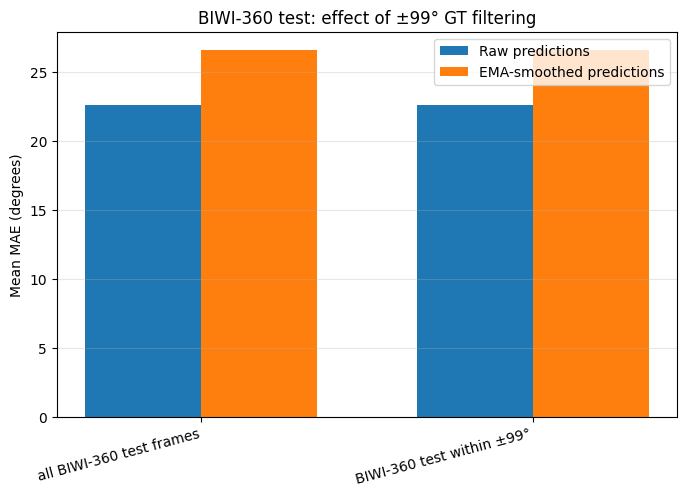

In [134]:
# Appendix B.2: Standard ±99 degree GT angle filter on BIWI-360

biwi_range_mask = (
    (biwi_test_df["yaw"].abs() <= 99) &
    (biwi_test_df["roll"].abs() <= 99) &
    (biwi_test_df["pitch"].abs() <= 99)
)

print("BIWI-360 test frames:", len(biwi_test_df))
print("BIWI-360 test frames within ±99° GT range:", int(biwi_range_mask.sum()))
print("Frames removed by ±99° GT filter:", int((~biwi_range_mask).sum()))

def summarize_biwi_frame_subset(dataframe, subset_name):
    return {
        "subset": subset_name,
        "num_frames": len(dataframe),
        "raw_mae_yaw": dataframe["err_yaw"].mean(),
        "raw_mae_roll": dataframe["err_roll"].mean(),
        "raw_mae_pitch": dataframe["err_pitch"].mean(),
        "raw_mean_mae": dataframe["err_mean"].mean(),
        "smooth_mae_yaw": dataframe["smooth_err_yaw"].mean(),
        "smooth_mae_roll": dataframe["smooth_err_roll"].mean(),
        "smooth_mae_pitch": dataframe["smooth_err_pitch"].mean(),
        "smooth_mean_mae": dataframe["smooth_err_mean"].mean(),
        "extreme_raw_angle_rate_percent": 100.0 * dataframe["has_extreme_raw_angle"].mean(),
    }

biwi_range_filter_summary = pd.DataFrame([
    summarize_biwi_frame_subset(biwi_test_df, "all BIWI-360 test frames"),
    summarize_biwi_frame_subset(biwi_test_df[biwi_range_mask].copy(), "BIWI-360 test within ±99°"),
])

biwi_range_filter_summary["delta_smooth_minus_raw_mae"] = (
    biwi_range_filter_summary["smooth_mean_mae"] -
    biwi_range_filter_summary["raw_mean_mae"]
)

print("\nBIWI-360 test metrics with and without ±99° filtering:")
display(biwi_range_filter_summary)

plt.figure(figsize=(8, 5))
x = np.arange(len(biwi_range_filter_summary))
width = 0.35

plt.bar(
    x - width / 2,
    biwi_range_filter_summary["raw_mean_mae"],
    width,
    label="Raw predictions"
)
plt.bar(
    x + width / 2,
    biwi_range_filter_summary["smooth_mean_mae"],
    width,
    label="EMA-smoothed predictions"
)

plt.xticks(x, biwi_range_filter_summary["subset"], rotation=15, ha="right")
plt.ylabel("Mean MAE (degrees)")
plt.title("BIWI-360 test: effect of ±99° GT filtering")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

## B.2 Standard angle-range filtering

The 6DRepNet evaluation protocol reports results after restricting the test samples to a bounded Euler-angle range, commonly using the interval ±99 degrees. Since BIWI-360 comes from BIWI and its ground-truth angles are already relatively bounded, we check whether this filter changes the BIWI-360 test evaluation.

This check is useful because the AFLW2000-3D sanity check changed slightly after applying the same filter. If BIWI-360 is already fully inside the ±99 degree range, then the poor BIWI-360 performance cannot be explained by evaluating unusually extreme ground-truth angles.

In [135]:
# Appendix B.2: Standard ±99 degree GT angle filter on BIWI-360

biwi_range_mask = (
    (biwi_test_df["yaw"].abs() <= 99) &
    (biwi_test_df["roll"].abs() <= 99) &
    (biwi_test_df["pitch"].abs() <= 99)
)

num_total = len(biwi_test_df)
num_within_range = int(biwi_range_mask.sum())
num_removed = int((~biwi_range_mask).sum())

biwi_range_filter_check = pd.DataFrame([{
    "total_test_frames": num_total,
    "frames_within_±99°": num_within_range,
    "frames_removed_by_filter": num_removed,
    "percentage_removed": 100.0 * num_removed / num_total,
    "raw_mean_mae_all_frames": biwi_test_df["err_mean"].mean(),
    "smooth_mean_mae_all_frames": biwi_test_df["smooth_err_mean"].mean(),
}])

print("BIWI-360 ±99° angle-range filtering check:")
display(biwi_range_filter_check)

if num_removed == 0:
    print(
        "All BIWI-360 test frames are already within the ±99° ground-truth angle range. "
        "Therefore, this standard filtering protocol does not change the BIWI-360 test metrics."
    )

BIWI-360 ±99° angle-range filtering check:


,total_test_frames,frames_within_±99°,frames_removed_by_filter,percentage_removed,raw_mean_mae_all_frames,smooth_mean_mae_all_frames
0,12629,12629,0,0.0,22.596264,26.57982


All BIWI-360 test frames are already within the ±99° ground-truth angle range. Therefore, this standard filtering protocol does not change the BIWI-360 test metrics.


## B.3 Simple baseline comparison

We now compare 6DRepNet360 against simple baselines on the BIWI-360 test split.

The goal is to determine whether the pretrained model is extracting useful pose information under fisheye distortion, or whether its zero-shot predictions are so unstable that a trivial predictor can be competitive.

We evaluate:

- `Zero-pose baseline`: always predicts yaw = roll = pitch = 0.
- `Validation-mean baseline`: predicts the circular mean pose computed from the validation split.
- `Oracle sequence-mean baseline`: predicts the mean ground-truth pose of each test sequence.

The oracle sequence-mean baseline is not deployable because it uses test labels. It is included only as a reference to measure how much sequence-level bias exists in BIWI-360.

Validation circular mean pose:
yaw=8.90, roll=-0.13, pitch=13.09

BIWI-360 test: model vs simple baselines


,method,num_frames,mae_yaw,mae_roll,mae_pitch,mean_mae,rmse_yaw,rmse_roll,rmse_pitch,mean_rmse
0,6DRepNet360 raw,12629,16.992973,21.132519,29.663300,22.596264,25.984591,44.367790,48.104056,39.485479
1,6DRepNet360 + EMA,12629,17.729794,26.357604,35.652063,26.579820,21.890802,46.985118,55.882864,41.586262
2,Zero-pose baseline,12629,24.283217,9.091160,22.660551,18.678309,30.960283,13.217287,27.539979,23.905850
3,Validation-mean baseline,12629,23.565473,9.091692,19.986305,17.547823,30.007969,13.219040,26.660303,23.295771
4,Oracle sequence-mean baseline,12629,22.802194,8.709599,17.602722,16.371505,29.521051,12.598670,22.766385,21.628702


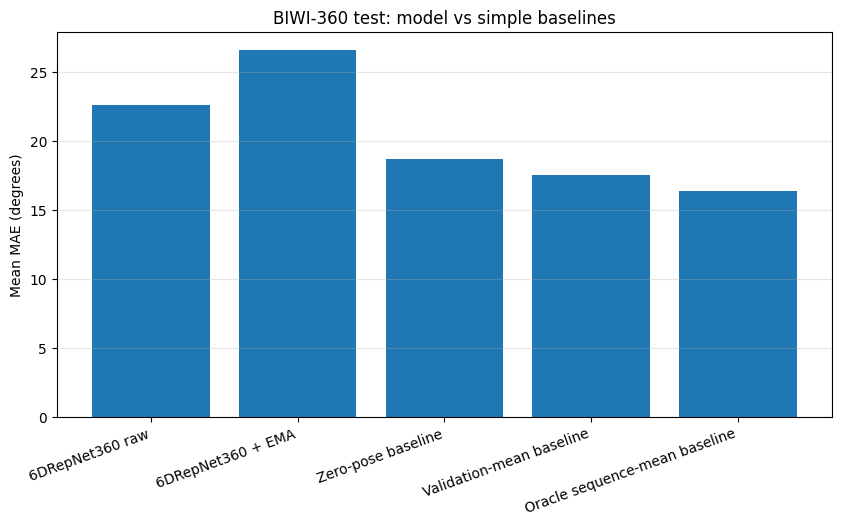

In [136]:
# Appendix B.3: Simple baseline comparison

def circular_mean_deg(values):
    """Circular mean of angles in degrees."""
    values_rad = np.deg2rad(values)
    mean_sin = np.mean(np.sin(values_rad))
    mean_cos = np.mean(np.cos(values_rad))
    return np.rad2deg(np.arctan2(mean_sin, mean_cos))

def evaluate_prediction_columns(dataframe, pred_yaw_col, pred_roll_col, pred_pitch_col, label):
    """Evaluate MAE/RMSE for arbitrary prediction columns."""
    err_yaw = angular_diff_array_deg(dataframe[pred_yaw_col], dataframe["yaw"])
    err_roll = angular_diff_array_deg(dataframe[pred_roll_col], dataframe["roll"])
    err_pitch = angular_diff_array_deg(dataframe[pred_pitch_col], dataframe["pitch"])
    
    return {
        "method": label,
        "num_frames": len(dataframe),
        "mae_yaw": err_yaw.mean(),
        "mae_roll": err_roll.mean(),
        "mae_pitch": err_pitch.mean(),
        "mean_mae": np.mean([err_yaw.mean(), err_roll.mean(), err_pitch.mean()]),
        "rmse_yaw": np.sqrt(np.mean(err_yaw ** 2)),
        "rmse_roll": np.sqrt(np.mean(err_roll ** 2)),
        "rmse_pitch": np.sqrt(np.mean(err_pitch ** 2)),
        "mean_rmse": np.mean([
            np.sqrt(np.mean(err_yaw ** 2)),
            np.sqrt(np.mean(err_roll ** 2)),
            np.sqrt(np.mean(err_pitch ** 2)),
        ]),
    }

baseline_df = biwi_test_df.copy()

# Zero-pose predictor
baseline_df["zero_yaw"] = 0.0
baseline_df["zero_roll"] = 0.0
baseline_df["zero_pitch"] = 0.0

# Validation-mean predictor, estimated only from validation split
validation_df = final_smoothed_df[final_smoothed_df["split"] == "validation"].copy()

mean_yaw_val = circular_mean_deg(validation_df["yaw"])
mean_roll_val = circular_mean_deg(validation_df["roll"])
mean_pitch_val = circular_mean_deg(validation_df["pitch"])

baseline_df["valmean_yaw"] = mean_yaw_val
baseline_df["valmean_roll"] = mean_roll_val
baseline_df["valmean_pitch"] = mean_pitch_val

print("Validation circular mean pose:")
print(f"yaw={mean_yaw_val:.2f}, roll={mean_roll_val:.2f}, pitch={mean_pitch_val:.2f}")

# Oracle sequence mean predictor: not a fair deployable baseline
baseline_df["oracle_seqmean_yaw"] = np.nan
baseline_df["oracle_seqmean_roll"] = np.nan
baseline_df["oracle_seqmean_pitch"] = np.nan

for seq_id, seq_df in baseline_df.groupby("sequence_id"):
    idx = seq_df.index
    
    baseline_df.loc[idx, "oracle_seqmean_yaw"] = circular_mean_deg(seq_df["yaw"])
    baseline_df.loc[idx, "oracle_seqmean_roll"] = circular_mean_deg(seq_df["roll"])
    baseline_df.loc[idx, "oracle_seqmean_pitch"] = circular_mean_deg(seq_df["pitch"])

baseline_results = pd.DataFrame([
    evaluate_prediction_columns(baseline_df, "pred_yaw", "pred_roll", "pred_pitch", "6DRepNet360 raw"),
    evaluate_prediction_columns(baseline_df, "smooth_pred_yaw", "smooth_pred_roll", "smooth_pred_pitch", "6DRepNet360 + EMA"),
    evaluate_prediction_columns(baseline_df, "zero_yaw", "zero_roll", "zero_pitch", "Zero-pose baseline"),
    evaluate_prediction_columns(baseline_df, "valmean_yaw", "valmean_roll", "valmean_pitch", "Validation-mean baseline"),
    evaluate_prediction_columns(baseline_df, "oracle_seqmean_yaw", "oracle_seqmean_roll", "oracle_seqmean_pitch", "Oracle sequence-mean baseline"),
])

print("\nBIWI-360 test: model vs simple baselines")
display(baseline_results)

# Plot model vs baselines
plt.figure(figsize=(10, 5))
plt.bar(
    baseline_results["method"],
    baseline_results["mean_mae"]
)
plt.ylabel("Mean MAE (degrees)")
plt.title("BIWI-360 test: model vs simple baselines")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

### B.3.1 Interpretation of the baseline comparison

The baseline comparison shows that the zero-shot 6DRepNet360 model performs worse than simple constant predictors in frame-level MAE on BIWI-360. This is an important result and should not be hidden.

The zero-pose and validation-mean baselines are strong in this dataset because the BIWI-360 pose distribution is relatively centered, especially for roll. In contrast, the pretrained frame-by-frame model produces large outliers under fisheye distortion, particularly in roll and pitch. These outliers increase the average error enough for constant baselines to outperform the model in frame-level accuracy.

This does not mean that the implementation is broken. The AFLW2000-3D sanity check showed that the same model and angle convention perform much better on non-fisheye images. Instead, this result suggests that zero-shot 6DRepNet360 is not reliable on BIWI-360 without domain adaptation or a fisheye-aware training strategy.

The oracle sequence-mean baseline is not a valid deployable method because it uses test labels from each sequence. It is included only as a reference showing that BIWI-360 contains strong sequence-level pose bias.

## B.4 Sensitivity to extreme prediction outliers

The baseline comparison suggests that the poor frame-level performance is strongly affected by unstable predictions and extreme outliers. We now quantify this effect.

A frame is marked as an extreme raw prediction if at least one predicted angle has absolute value above 150 degrees. This threshold is not based on the ground-truth error; it only detects raw model outputs near the angular boundary.

We analyze frame-level metrics for:

- all test frames;
- frames with at least one extreme raw angle;
- frames without extreme raw angles.

For temporal metrics, a consecutive pair is considered affected by an extreme raw prediction if either the current or previous frame contains an extreme raw angle.

Frame-level sensitivity to extreme raw prediction outliers:


,subset,num_frames,extreme_raw_angle_rate_percent,raw_mean_mae,smooth_mean_mae,delta_smooth_minus_raw_mae,raw_mae_yaw,raw_mae_roll,raw_mae_pitch,smooth_mae_yaw,smooth_mae_roll,smooth_mae_pitch
0,all test frames,12629,5.218149,22.596264,26.579820,3.983556,16.992973,21.132519,29.663300,17.729794,26.357604,35.652063
1,frames with extreme raw angle,659,100.000000,110.339710,54.545887,-55.793823,37.398353,152.188877,141.431899,22.191617,60.313144,81.132900
2,frames without extreme raw angle,11970,0.000000,17.765610,25.040168,7.274558,15.869569,13.917303,23.509958,17.484152,24.488205,33.148148



Temporal sensitivity to extreme raw prediction outliers:


,subset,num_raw_pairs,num_smooth_pairs,raw_mean_jitter,smooth_mean_jitter,jitter_reduction_percent,raw_temporal_motion_error,smooth_temporal_motion_error,temporal_error_reduction_percent
0,all test consecutive pairs,12585,12565,44.273643,4.092073,90.757316,44.272610,4.594871,89.621414
1,pairs affected by extreme raw angle,1094,1094,152.739769,10.498727,93.126396,152.895201,11.192034,92.679931
2,pairs not affected by extreme raw angle,11491,11471,33.947131,3.481064,89.745631,33.931202,3.965693,88.312547


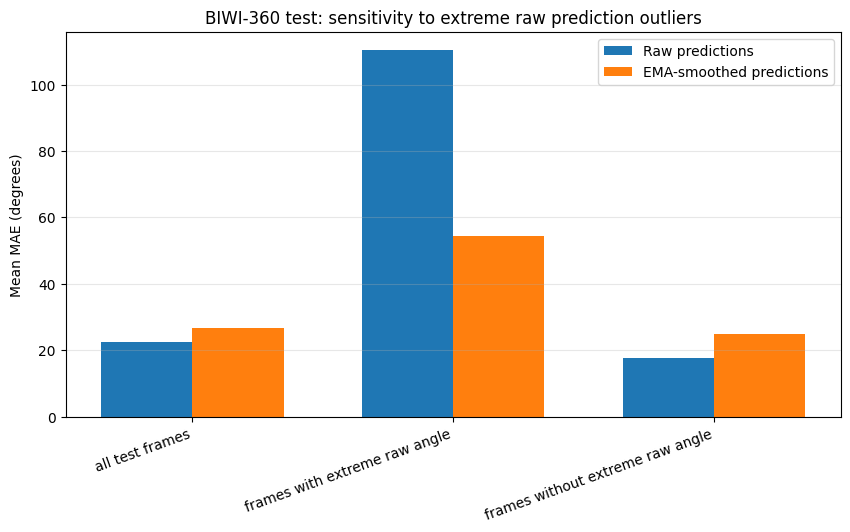

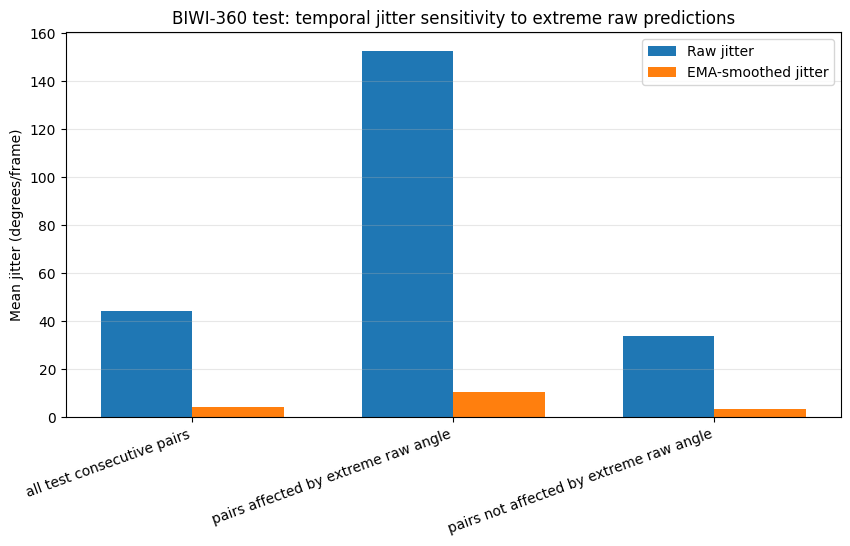

In [137]:
# Appendix B.4: Sensitivity analysis for extreme raw prediction outliers

outlier_analysis_df = biwi_test_df.copy()

def summarize_frame_outlier_subset(dataframe, subset_name):
    return {
        "subset": subset_name,
        "num_frames": len(dataframe),
        "extreme_raw_angle_rate_percent": (
            100.0 * dataframe["has_extreme_raw_angle"].mean()
            if len(dataframe) > 0 else np.nan
        ),
        "raw_mean_mae": dataframe["err_mean"].mean(),
        "smooth_mean_mae": dataframe["smooth_err_mean"].mean(),
        "delta_smooth_minus_raw_mae": dataframe["smooth_err_mean"].mean() - dataframe["err_mean"].mean(),
        "raw_mae_yaw": dataframe["err_yaw"].mean(),
        "raw_mae_roll": dataframe["err_roll"].mean(),
        "raw_mae_pitch": dataframe["err_pitch"].mean(),
        "smooth_mae_yaw": dataframe["smooth_err_yaw"].mean(),
        "smooth_mae_roll": dataframe["smooth_err_roll"].mean(),
        "smooth_mae_pitch": dataframe["smooth_err_pitch"].mean(),
    }

frame_outlier_sensitivity = pd.DataFrame([
    summarize_frame_outlier_subset(outlier_analysis_df, "all test frames"),
    summarize_frame_outlier_subset(
        outlier_analysis_df[outlier_analysis_df["has_extreme_raw_angle"]],
        "frames with extreme raw angle"
    ),
    summarize_frame_outlier_subset(
        outlier_analysis_df[~outlier_analysis_df["has_extreme_raw_angle"]],
        "frames without extreme raw angle"
    ),
])

print("Frame-level sensitivity to extreme raw prediction outliers:")
display(frame_outlier_sensitivity)

# Temporal sensitivity
frame_flags = outlier_analysis_df[
    ["sequence_id", "frame_id", "has_extreme_raw_angle"]
].copy()

raw_temporal_test = raw_temporal_df[raw_temporal_df["split"] == "test"].copy()
smooth_temporal_test = final_smoothed_temporal_df[
    final_smoothed_temporal_df["split"] == "test"
].copy()

def attach_pair_outlier_flags(temporal_df):
    temp = temporal_df.copy()
    
    temp = temp.merge(
        frame_flags.rename(columns={"has_extreme_raw_angle": "current_extreme_raw_angle"}),
        on=["sequence_id", "frame_id"],
        how="left"
    )
    
    temp = temp.merge(
        frame_flags.rename(columns={
            "frame_id": "prev_frame_id_eval",
            "has_extreme_raw_angle": "previous_extreme_raw_angle"
        }),
        on=["sequence_id", "prev_frame_id_eval"],
        how="left"
    )
    
    temp["current_extreme_raw_angle"] = temp["current_extreme_raw_angle"].fillna(False)
    temp["previous_extreme_raw_angle"] = temp["previous_extreme_raw_angle"].fillna(False)
    
    temp["pair_has_extreme_raw_angle"] = (
        temp["current_extreme_raw_angle"] |
        temp["previous_extreme_raw_angle"]
    )
    
    return temp

raw_temporal_test_flags = attach_pair_outlier_flags(raw_temporal_test)
smooth_temporal_test_flags = attach_pair_outlier_flags(smooth_temporal_test)

def summarize_temporal_outlier_subset(raw_df, smooth_df, mask_function, subset_name):
    raw_subset = raw_df[mask_function(raw_df)]
    smooth_subset = smooth_df[mask_function(smooth_df)]
    
    raw_jitter = raw_subset["pred_jitter_magnitude"].mean()
    smooth_jitter = smooth_subset["smooth_pred_jitter_magnitude"].mean()
    
    raw_temporal_error = raw_subset["temporal_motion_error_magnitude"].mean()
    smooth_temporal_error = smooth_subset["smooth_pred_temporal_motion_error_magnitude"].mean()
    
    return {
        "subset": subset_name,
        "num_raw_pairs": len(raw_subset),
        "num_smooth_pairs": len(smooth_subset),
        "raw_mean_jitter": raw_jitter,
        "smooth_mean_jitter": smooth_jitter,
        "jitter_reduction_percent": 100.0 * (raw_jitter - smooth_jitter) / raw_jitter,
        "raw_temporal_motion_error": raw_temporal_error,
        "smooth_temporal_motion_error": smooth_temporal_error,
        "temporal_error_reduction_percent": (
            100.0 * (raw_temporal_error - smooth_temporal_error) / raw_temporal_error
        ),
    }

temporal_outlier_sensitivity = pd.DataFrame([
    summarize_temporal_outlier_subset(
        raw_temporal_test_flags,
        smooth_temporal_test_flags,
        lambda df: pd.Series(True, index=df.index),
        "all test consecutive pairs"
    ),
    summarize_temporal_outlier_subset(
        raw_temporal_test_flags,
        smooth_temporal_test_flags,
        lambda df: df["pair_has_extreme_raw_angle"],
        "pairs affected by extreme raw angle"
    ),
    summarize_temporal_outlier_subset(
        raw_temporal_test_flags,
        smooth_temporal_test_flags,
        lambda df: ~df["pair_has_extreme_raw_angle"],
        "pairs not affected by extreme raw angle"
    ),
])

print("\nTemporal sensitivity to extreme raw prediction outliers:")
display(temporal_outlier_sensitivity)

# Plot frame-level sensitivity
plt.figure(figsize=(10, 5))
x = np.arange(len(frame_outlier_sensitivity))
width = 0.35

plt.bar(
    x - width / 2,
    frame_outlier_sensitivity["raw_mean_mae"],
    width,
    label="Raw predictions"
)
plt.bar(
    x + width / 2,
    frame_outlier_sensitivity["smooth_mean_mae"],
    width,
    label="EMA-smoothed predictions"
)

plt.xticks(x, frame_outlier_sensitivity["subset"], rotation=20, ha="right")
plt.ylabel("Mean MAE (degrees)")
plt.title("BIWI-360 test: sensitivity to extreme raw prediction outliers")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

# Plot temporal sensitivity
plt.figure(figsize=(10, 5))
x = np.arange(len(temporal_outlier_sensitivity))

plt.bar(
    x - width / 2,
    temporal_outlier_sensitivity["raw_mean_jitter"],
    width,
    label="Raw jitter"
)
plt.bar(
    x + width / 2,
    temporal_outlier_sensitivity["smooth_mean_jitter"],
    width,
    label="EMA-smoothed jitter"
)

plt.xticks(x, temporal_outlier_sensitivity["subset"], rotation=20, ha="right")
plt.ylabel("Mean jitter (degrees/frame)")
plt.title("BIWI-360 test: temporal jitter sensitivity to extreme raw predictions")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

### B.4.1 Interpretation of outlier sensitivity

The outlier sensitivity analysis shows that extreme raw predictions have a very large impact on the BIWI-360 results.

Only a small fraction of test frames contain at least one raw predicted angle above 150 degrees in absolute value. However, these frames have a raw mean MAE of approximately 110.3 degrees, compared with approximately 17.8 degrees for frames without extreme raw predictions.

EMA smoothing has opposite effects depending on the subset. For frames with extreme raw predictions, smoothing reduces the mean MAE from approximately 110.3 to 54.5 degrees. This shows that temporal smoothing can partially absorb isolated extreme predictions. However, for frames without extreme raw predictions, smoothing increases the mean MAE from approximately 17.8 to 25.0 degrees, which is consistent with temporal lag and loss of instantaneous accuracy.

The temporal metrics show the same pattern. Consecutive pairs affected by extreme raw predictions have a raw mean jitter of approximately 152.7 degrees per frame, while pairs not affected by extreme predictions still have a raw mean jitter of approximately 33.9 degrees per frame. Therefore, extreme outliers explain the worst temporal failures, but they are not the only source of instability.

Overall, EMA is effective as a simple jitter-reduction method, but it is not robust enough to fully handle large isolated outliers. A better temporal post-processing method should combine smoothing with outlier detection or confidence-based rejection.

## B.5 Where does the model still add value?

The previous baseline comparison showed that simple constant predictors outperform zero-shot 6DRepNet360 in overall mean MAE on BIWI-360. However, this global result hides important axis-specific behavior.

In particular, yaw has the largest variation in the BIWI-360 labels, and it is also the angle where the model performs best relative to the trivial baselines. This suggests that the model still extracts useful pose information, especially for horizontal head orientation, even though roll and pitch are strongly affected by fisheye distortion and extreme outliers.

This section analyzes where the model performs better than the baselines. These results do not replace the official metrics, but they help provide a more balanced interpretation of the model behavior.

Axis-specific MAE comparison on all BIWI-360 test frames:


,subset,method,mae_yaw,mae_roll,mae_pitch,mean_mae
0,all test frames,6DRepNet360 raw,16.992973,21.132519,29.663300,22.596264
1,all test frames,6DRepNet360 + EMA,17.729794,26.357604,35.652063,26.579820
2,all test frames,Zero-pose baseline,24.283217,9.091160,22.660551,18.678309
3,all test frames,Validation-mean baseline,23.565473,9.091692,19.986305,17.547823
4,all test frames,Oracle sequence-mean baseline,22.802194,8.709599,17.602722,16.371505



Best non-oracle method by metric:


,metric,best_non_oracle_method,best_value
0,mae_yaw,6DRepNet360 raw,16.992973
1,mae_roll,Zero-pose baseline,9.091160
2,mae_pitch,Validation-mean baseline,19.986305
3,mean_mae,Validation-mean baseline,17.547823



Raw model vs baselines by rho level and angle:


,rho_level,angle,num_frames,raw_model_mae,ema_model_mae,zero_baseline_mae,validation_mean_baseline_mae,raw_minus_valmean,raw_improvement_over_valmean_percent
0,low rho,yaw,4272,15.354798,17.674597,24.120549,23.379254,-8.024456,34.322976
1,low rho,roll,4272,16.906745,25.699394,9.163182,9.160974,7.745771,-84.551828
2,low rho,pitch,4272,24.298531,35.115667,22.590313,20.412196,3.886335,-19.039279
3,medium rho,yaw,4158,15.701070,17.760235,24.341731,23.672526,-7.971456,33.673871
4,medium rho,roll,4158,18.787271,27.405143,9.014715,9.015448,9.771823,-108.389771
5,medium rho,pitch,4158,27.409839,36.242938,22.993933,19.693252,7.716587,-39.183916
6,high rho,yaw,4199,19.938916,17.755809,24.390772,23.648923,-3.710007,15.687849
7,high rho,roll,4199,27.754106,25.989944,9.093584,9.096704,18.657403,-205.100700
8,high rho,pitch,4199,37.352794,35.612680,22.401883,19.843201,17.509593,-88.239759



Axis-specific MAE comparison after excluding frames with extreme raw predictions:


,subset,method,mae_yaw,mae_roll,mae_pitch,mean_mae
0,frames without extreme raw angle,6DRepNet360 raw,15.869569,13.917303,23.509958,17.765610
1,frames without extreme raw angle,6DRepNet360 + EMA,17.484152,24.488205,33.148148,25.040168
2,frames without extreme raw angle,Zero-pose baseline,24.117142,8.986377,21.707023,18.270180
3,frames without extreme raw angle,Validation-mean baseline,23.321890,8.985456,19.380124,17.229156
4,frames without extreme raw angle,Oracle sequence-mean baseline,22.591668,8.613486,17.083405,16.096187


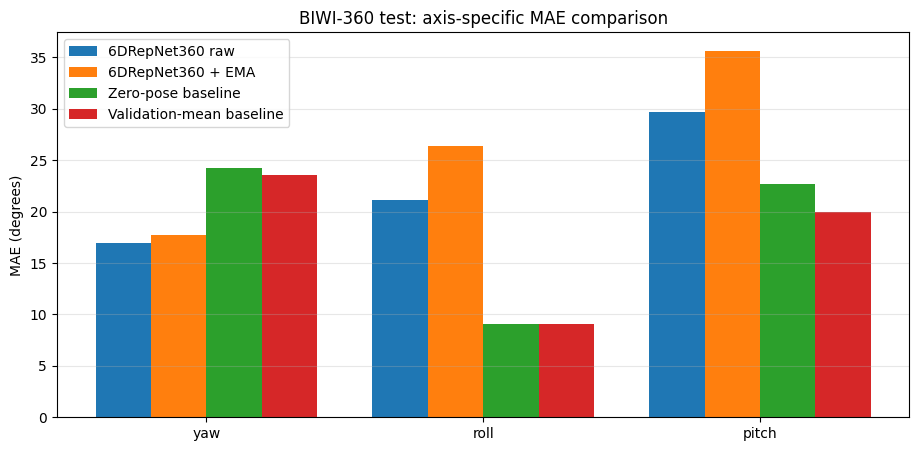

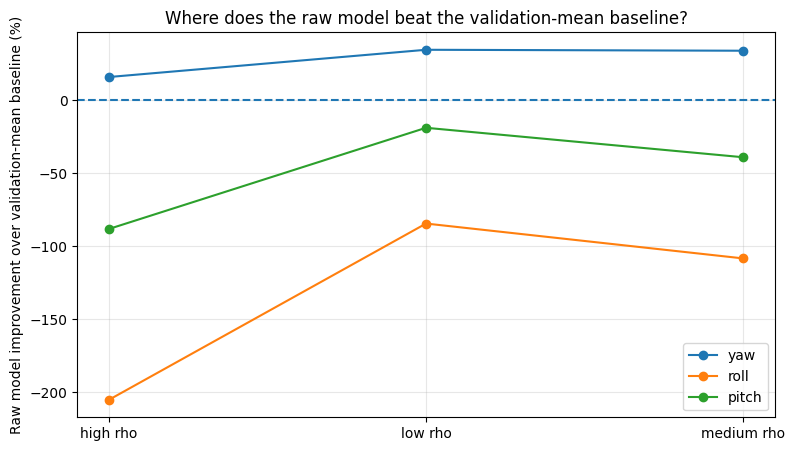

In [138]:
# Appendix B.5: Where does the model still add value?

analysis_df = baseline_df.copy()

# Make sure rho_level exists in this table
if "rho_level" not in analysis_df.columns:
    analysis_df["rho_level"] = pd.cut(
        analysis_df["rho"],
        bins=[0.0, 0.8 / 3, 2 * 0.8 / 3, 0.8 + 1e-6],
        labels=["low rho", "medium rho", "high rho"],
        include_lowest=True
    )

methods = {
    "6DRepNet360 raw": ("pred_yaw", "pred_roll", "pred_pitch"),
    "6DRepNet360 + EMA": ("smooth_pred_yaw", "smooth_pred_roll", "smooth_pred_pitch"),
    "Zero-pose baseline": ("zero_yaw", "zero_roll", "zero_pitch"),
    "Validation-mean baseline": ("valmean_yaw", "valmean_roll", "valmean_pitch"),
    "Oracle sequence-mean baseline": (
        "oracle_seqmean_yaw",
        "oracle_seqmean_roll",
        "oracle_seqmean_pitch"
    ),
}

def axis_mae_table(dataframe, label):
    rows = []
    
    for method_name, (yaw_col, roll_col, pitch_col) in methods.items():
        rows.append({
            "subset": label,
            "method": method_name,
            "mae_yaw": angular_diff_array_deg(dataframe[yaw_col], dataframe["yaw"]).mean(),
            "mae_roll": angular_diff_array_deg(dataframe[roll_col], dataframe["roll"]).mean(),
            "mae_pitch": angular_diff_array_deg(dataframe[pitch_col], dataframe["pitch"]).mean(),
        })
    
    out = pd.DataFrame(rows)
    out["mean_mae"] = out[["mae_yaw", "mae_roll", "mae_pitch"]].mean(axis=1)
    return out

overall_axis_comparison = axis_mae_table(analysis_df, "all test frames")

print("Axis-specific MAE comparison on all BIWI-360 test frames:")
display(overall_axis_comparison)

# Identify best non-oracle method per axis
non_oracle_axis_comparison = overall_axis_comparison[
    overall_axis_comparison["method"] != "Oracle sequence-mean baseline"
].copy()

best_non_oracle_by_axis = []

for axis_col in ["mae_yaw", "mae_roll", "mae_pitch", "mean_mae"]:
    best_row = non_oracle_axis_comparison.sort_values(axis_col).iloc[0]
    best_non_oracle_by_axis.append({
        "metric": axis_col,
        "best_non_oracle_method": best_row["method"],
        "best_value": best_row[axis_col],
    })

best_non_oracle_by_axis = pd.DataFrame(best_non_oracle_by_axis)

print("\nBest non-oracle method by metric:")
display(best_non_oracle_by_axis)

# Compare raw model vs validation-mean baseline by rho level and angle
rho_axis_rows = []

for rho_level, group in analysis_df.groupby("rho_level", observed=False):
    for angle in ["yaw", "roll", "pitch"]:
        raw_error = angular_diff_array_deg(
            group[f"pred_{angle}"],
            group[angle]
        ).mean()
        
        valmean_error = angular_diff_array_deg(
            group[f"valmean_{angle}"],
            group[angle]
        ).mean()
        
        zero_error = angular_diff_array_deg(
            group[f"zero_{angle}"],
            group[angle]
        ).mean()
        
        smooth_error = angular_diff_array_deg(
            group[f"smooth_pred_{angle}"],
            group[angle]
        ).mean()
        
        rho_axis_rows.append({
            "rho_level": rho_level,
            "angle": angle,
            "num_frames": len(group),
            "raw_model_mae": raw_error,
            "ema_model_mae": smooth_error,
            "zero_baseline_mae": zero_error,
            "validation_mean_baseline_mae": valmean_error,
            "raw_minus_valmean": raw_error - valmean_error,
            "raw_improvement_over_valmean_percent": (
                100.0 * (valmean_error - raw_error) / valmean_error
            ),
        })

rho_axis_comparison = pd.DataFrame(rho_axis_rows)

print("\nRaw model vs baselines by rho level and angle:")
display(rho_axis_comparison)

# Same comparison but excluding extreme raw predictions
non_extreme_df = analysis_df[~analysis_df["has_extreme_raw_angle"]].copy()
non_extreme_axis_comparison = axis_mae_table(
    non_extreme_df,
    "frames without extreme raw angle"
)

print("\nAxis-specific MAE comparison after excluding frames with extreme raw predictions:")
display(non_extreme_axis_comparison)

# Plot axis-specific comparison for the most relevant non-oracle methods
plot_methods = [
    "6DRepNet360 raw",
    "6DRepNet360 + EMA",
    "Zero-pose baseline",
    "Validation-mean baseline",
]

plot_df = overall_axis_comparison[
    overall_axis_comparison["method"].isin(plot_methods)
].copy()

x = np.arange(3)
width = 0.2
axis_labels = ["yaw", "roll", "pitch"]

plt.figure(figsize=(11, 5))

for i, method_name in enumerate(plot_methods):
    row = plot_df[plot_df["method"] == method_name].iloc[0]
    values = [row["mae_yaw"], row["mae_roll"], row["mae_pitch"]]
    
    plt.bar(
        x + (i - 1.5) * width,
        values,
        width,
        label=method_name
    )

plt.xticks(x, axis_labels)
plt.ylabel("MAE (degrees)")
plt.title("BIWI-360 test: axis-specific MAE comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

# Plot raw improvement over validation-mean baseline by rho level and angle
pivot_improvement = rho_axis_comparison.pivot(
    index="rho_level",
    columns="angle",
    values="raw_improvement_over_valmean_percent"
)

plt.figure(figsize=(9, 5))
for angle in ["yaw", "roll", "pitch"]:
    plt.plot(
        pivot_improvement.index.astype(str),
        pivot_improvement[angle],
        marker="o",
        label=angle
    )

plt.axhline(0, linestyle="--")
plt.ylabel("Raw model improvement over validation-mean baseline (%)")
plt.title("Where does the raw model beat the validation-mean baseline?")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### B.5.1 Interpretation: axis-specific value of the model

The simple baseline comparison is severe when looking only at overall mean MAE, but the axis-specific analysis provides a more nuanced interpretation.

The raw 6DRepNet360 model is the best non-oracle method for yaw. This is important because yaw is the angle with the largest variation in the BIWI-360 labels. The zero-pose and validation-mean baselines are competitive mainly because roll and pitch are relatively centered in this dataset, and a constant prediction can obtain low error on those axes.

Across all `rho` levels, the raw model improves yaw MAE over the validation-mean baseline. The improvement is strongest for low and medium `rho`, where the raw model reduces yaw error by more than 30% relative to the validation-mean baseline. Even for high `rho`, where fisheye distortion is stronger, the raw model still improves yaw error by approximately 15%.

However, this useful yaw information is offset by much worse roll and pitch errors, especially when fisheye distortion is strong. Large roll and pitch outliers dominate the overall mean MAE and explain why the validation-mean baseline wins in the global metric.

After excluding frames with extreme raw predictions, the raw model becomes much closer to the validation-mean baseline in overall mean MAE and outperforms the zero-pose baseline. This suggests that the model is not entirely uninformative under BIWI-360, but its predictions are not robust enough without outlier handling or domain adaptation.

## B.6 Appendix B conclusion

The BIWI-360 sensitivity analysis provides a more detailed explanation of the poor zero-shot performance.

First, the error increases with the fisheye radial parameter `rho`. Raw mean MAE rises from approximately 18.9 degrees for low-`rho` frames to approximately 28.3 degrees for high-`rho` frames. This supports the interpretation that stronger fisheye deformation makes zero-shot head pose estimation more difficult.

Second, the standard ±99 degree angle-range filter does not change the BIWI-360 test set, because all test frames are already inside this range. Therefore, the poor BIWI-360 result cannot be explained by evaluating unusually extreme ground-truth head poses.

Third, simple constant baselines outperform zero-shot 6DRepNet360 in overall mean MAE. However, this result is axis-dependent. The raw model is clearly better than the baselines for yaw, which is the most variable pose angle in the dataset. The global failure is mainly caused by roll and pitch, where the model produces large fisheye-induced outliers and the constant baselines benefit from the centered distribution of those angles.

Fourth, extreme raw predictions are a major source of error. Frames with at least one raw predicted angle above 150 degrees have much larger error than the rest of the test set. When these frames are excluded, the raw model becomes much closer to the validation-mean baseline in overall MAE and outperforms the zero-pose baseline.

Finally, EMA smoothing strongly reduces temporal jitter, including in pairs affected by extreme predictions. However, EMA also worsens frame-level accuracy on non-outlier frames, because it introduces lag and can propagate the effect of bad predictions over subsequent frames.

Overall, the model is not completely uninformative on BIWI-360: it captures useful yaw information. However, it is not robust enough as a zero-shot frame-by-frame estimator under fisheye distortion. The most promising next step is not simply stronger smoothing, but robust temporal post-processing or domain adaptation. Future work should consider outlier rejection, median filtering, clipping of unrealistic frame-to-frame jumps, fisheye-aware fine-tuning, or explicit use of the distortion parameters.

# Appendix C. Robust temporal filtering pilot

The previous analysis showed that simple EMA smoothing strongly reduces jitter, but it also increases frame-level MAE on non-outlier frames. This happens because EMA smooths every prediction equally and is not robust to isolated extreme outliers.

In this appendix, we test more robust temporal post-processing strategies. The goal is to preserve useful pose information, especially yaw, while reducing roll/pitch outliers and temporal jitter.

We evaluate both causal and offline filters:

- causal filters use only the current and previous frames;
- centered filters use both past and future frames, so they are suitable only for offline video post-processing.

All hyperparameters are selected using the validation split only. The test split is used only for the final evaluation of the selected filter.

In [139]:
# Appendix C.1: Robust temporal filtering utilities

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def wrap_angle_deg(angle):
    """Wrap angle values to [-180, 180)."""
    return (angle + 180) % 360 - 180

def unwrap_angle_sequence_deg(values):
    """Unwrap a sequence of angles in degrees to avoid artificial ±180 jumps."""
    return np.rad2deg(np.unwrap(np.deg2rad(values)))

def rolling_median_1d(values, window_size, centered):
    """Rolling median filter for a 1D sequence."""
    return (
        pd.Series(values)
        .rolling(window=window_size, center=centered, min_periods=1)
        .median()
        .values
    )

def rolling_mean_1d(values, window_size, centered):
    """Rolling mean filter for a 1D sequence."""
    return (
        pd.Series(values)
        .rolling(window=window_size, center=centered, min_periods=1)
        .mean()
        .values
    )

def ema_1d(values, alpha):
    """Standard exponential moving average."""
    smoothed = np.zeros_like(values, dtype=np.float32)
    smoothed[0] = values[0]
    
    for i in range(1, len(values)):
        smoothed[i] = alpha * values[i] + (1.0 - alpha) * smoothed[i - 1]
    
    return smoothed

def ema_with_jump_clipping_1d(values, alpha, max_jump_deg):
    """
    Causal EMA with jump clipping.
    Before updating the EMA, the raw value is clipped so that it cannot move
    more than max_jump_deg away from the previous smoothed value.
    """
    smoothed = np.zeros_like(values, dtype=np.float32)
    smoothed[0] = values[0]
    
    for i in range(1, len(values)):
        delta = values[i] - smoothed[i - 1]
        clipped_delta = np.clip(delta, -max_jump_deg, max_jump_deg)
        clipped_target = smoothed[i - 1] + clipped_delta
        smoothed[i] = alpha * clipped_target + (1.0 - alpha) * smoothed[i - 1]
    
    return smoothed

def apply_temporal_filter_by_sequence(dataframe, method, params, output_prefix="robust_pred"):
    """
    Apply a temporal filter independently to each sequence and each predicted angle.
    The filter uses only model predictions, never ground truth.
    """
    out = dataframe.sort_values(["sequence_id", "frame_id"]).copy()
    
    for angle in ["yaw", "roll", "pitch"]:
        out[f"{output_prefix}_{angle}"] = np.nan
    
    for sequence_id, seq_df in out.groupby("sequence_id"):
        idx = seq_df.index
        
        for angle in ["yaw", "roll", "pitch"]:
            raw_values = seq_df[f"pred_{angle}"].values.astype(float)
            unwrapped = unwrap_angle_sequence_deg(raw_values)
            
            if method == "rolling_median":
                filtered = rolling_median_1d(
                    unwrapped,
                    window_size=params["window_size"],
                    centered=params["centered"]
                )
            
            elif method == "rolling_mean":
                filtered = rolling_mean_1d(
                    unwrapped,
                    window_size=params["window_size"],
                    centered=params["centered"]
                )
            
            elif method == "median_then_ema":
                median_values = rolling_median_1d(
                    unwrapped,
                    window_size=params["window_size"],
                    centered=params["centered"]
                )
                filtered = ema_1d(
                    median_values,
                    alpha=params["alpha"]
                )
            
            elif method == "ema_clip":
                filtered = ema_with_jump_clipping_1d(
                    unwrapped,
                    alpha=params["alpha"],
                    max_jump_deg=params["max_jump_deg"]
                )
            
            else:
                raise ValueError(f"Unknown method: {method}")
            
            out.loc[idx, f"{output_prefix}_{angle}"] = wrap_angle_deg(filtered)
    
    return out

def add_frame_errors_for_prefix(dataframe, pred_prefix, error_prefix):
    """Add frame-level angular errors for prediction columns with a given prefix."""
    out = dataframe.copy()
    
    for angle in ["yaw", "roll", "pitch"]:
        out[f"{error_prefix}_{angle}"] = angular_diff_array_deg(
            out[f"{pred_prefix}_{angle}"],
            out[angle]
        )
    
    out[f"{error_prefix}_mean"] = out[
        [f"{error_prefix}_yaw", f"{error_prefix}_roll", f"{error_prefix}_pitch"]
    ].mean(axis=1)
    
    return out

def compute_temporal_metrics_for_prefix(dataframe, pred_prefix):
    """
    Compute temporal metrics for prediction columns with a given prefix.
    Expects columns like '{pred_prefix}_yaw', '{pred_prefix}_roll', '{pred_prefix}_pitch'.
    """
    temp = dataframe.sort_values(["sequence_id", "frame_id"]).copy()
    
    temp["prev_frame_id_eval"] = temp.groupby("sequence_id")["frame_id"].shift(1)
    temp["frame_gap_eval"] = temp["frame_id"] - temp["prev_frame_id_eval"]
    
    for angle in ["yaw", "roll", "pitch"]:
        temp[f"prev_{angle}"] = temp.groupby("sequence_id")[angle].shift(1)
        temp[f"prev_{pred_prefix}_{angle}"] = temp.groupby("sequence_id")[f"{pred_prefix}_{angle}"].shift(1)
    
    temp = temp[temp["frame_gap_eval"] == 1].copy().reset_index(drop=True)
    
    for angle in ["yaw", "roll", "pitch"]:
        temp[f"gt_delta_{angle}"] = signed_circular_diff_deg(
            temp[angle],
            temp[f"prev_{angle}"]
        )
        
        temp[f"{pred_prefix}_delta_{angle}"] = signed_circular_diff_deg(
            temp[f"{pred_prefix}_{angle}"],
            temp[f"prev_{pred_prefix}_{angle}"]
        )
        
        temp[f"{pred_prefix}_jitter_{angle}"] = np.abs(temp[f"{pred_prefix}_delta_{angle}"])
        temp[f"{pred_prefix}_temporal_error_{angle}"] = np.abs(
            temp[f"{pred_prefix}_delta_{angle}"] - temp[f"gt_delta_{angle}"]
        )
    
    temp = temp.dropna().reset_index(drop=True)
    
    temp["gt_motion_magnitude"] = np.sqrt(
        temp["gt_delta_yaw"] ** 2 +
        temp["gt_delta_roll"] ** 2 +
        temp["gt_delta_pitch"] ** 2
    )
    
    temp[f"{pred_prefix}_jitter_magnitude"] = np.sqrt(
        temp[f"{pred_prefix}_delta_yaw"] ** 2 +
        temp[f"{pred_prefix}_delta_roll"] ** 2 +
        temp[f"{pred_prefix}_delta_pitch"] ** 2
    )
    
    temp[f"{pred_prefix}_temporal_motion_error_magnitude"] = np.sqrt(
        temp[f"{pred_prefix}_temporal_error_yaw"] ** 2 +
        temp[f"{pred_prefix}_temporal_error_roll"] ** 2 +
        temp[f"{pred_prefix}_temporal_error_pitch"] ** 2
    )
    
    return temp

def summarize_candidate(candidate_df, candidate_temporal_df, pred_prefix, error_prefix, candidate_name, split_name):
    frame_subset = candidate_df[candidate_df["split"] == split_name]
    temporal_subset = candidate_temporal_df[candidate_temporal_df["split"] == split_name]
    
    return {
        "candidate": candidate_name,
        "split": split_name,
        "num_frames": len(frame_subset),
        "num_pairs": len(temporal_subset),
        "mae_yaw": frame_subset[f"{error_prefix}_yaw"].mean(),
        "mae_roll": frame_subset[f"{error_prefix}_roll"].mean(),
        "mae_pitch": frame_subset[f"{error_prefix}_pitch"].mean(),
        "mean_mae": frame_subset[f"{error_prefix}_mean"].mean(),
        "mean_jitter": temporal_subset[f"{pred_prefix}_jitter_magnitude"].mean(),
        "mean_temporal_motion_error": temporal_subset[f"{pred_prefix}_temporal_motion_error_magnitude"].mean(),
    }

print("Robust temporal filtering utilities loaded.")

Robust temporal filtering utilities loaded.


In [140]:
# Appendix C.2: Validation grid search over robust temporal filters

# Base dataframe for robust-filter experiments
robust_base_df = final_smoothed_df.copy()

candidate_configs = []

# Rolling median filters
for window_size in [3, 5, 7, 11]:
    candidate_configs.append({
        "method": "rolling_median",
        "params": {"window_size": window_size, "centered": False},
        "name": f"causal median w={window_size}"
    })
    candidate_configs.append({
        "method": "rolling_median",
        "params": {"window_size": window_size, "centered": True},
        "name": f"centered median w={window_size}"
    })

# Rolling mean filters
for window_size in [3, 5, 7, 11]:
    candidate_configs.append({
        "method": "rolling_mean",
        "params": {"window_size": window_size, "centered": False},
        "name": f"causal mean w={window_size}"
    })
    candidate_configs.append({
        "method": "rolling_mean",
        "params": {"window_size": window_size, "centered": True},
        "name": f"centered mean w={window_size}"
    })

# Median followed by EMA
for window_size in [3, 5, 7]:
    for alpha in [0.10, 0.20, 0.30, 0.50]:
        candidate_configs.append({
            "method": "median_then_ema",
            "params": {"window_size": window_size, "centered": True, "alpha": alpha},
            "name": f"centered median w={window_size} + EMA alpha={alpha}"
        })

# EMA with jump clipping
for alpha in [0.10, 0.20, 0.30, 0.50, 0.70]:
    for max_jump_deg in [5, 10, 20, 40]:
        candidate_configs.append({
            "method": "ema_clip",
            "params": {"alpha": alpha, "max_jump_deg": max_jump_deg},
            "name": f"EMA clip alpha={alpha}, jump={max_jump_deg}"
        })

print("Number of candidate filters:", len(candidate_configs))

search_rows = []

# Raw baseline in the same table
raw_candidate_df = robust_base_df.copy()
raw_candidate_df = add_frame_errors_for_prefix(
    raw_candidate_df,
    pred_prefix="pred",
    error_prefix="raw_search_err"
)
raw_candidate_temporal_df = compute_temporal_metrics_for_prefix(
    raw_candidate_df,
    pred_prefix="pred"
)

search_rows.append(
    summarize_candidate(
        raw_candidate_df,
        raw_candidate_temporal_df,
        pred_prefix="pred",
        error_prefix="raw_search_err",
        candidate_name="raw predictions",
        split_name="validation"
    )
)
search_rows.append(
    summarize_candidate(
        raw_candidate_df,
        raw_candidate_temporal_df,
        pred_prefix="pred",
        error_prefix="raw_search_err",
        candidate_name="raw predictions",
        split_name="test"
    )
)

# Original EMA selected earlier
ema_candidate_df = robust_base_df.copy()
ema_candidate_df = add_frame_errors_for_prefix(
    ema_candidate_df,
    pred_prefix="smooth_pred",
    error_prefix="ema_search_err"
)
ema_candidate_temporal_df = compute_temporal_metrics_for_prefix(
    ema_candidate_df,
    pred_prefix="smooth_pred"
)

search_rows.append(
    summarize_candidate(
        ema_candidate_df,
        ema_candidate_temporal_df,
        pred_prefix="smooth_pred",
        error_prefix="ema_search_err",
        candidate_name=f"original EMA alpha={best_alpha}",
        split_name="validation"
    )
)
search_rows.append(
    summarize_candidate(
        ema_candidate_df,
        ema_candidate_temporal_df,
        pred_prefix="smooth_pred",
        error_prefix="ema_search_err",
        candidate_name=f"original EMA alpha={best_alpha}",
        split_name="test"
    )
)

# Robust candidates
for config in candidate_configs:
    candidate_df = apply_temporal_filter_by_sequence(
        robust_base_df,
        method=config["method"],
        params=config["params"],
        output_prefix="robust_pred"
    )
    
    candidate_df = add_frame_errors_for_prefix(
        candidate_df,
        pred_prefix="robust_pred",
        error_prefix="robust_err"
    )
    
    candidate_temporal_df = compute_temporal_metrics_for_prefix(
        candidate_df,
        pred_prefix="robust_pred"
    )
    
    for split_name in ["validation", "test"]:
        search_rows.append(
            summarize_candidate(
                candidate_df,
                candidate_temporal_df,
                pred_prefix="robust_pred",
                error_prefix="robust_err",
                candidate_name=config["name"],
                split_name=split_name
            )
        )

robust_search_results = pd.DataFrame(search_rows)

# Balanced validation score:
# equal weight to frame-level MAE and temporal motion error,
# both normalized by the raw validation values.
raw_validation_row = robust_search_results[
    (robust_search_results["split"] == "validation") &
    (robust_search_results["candidate"] == "raw predictions")
].iloc[0]

raw_val_mae = raw_validation_row["mean_mae"]
raw_val_temporal_error = raw_validation_row["mean_temporal_motion_error"]

robust_search_results["balanced_score"] = (
    robust_search_results["mean_mae"] / raw_val_mae +
    robust_search_results["mean_temporal_motion_error"] / raw_val_temporal_error
)

validation_search = (
    robust_search_results[robust_search_results["split"] == "validation"]
    .sort_values("balanced_score")
    .reset_index(drop=True)
)

print("Top candidates by validation balanced score:")
display(validation_search.head(15))

print("\nTop candidates by validation mean MAE:")
display(
    robust_search_results[robust_search_results["split"] == "validation"]
    .sort_values("mean_mae")
    .head(15)
    .reset_index(drop=True)
)

print("\nTop candidates by validation temporal motion error:")
display(
    robust_search_results[robust_search_results["split"] == "validation"]
    .sort_values("mean_temporal_motion_error")
    .head(15)
    .reset_index(drop=True)
)

best_robust_candidate_name = validation_search.iloc[0]["candidate"]
print("\nBest robust candidate selected by validation balanced score:")
print(best_robust_candidate_name)

print("\nValidation and test rows for the selected candidate:")
display(
    robust_search_results[robust_search_results["candidate"] == best_robust_candidate_name]
)

Number of candidate filters: 48
Top candidates by validation balanced score:


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error,balanced_score
0,centered median w=11,validation,3049,3043,11.604605,15.695054,27.656942,18.318867,9.831589,10.208957,1.005306
1,centered median w=7 + EMA alpha=0.5,validation,3049,3043,11.815572,16.262273,28.282864,18.786903,9.471593,9.630585,1.012818
2,centered median w=7 + EMA alpha=0.3,validation,3049,3043,11.813777,17.227507,29.612128,19.551137,8.446838,8.632860,1.023930
3,causal median w=11,validation,3049,3043,12.772443,16.566500,27.905138,19.081361,9.844029,10.349774,1.040998
4,centered median w=5 + EMA alpha=0.3,validation,3049,3043,11.875461,17.480919,29.755697,19.704026,9.033289,9.182236,1.042372
5,centered median w=5 + EMA alpha=0.5,validation,3049,3043,11.951306,16.664136,28.316987,18.977476,10.573988,10.675617,1.043607
6,centered median w=7,validation,3049,3043,11.954908,15.905350,27.542051,18.467436,11.754986,12.117808,1.053002
7,centered median w=7 + EMA alpha=0.2,validation,3049,3043,12.043058,18.649817,31.635335,20.776070,7.742211,7.989620,1.062441
8,causal median w=7,validation,3049,3043,12.406026,16.377763,27.615426,18.799738,11.761741,12.144065,1.067796
9,centered median w=5 + EMA alpha=0.2,validation,3049,3043,12.055578,18.893085,31.793407,20.914023,8.073331,8.290181,1.074855



Top candidates by validation mean MAE:


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error,balanced_score
0,centered median w=11,validation,3049,3043,11.604605,15.695054,27.656942,18.318867,9.831589,10.208957,1.005306
1,centered median w=7,validation,3049,3043,11.954908,15.905350,27.542051,18.467436,11.754986,12.117808,1.053002
2,centered median w=7 + EMA alpha=0.5,validation,3049,3043,11.815572,16.262273,28.282864,18.786903,9.471593,9.630585,1.012818
3,centered median w=5,validation,3049,3043,12.232676,16.458612,27.705214,18.798834,13.995448,14.273040,1.113860
4,causal median w=7,validation,3049,3043,12.406026,16.377763,27.615426,18.799738,11.761741,12.144065,1.067796
5,causal median w=5,validation,3049,3043,12.455623,16.672410,27.738453,18.955496,14.010879,14.311299,1.121395
6,centered median w=5 + EMA alpha=0.5,validation,3049,3043,11.951306,16.664136,28.316987,18.977476,10.573988,10.675617,1.043607
7,causal median w=11,validation,3049,3043,12.772443,16.566500,27.905138,19.081361,9.844029,10.349774,1.040998
8,centered median w=3 + EMA alpha=0.5,validation,3049,3043,12.348750,17.135003,28.736977,19.406910,13.106145,13.127447,1.115084
9,centered median w=3,validation,3049,3043,13.109866,17.237738,28.291608,19.546404,19.063807,19.269789,1.254066



Top candidates by validation temporal motion error:


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error,balanced_score
0,"EMA clip alpha=0.1, jump=5",validation,3049,3043,21.749960,85.155710,72.585487,59.830386,0.829647,2.106943,2.606978
1,"EMA clip alpha=0.1, jump=10",validation,3049,3043,18.569116,68.068738,73.740950,53.459601,1.579462,2.425482,2.341141
2,"EMA clip alpha=0.2, jump=5",validation,3049,3043,18.312966,68.062765,73.732765,53.369499,1.643798,2.461499,2.338064
3,"EMA clip alpha=0.3, jump=5",validation,3049,3043,15.815796,51.968017,70.985545,46.256453,2.401927,2.932590,2.043754
4,"EMA clip alpha=0.1, jump=20",validation,3049,3043,14.822807,42.945973,66.567547,41.445442,2.655876,3.084213,1.841077
5,"EMA clip alpha=0.2, jump=10",validation,3049,3043,14.140213,42.541506,66.727710,41.136476,2.923171,3.276677,1.832018
6,"EMA clip alpha=0.5, jump=5",validation,3049,3043,13.039000,40.048010,63.188337,38.758449,3.906785,4.097253,1.747983
7,"EMA clip alpha=0.3, jump=10",validation,3049,3043,12.548370,39.383400,64.726702,38.886157,4.240523,4.414485,1.760320
8,"EMA clip alpha=0.1, jump=40",validation,3049,3043,13.810798,36.938315,62.334007,37.694373,4.177715,4.464219,1.710376
9,"EMA clip alpha=0.2, jump=20",validation,3049,3043,12.471795,36.000671,62.288932,36.920466,4.820361,4.978084,1.688373



Best robust candidate selected by validation balanced score:
centered median w=11

Validation and test rows for the selected candidate:


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error,balanced_score
18,centered median w=11,validation,3049,3043,11.604605,15.695054,27.656942,18.318867,9.831589,10.208957,1.005306
19,centered median w=11,test,12629,12585,11.848100,14.243855,23.793740,16.628565,7.141341,7.506834,0.874430


## C.3 Visual inspection of the selected robust filter

Aggregate metrics are useful, but they do not fully show whether the filtered predictions follow the pose trajectory. We therefore visualize the temporal predictions for a small number of representative sequences.

We compare:

- ground truth;
- raw 6DRepNet360 predictions;
- the original EMA filter selected in the main experiment;
- the best robust temporal filter selected on the validation split;
- the validation-mean baseline.

These plots help determine whether the robust filter preserves useful yaw dynamics while reducing unstable roll and pitch outliers.

In [141]:
# Appendix C.3: Recover the selected robust candidate and prepare plotting tables

def get_candidate_config_by_name(candidate_name, candidate_configs):
    for config in candidate_configs:
        if config["name"] == candidate_name:
            return config
    return None

def build_candidate_prediction_df(base_df, candidate_name, candidate_configs, best_alpha):
    """
    Return a dataframe containing:
    - GT
    - raw predictions
    - original EMA predictions
    - validation-mean baseline
    - selected robust-filter predictions
    """
    out = base_df.copy().sort_values(["sequence_id", "frame_id"]).reset_index(drop=True)
    
    # Validation-mean baseline
    validation_df_local = out[out["split"] == "validation"].copy()
    
    mean_yaw_val = circular_mean_deg(validation_df_local["yaw"])
    mean_roll_val = circular_mean_deg(validation_df_local["roll"])
    mean_pitch_val = circular_mean_deg(validation_df_local["pitch"])
    
    out["valmean_yaw"] = mean_yaw_val
    out["valmean_roll"] = mean_roll_val
    out["valmean_pitch"] = mean_pitch_val
    
    if candidate_name == "raw predictions":
        for angle in ["yaw", "roll", "pitch"]:
            out[f"bestrobust_pred_{angle}"] = out[f"pred_{angle}"]
    
    elif candidate_name == f"original EMA alpha={best_alpha}":
        for angle in ["yaw", "roll", "pitch"]:
            out[f"bestrobust_pred_{angle}"] = out[f"smooth_pred_{angle}"]
    
    else:
        config = get_candidate_config_by_name(candidate_name, candidate_configs)
        if config is None:
            raise ValueError(f"Could not find config for candidate: {candidate_name}")
        
        robust_df = apply_temporal_filter_by_sequence(
            out,
            method=config["method"],
            params=config["params"],
            output_prefix="bestrobust_pred"
        )
        
        for angle in ["yaw", "roll", "pitch"]:
            out[f"bestrobust_pred_{angle}"] = robust_df[f"bestrobust_pred_{angle}"].values
    
    return out

selected_candidate_df = build_candidate_prediction_df(
    robust_base_df,
    best_robust_candidate_name,
    candidate_configs,
    best_alpha
)

print("Selected robust candidate:")
print(best_robust_candidate_name)

print("\nSelected candidate prediction table preview:")
display(
    selected_candidate_df[
        [
            "split", "sequence_id", "frame_id",
            "yaw", "roll", "pitch",
            "pred_yaw", "pred_roll", "pred_pitch",
            "smooth_pred_yaw", "smooth_pred_roll", "smooth_pred_pitch",
            "bestrobust_pred_yaw", "bestrobust_pred_roll", "bestrobust_pred_pitch",
        ]
    ].head()
)

Selected robust candidate:
centered median w=11

Selected candidate prediction table preview:


,split,sequence_id,frame_id,yaw,roll,pitch,pred_yaw,pred_roll,pred_pitch,smooth_pred_yaw,smooth_pred_roll,smooth_pred_pitch,bestrobust_pred_yaw,bestrobust_pred_roll,bestrobust_pred_pitch
0,test,1,3,3.290994,-1.566632,7.607223,-3.889712,-3.664211,-9.666253,-3.889709,-3.664215,-9.666260,-1.529763,-3.977085,-7.838665
1,test,1,4,3.889411,-1.930131,7.650885,9.635563,-4.170786,2.779594,-3.213455,-3.689545,-9.043961,-3.889712,-3.783383,-6.940434
2,test,1,5,3.664672,-1.946089,7.445381,-16.904100,1.359497,3.938677,-3.897980,-3.437088,-8.394836,-4.745743,-3.723797,-6.315489
3,test,1,6,3.795917,-1.896884,7.455991,-14.823156,-4.605124,-15.515920,-4.444244,-3.495483,-8.750885,-5.601775,-3.664211,-5.690544
4,test,1,7,3.433040,-2.123386,7.729789,0.830185,-6.454150,-8.736897,-4.180511,-3.643417,-8.750183,-7.267628,-3.097575,-5.460999


Selected robust candidate:
centered median w=11

Compact comparison of relevant candidates:


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error,balanced_score
0,centered median w=11,test,12629,12585,11.848100,14.243855,23.793740,16.628565,7.141341,7.506834,0.874430
1,original EMA alpha=0.05,test,12629,12585,17.729794,26.357604,35.652063,26.579820,4.081540,4.554670,1.236518
2,raw predictions,test,12629,12585,16.992973,21.132519,29.663300,22.596264,44.273643,44.272610,1.926058
3,"EMA clip alpha=0.1, jump=5",test,12629,12585,24.026922,49.387607,61.174067,44.862865,0.808564,2.141183,1.966957
4,centered median w=11,validation,3049,3043,11.604605,15.695054,27.656942,18.318867,9.831589,10.208957,1.005306
5,original EMA alpha=0.05,validation,3049,3043,16.440476,31.269845,47.858935,31.856419,5.907936,6.420065,1.502805
6,raw predictions,validation,3049,3043,16.389506,21.885331,31.801848,23.358895,46.223222,46.179548,2.000000
7,"EMA clip alpha=0.1, jump=5",validation,3049,3043,21.749960,85.155710,72.585487,59.830386,0.829647,2.106943,2.606978



Selected robust filter summary:


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error
0,centered median w=11,validation,3049,3043,11.604605,15.695054,27.656942,18.318867,9.831589,10.208957
1,centered median w=11,test,12629,12585,11.848100,14.243855,23.793740,16.628565,7.141341,7.506834


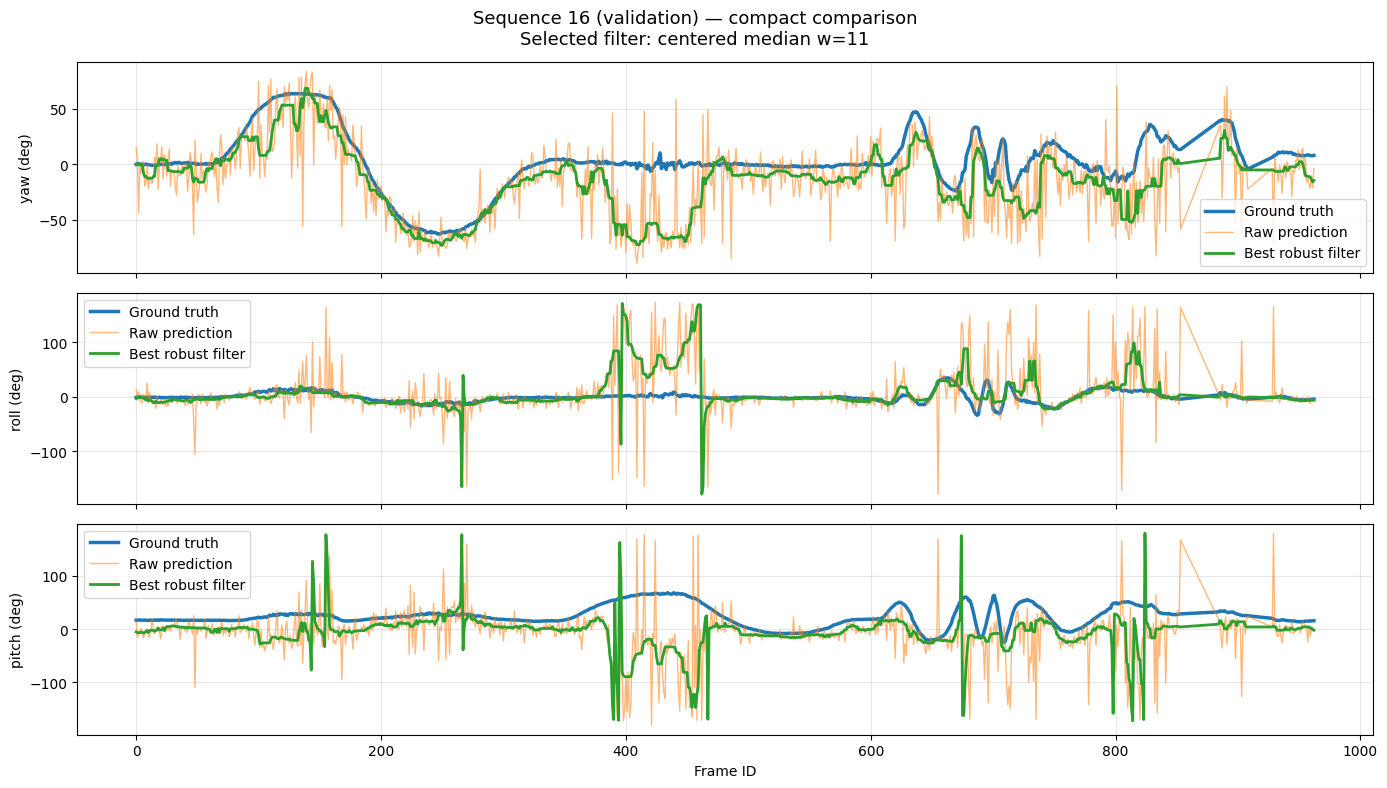

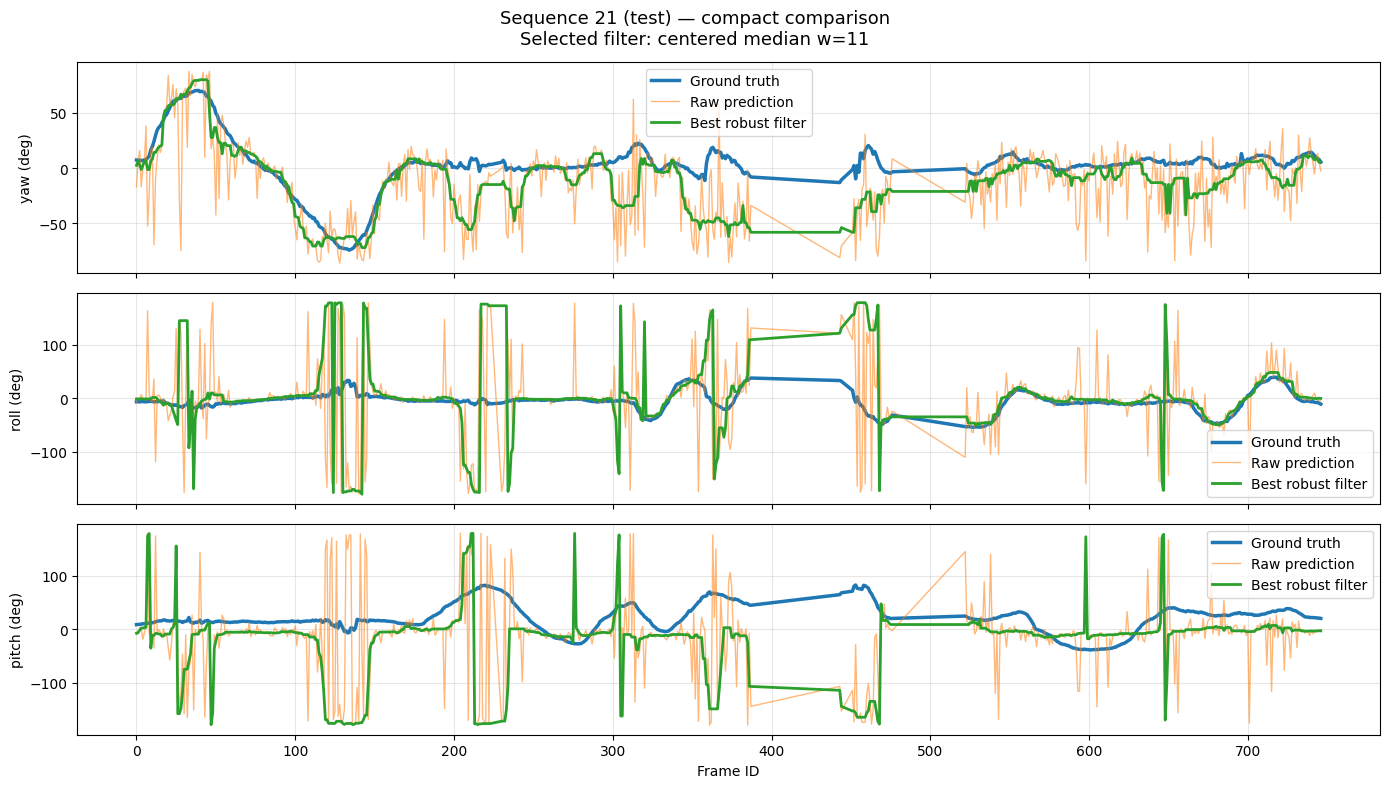

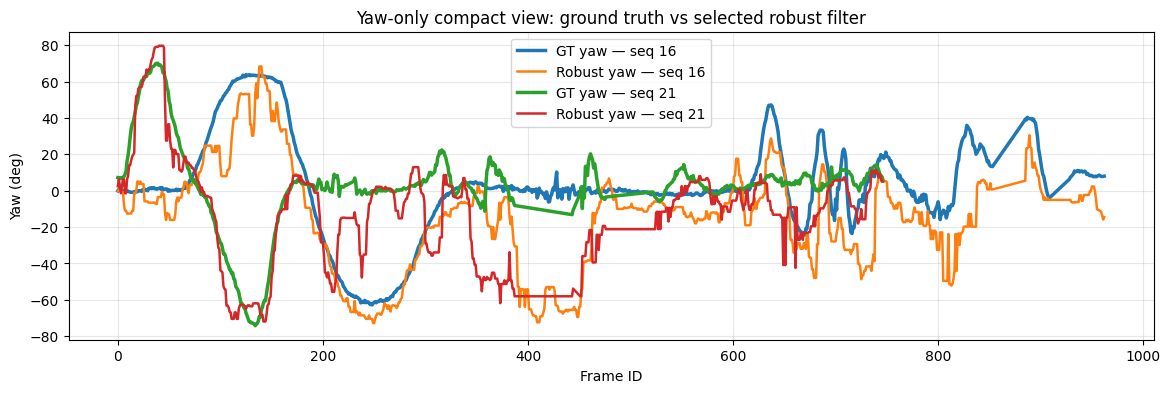

In [142]:
# Appendix C.3: Compact visual inspection of the selected robust filter

# Select the best candidate from validation balanced score if it is not already defined
if "best_robust_candidate_name" not in globals():
    best_robust_candidate_name = validation_search.iloc[0]["candidate"]

print("Selected robust candidate:")
print(best_robust_candidate_name)

# Build a compact table with the most relevant candidates
best_balanced_name = (
    robust_search_results[robust_search_results["split"] == "validation"]
    .sort_values("balanced_score")
    .iloc[0]["candidate"]
)

best_mae_name = (
    robust_search_results[robust_search_results["split"] == "validation"]
    .sort_values("mean_mae")
    .iloc[0]["candidate"]
)

best_temporal_name = (
    robust_search_results[robust_search_results["split"] == "validation"]
    .sort_values("mean_temporal_motion_error")
    .iloc[0]["candidate"]
)

compact_candidate_summary = robust_search_results[
    robust_search_results["candidate"].isin([
        "raw predictions",
        f"original EMA alpha={best_alpha}",
        best_balanced_name,
        best_mae_name,
        best_temporal_name,
    ])
].copy()

compact_candidate_summary = (
    compact_candidate_summary
    .sort_values(["split", "balanced_score", "mean_mae"])
    .reset_index(drop=True)
)

print("\nCompact comparison of relevant candidates:")
display(compact_candidate_summary)

# Build dataframe with selected robust-filter predictions
selected_candidate_df = robust_base_df.copy().sort_values(
    ["sequence_id", "frame_id"]
).reset_index(drop=True)

if best_robust_candidate_name == "raw predictions":
    for angle in ["yaw", "roll", "pitch"]:
        selected_candidate_df[f"bestrobust_pred_{angle}"] = selected_candidate_df[f"pred_{angle}"]

elif best_robust_candidate_name == f"original EMA alpha={best_alpha}":
    for angle in ["yaw", "roll", "pitch"]:
        selected_candidate_df[f"bestrobust_pred_{angle}"] = selected_candidate_df[f"smooth_pred_{angle}"]

else:
    selected_config = None
    
    for config in candidate_configs:
        if config["name"] == best_robust_candidate_name:
            selected_config = config
            break
    
    if selected_config is None:
        raise ValueError(f"Could not find config for candidate: {best_robust_candidate_name}")
    
    robust_tmp = apply_temporal_filter_by_sequence(
        selected_candidate_df,
        method=selected_config["method"],
        params=selected_config["params"],
        output_prefix="bestrobust_pred"
    )
    
    for angle in ["yaw", "roll", "pitch"]:
        selected_candidate_df[f"bestrobust_pred_{angle}"] = robust_tmp[f"bestrobust_pred_{angle}"].values

# Add errors and temporal metrics for the selected robust candidate
selected_candidate_df = add_frame_errors_for_prefix(
    selected_candidate_df,
    pred_prefix="bestrobust_pred",
    error_prefix="bestrobust_err"
)

selected_candidate_temporal_df = compute_temporal_metrics_for_prefix(
    selected_candidate_df,
    pred_prefix="bestrobust_pred"
)

selected_filter_summary = pd.DataFrame([
    summarize_candidate(
        selected_candidate_df,
        selected_candidate_temporal_df,
        pred_prefix="bestrobust_pred",
        error_prefix="bestrobust_err",
        candidate_name=best_robust_candidate_name,
        split_name="validation"
    ),
    summarize_candidate(
        selected_candidate_df,
        selected_candidate_temporal_df,
        pred_prefix="bestrobust_pred",
        error_prefix="bestrobust_err",
        candidate_name=best_robust_candidate_name,
        split_name="test"
    ),
])

print("\nSelected robust filter summary:")
display(selected_filter_summary)

# Compact temporal visualization:
# Only GT, raw prediction and best robust filter are plotted.
# This avoids overcrowding the figures with too many colored lines.

sequence_ids_to_plot = [16, 21]  # validation sequence 16 and test sequence 21

for sequence_id in sequence_ids_to_plot:
    seq_df = selected_candidate_df[
        selected_candidate_df["sequence_id"] == sequence_id
    ].copy().sort_values("frame_id")
    
    if len(seq_df) == 0:
        print(f"No frames found for sequence {sequence_id}")
        continue
    
    split_name = seq_df["split"].iloc[0]
    frame_ids = seq_df["frame_id"].values
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    
    for ax, angle in zip(axes, ["yaw", "roll", "pitch"]):
        ax.plot(
            frame_ids,
            seq_df[angle].values,
            label="Ground truth",
            linewidth=2.5
        )
        ax.plot(
            frame_ids,
            seq_df[f"pred_{angle}"].values,
            label="Raw prediction",
            alpha=0.55,
            linewidth=1.0
        )
        ax.plot(
            frame_ids,
            seq_df[f"bestrobust_pred_{angle}"].values,
            label="Best robust filter",
            linewidth=2.0
        )
        
        ax.set_ylabel(f"{angle} (deg)")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")
    
    axes[-1].set_xlabel("Frame ID")
    
    fig.suptitle(
        f"Sequence {sequence_id} ({split_name}) — compact comparison\n"
        f"Selected filter: {best_robust_candidate_name}",
        fontsize=13
    )
    
    plt.tight_layout()
    plt.show()

# Compact yaw-only plot, because yaw is where the model adds most value
plt.figure(figsize=(14, 4))

for sequence_id in sequence_ids_to_plot:
    seq_df = selected_candidate_df[
        selected_candidate_df["sequence_id"] == sequence_id
    ].copy().sort_values("frame_id")
    
    if len(seq_df) == 0:
        continue
    
    plt.plot(
        seq_df["frame_id"],
        seq_df["yaw"],
        label=f"GT yaw — seq {sequence_id}",
        linewidth=2.5
    )
    plt.plot(
        seq_df["frame_id"],
        seq_df["bestrobust_pred_yaw"],
        label=f"Robust yaw — seq {sequence_id}",
        linewidth=1.8
    )

plt.xlabel("Frame ID")
plt.ylabel("Yaw (deg)")
plt.title("Yaw-only compact view: ground truth vs selected robust filter")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## C.4 Axis-specific robust filtering

The previous robust filtering search applied the same temporal filter to yaw, roll and pitch. However, Appendix B showed that the model behaves differently across axes. The raw model is useful for yaw, but roll and pitch are more affected by fisheye-induced outliers.

We therefore perform a final axis-specific search. The goal is to preserve useful yaw dynamics while stabilizing roll and pitch more aggressively.

All candidate filters are selected using the validation split only. The test split is used only for final evaluation.

Validation circular means used for shrinkage/constant filters:
{'yaw': np.float64(8.901577350299588), 'roll': np.float64(-0.13126947192336208), 'pitch': np.float64(13.093011262652142)}
Number of axis-specific candidates: 144

Top axis-specific candidates by validation balanced score:


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error,balanced_score
0,yaw=centered_median_w11 | roll=validation_mean...,validation,3049,3043,11.604605,9.329161,17.991085,12.974950,1.883512,2.921863,0.618733
1,yaw=centered_median_w7 | roll=validation_mean ...,validation,3049,3043,11.954908,9.329161,17.991085,13.091718,2.618361,3.613894,0.638717
2,yaw=centered_median_w11 | roll=centered_median...,validation,3049,3043,11.604605,9.430763,17.991085,13.008818,3.920916,4.679669,0.658247
3,yaw=centered_median_w5 | roll=validation_mean ...,validation,3049,3043,12.232676,9.329161,17.991085,13.184307,3.668526,4.604917,0.664141
4,yaw=centered_median_w7 | roll=centered_median_...,validation,3049,3043,11.954908,9.430763,17.991085,13.125585,4.608633,5.343012,0.677610
5,yaw=centered_median_w5 | roll=centered_median_...,validation,3049,3043,12.232676,9.430763,17.991085,13.218175,5.569157,6.267036,0.701584
6,yaw=centered_median_w11 | roll=centered_median...,validation,3049,3043,11.604605,12.307999,17.991085,13.967896,4.656755,5.344179,0.713695
7,yaw=centered_median_w11 | roll=validation_mean...,validation,3049,3043,11.604605,9.329161,19.648282,13.527349,5.834465,6.567008,0.721315
8,yaw=centered_median_w7 | roll=centered_median_...,validation,3049,3043,11.954908,12.307999,17.991085,14.084664,5.329046,5.994220,0.732770
9,yaw=centered_median_w7 | roll=validation_mean ...,validation,3049,3043,11.954908,9.329161,19.648282,13.644117,6.468418,7.178007,0.739545



Top axis-specific candidates by validation mean MAE:


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error,balanced_score
0,yaw=centered_median_w11 | roll=validation_mean...,validation,3049,3043,11.604605,9.329161,17.991085,12.974950,1.883512,2.921863,0.618733
1,yaw=centered_median_w11 | roll=centered_median...,validation,3049,3043,11.604605,9.430763,17.991085,13.008818,3.920916,4.679669,0.658247
2,yaw=centered_median_w7 | roll=validation_mean ...,validation,3049,3043,11.954908,9.329161,17.991085,13.091718,2.618361,3.613894,0.638717
3,yaw=centered_median_w7 | roll=centered_median_...,validation,3049,3043,11.954908,9.430763,17.991085,13.125585,4.608633,5.343012,0.677610
4,yaw=centered_median_w5 | roll=validation_mean ...,validation,3049,3043,12.232676,9.329161,17.991085,13.184307,3.668526,4.604917,0.664141
5,yaw=centered_median_w5 | roll=centered_median_...,validation,3049,3043,12.232676,9.430763,17.991085,13.218175,5.569157,6.267036,0.701584
6,yaw=centered_median_w11 | roll=validation_mean...,validation,3049,3043,11.604605,9.329161,19.648282,13.527349,5.834465,6.567008,0.721315
7,yaw=centered_median_w11 | roll=centered_median...,validation,3049,3043,11.604605,9.430763,19.648282,13.561217,7.264824,7.826149,0.750031
8,yaw=centered_median_w7 | roll=validation_mean ...,validation,3049,3043,11.954908,9.329161,19.648282,13.644117,6.468418,7.178007,0.739545
9,yaw=centered_median_w7 | roll=centered_median_...,validation,3049,3043,11.954908,9.430763,19.648282,13.677984,7.876828,8.426909,0.768039



Best axis-specific candidate selected on validation:
yaw=centered_median_w11 | roll=validation_mean | pitch=validation_mean

Appendix C comparison: raw vs EMA vs global robust vs axis-specific robust


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error,balanced_score
0,yaw=centered_median_w11 | roll=validation_mean...,test,12629,12585,11.848100,9.091692,19.986305,13.642032,1.950993,2.955157,0.648011
1,centered median w=11,test,12629,12585,11.848100,14.243855,23.793740,16.628565,7.141341,7.506834,0.874430
2,raw predictions,test,12629,12585,16.992973,21.132519,29.663300,22.596264,44.273643,44.272610,1.926058
3,original EMA alpha=0.05,test,12629,12585,17.729794,26.357604,35.652063,26.579820,4.081540,4.554670,1.236518
4,yaw=centered_median_w11 | roll=validation_mean...,validation,3049,3043,11.604605,9.329161,17.991085,12.974950,1.883512,2.921863,0.618733
5,centered median w=11,validation,3049,3043,11.604605,15.695054,27.656942,18.318867,9.831589,10.208957,1.005306
6,raw predictions,validation,3049,3043,16.389506,21.885331,31.801848,23.358895,46.223222,46.179548,2.000000
7,original EMA alpha=0.05,validation,3049,3043,16.440476,31.269845,47.858935,31.856419,5.907936,6.420065,1.502805



Selected axis-specific robust filter summary:


,candidate,split,num_frames,num_pairs,mae_yaw,mae_roll,mae_pitch,mean_mae,mean_jitter,mean_temporal_motion_error
0,yaw=centered_median_w11 | roll=validation_mean...,validation,3049,3043,11.604605,9.329161,17.991085,12.974950,1.883512,2.921863
1,yaw=centered_median_w11 | roll=validation_mean...,test,12629,12585,11.848100,9.091692,19.986305,13.642032,1.950993,2.955157


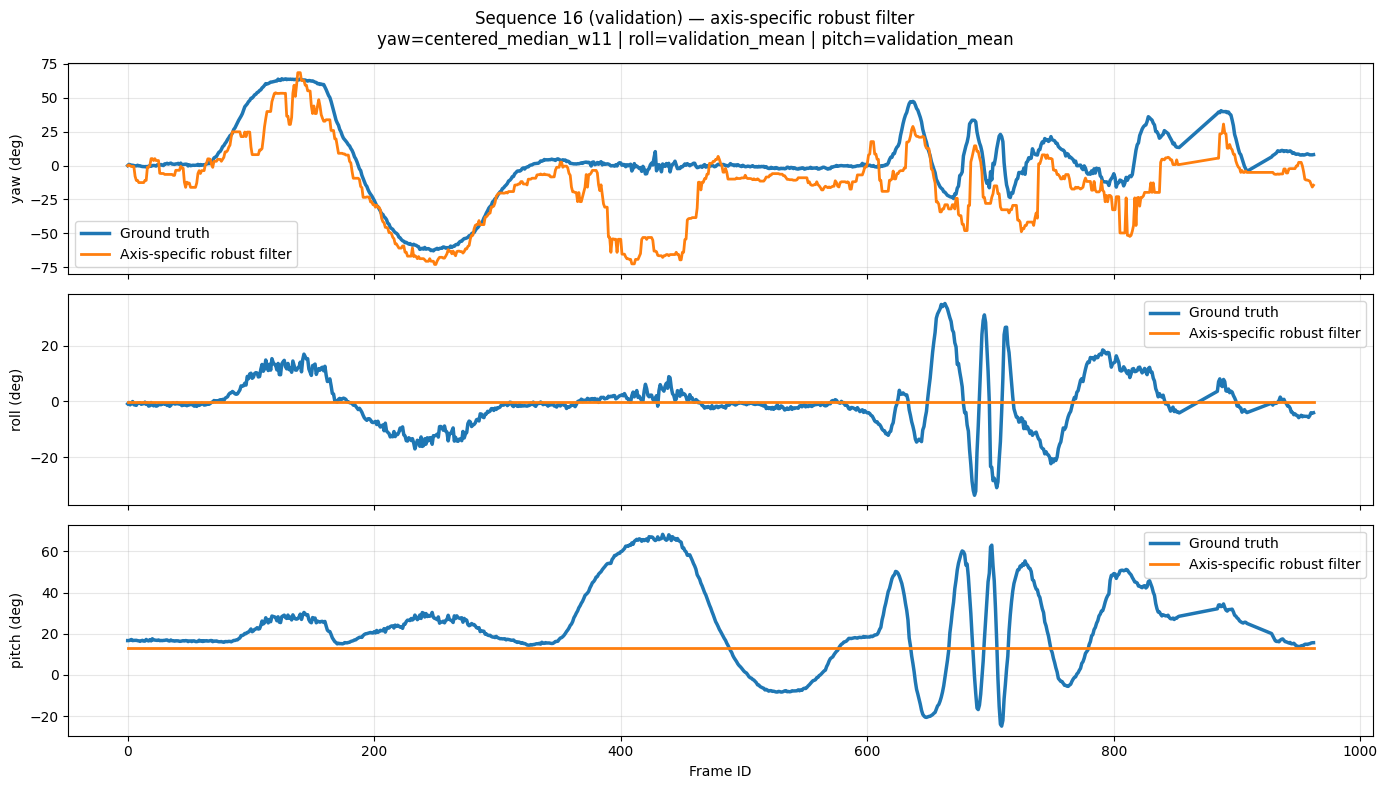

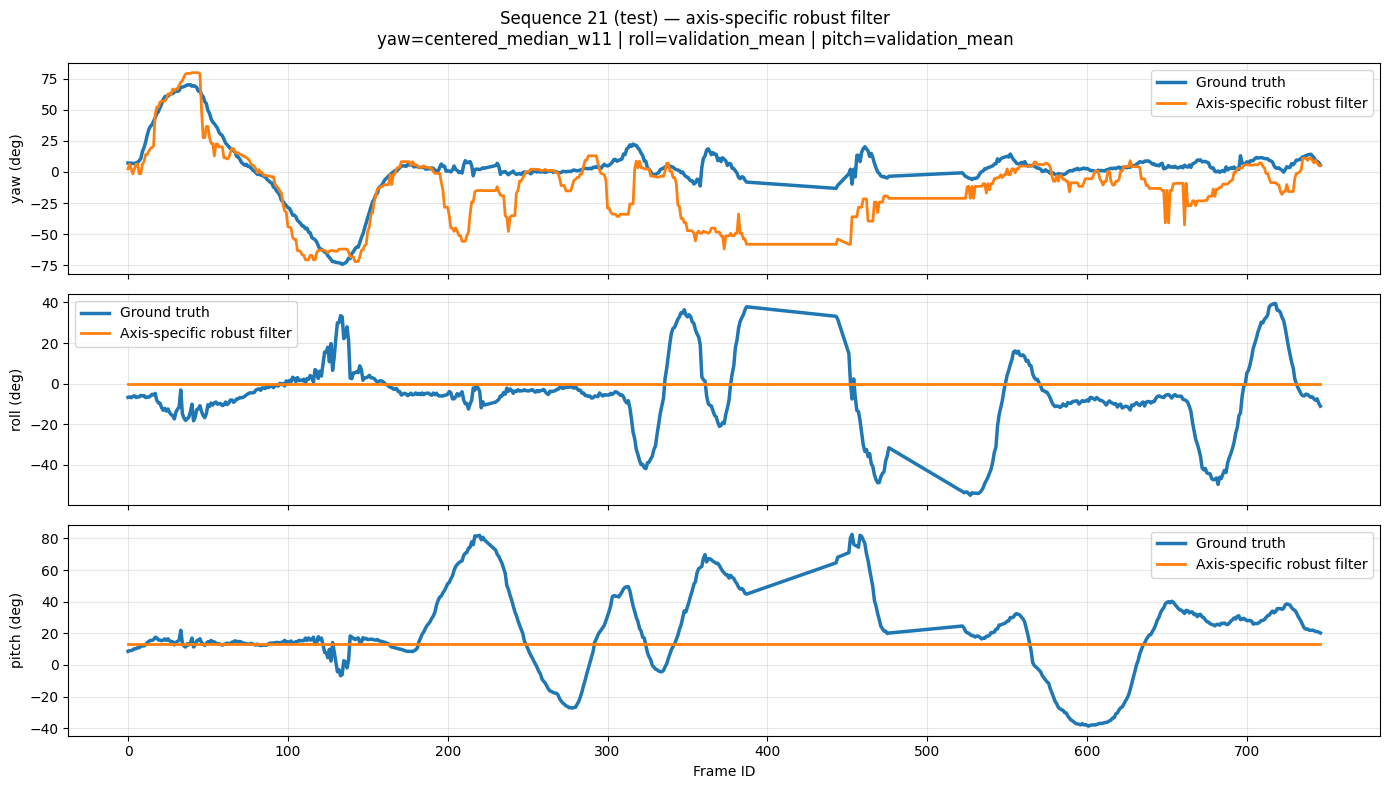

In [143]:
# Appendix C.4: Axis-specific robust filtering search

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Small helper functions for axis-specific filtering
# -------------------------------------------------------------------

def circular_mean_deg(values):
    values_rad = np.deg2rad(values)
    return np.rad2deg(
        np.arctan2(np.mean(np.sin(values_rad)), np.mean(np.cos(values_rad)))
    )

def shrink_angles_towards_mean_deg(values, mean_angle, shrink_strength):
    """
    Circular shrinkage towards a constant mean angle.
    shrink_strength = 0.0 keeps the values unchanged.
    shrink_strength = 1.0 collapses all values to the mean angle.
    """
    delta = signed_circular_diff_deg(values, mean_angle)
    return wrap_angle_deg(mean_angle + (1.0 - shrink_strength) * delta)

def apply_single_axis_filter(seq_df, angle, filter_name, validation_means):
    """
    Apply one axis-specific filter to one sequence and one angle.
    Uses predictions only, except for validation_mean, which is estimated
    from the validation split and then applied as a constant baseline.
    """
    raw_values = seq_df[f"pred_{angle}"].values.astype(float)
    unwrapped = unwrap_angle_sequence_deg(raw_values)

    if filter_name == "raw":
        filtered = unwrapped

    elif filter_name == "centered_median_w5":
        filtered = rolling_median_1d(unwrapped, window_size=5, centered=True)

    elif filter_name == "centered_median_w7":
        filtered = rolling_median_1d(unwrapped, window_size=7, centered=True)

    elif filter_name == "centered_median_w11":
        filtered = rolling_median_1d(unwrapped, window_size=11, centered=True)

    elif filter_name == "centered_median_w11_ema05":
        median_values = rolling_median_1d(unwrapped, window_size=11, centered=True)
        filtered = ema_1d(median_values, alpha=0.5)

    elif filter_name == "centered_median_w11_shrink025":
        median_values = rolling_median_1d(unwrapped, window_size=11, centered=True)
        filtered = shrink_angles_towards_mean_deg(
            wrap_angle_deg(median_values),
            validation_means[angle],
            shrink_strength=0.25
        )

    elif filter_name == "centered_median_w11_shrink050":
        median_values = rolling_median_1d(unwrapped, window_size=11, centered=True)
        filtered = shrink_angles_towards_mean_deg(
            wrap_angle_deg(median_values),
            validation_means[angle],
            shrink_strength=0.50
        )

    elif filter_name == "validation_mean":
        filtered = np.full_like(raw_values, validation_means[angle], dtype=float)

    else:
        raise ValueError(f"Unknown filter name: {filter_name}")

    return wrap_angle_deg(filtered)

def apply_axis_specific_filter(dataframe, axis_config, output_prefix, validation_means):
    """
    Apply a different filter to yaw, roll and pitch independently.
    """
    out = dataframe.sort_values(["sequence_id", "frame_id"]).copy()

    for angle in ["yaw", "roll", "pitch"]:
        out[f"{output_prefix}_{angle}"] = np.nan

    for sequence_id, seq_df in out.groupby("sequence_id"):
        idx = seq_df.index

        for angle in ["yaw", "roll", "pitch"]:
            filtered = apply_single_axis_filter(
                seq_df,
                angle=angle,
                filter_name=axis_config[angle],
                validation_means=validation_means
            )

            out.loc[idx, f"{output_prefix}_{angle}"] = filtered

    return out

def axis_config_name(axis_config):
    return (
        f"yaw={axis_config['yaw']} | "
        f"roll={axis_config['roll']} | "
        f"pitch={axis_config['pitch']}"
    )

# -------------------------------------------------------------------
# Validation means estimated only from the validation split
# -------------------------------------------------------------------

axis_base_df = final_smoothed_df.copy()

validation_df_for_axis = axis_base_df[axis_base_df["split"] == "validation"].copy()

validation_means = {
    "yaw": circular_mean_deg(validation_df_for_axis["yaw"]),
    "roll": circular_mean_deg(validation_df_for_axis["roll"]),
    "pitch": circular_mean_deg(validation_df_for_axis["pitch"]),
}

print("Validation circular means used for shrinkage/constant filters:")
print(validation_means)

# -------------------------------------------------------------------
# Candidate space
# -------------------------------------------------------------------

# Yaw gets less aggressive options because Appendix B showed
# that the model adds useful yaw information.
yaw_filter_options = [
    "raw",
    "centered_median_w5",
    "centered_median_w7",
    "centered_median_w11",
]

# Roll and pitch get more aggressive options because they are more unstable.
roll_filter_options = [
    "centered_median_w7",
    "centered_median_w11",
    "centered_median_w11_ema05",
    "centered_median_w11_shrink025",
    "centered_median_w11_shrink050",
    "validation_mean",
]

pitch_filter_options = [
    "centered_median_w7",
    "centered_median_w11",
    "centered_median_w11_ema05",
    "centered_median_w11_shrink025",
    "centered_median_w11_shrink050",
    "validation_mean",
]

axis_candidate_configs = []

for yaw_filter, roll_filter, pitch_filter in itertools.product(
    yaw_filter_options,
    roll_filter_options,
    pitch_filter_options
):
    axis_candidate_configs.append({
        "yaw": yaw_filter,
        "roll": roll_filter,
        "pitch": pitch_filter,
    })

print("Number of axis-specific candidates:", len(axis_candidate_configs))

# -------------------------------------------------------------------
# Search
# -------------------------------------------------------------------

axis_search_rows = []

for axis_config in axis_candidate_configs:
    candidate_name = axis_config_name(axis_config)

    candidate_df = apply_axis_specific_filter(
        axis_base_df,
        axis_config=axis_config,
        output_prefix="axisrobust_pred",
        validation_means=validation_means
    )

    candidate_df = add_frame_errors_for_prefix(
        candidate_df,
        pred_prefix="axisrobust_pred",
        error_prefix="axisrobust_err"
    )

    candidate_temporal_df = compute_temporal_metrics_for_prefix(
        candidate_df,
        pred_prefix="axisrobust_pred"
    )

    for split_name in ["validation", "test"]:
        axis_search_rows.append(
            summarize_candidate(
                candidate_df,
                candidate_temporal_df,
                pred_prefix="axisrobust_pred",
                error_prefix="axisrobust_err",
                candidate_name=candidate_name,
                split_name=split_name
            )
        )

axis_search_results = pd.DataFrame(axis_search_rows)

# Normalization against raw validation values
raw_validation_row = robust_search_results[
    (robust_search_results["split"] == "validation") &
    (robust_search_results["candidate"] == "raw predictions")
].iloc[0]

raw_val_mae = raw_validation_row["mean_mae"]
raw_val_temporal_error = raw_validation_row["mean_temporal_motion_error"]

axis_search_results["balanced_score"] = (
    axis_search_results["mean_mae"] / raw_val_mae +
    axis_search_results["mean_temporal_motion_error"] / raw_val_temporal_error
)

axis_validation_search = (
    axis_search_results[axis_search_results["split"] == "validation"]
    .sort_values("balanced_score")
    .reset_index(drop=True)
)

best_axis_candidate_name = axis_validation_search.iloc[0]["candidate"]

print("\nTop axis-specific candidates by validation balanced score:")
display(axis_validation_search.head(15))

print("\nTop axis-specific candidates by validation mean MAE:")
display(
    axis_search_results[axis_search_results["split"] == "validation"]
    .sort_values("mean_mae")
    .head(15)
    .reset_index(drop=True)
)

print("\nBest axis-specific candidate selected on validation:")
print(best_axis_candidate_name)

# -------------------------------------------------------------------
# Compare selected axis-specific filter with previous methods
# -------------------------------------------------------------------

comparison_names = [
    "raw predictions",
    f"original EMA alpha={best_alpha}",
    best_robust_candidate_name,
    best_axis_candidate_name,
]

previous_comparison = robust_search_results[
    robust_search_results["candidate"].isin([
        "raw predictions",
        f"original EMA alpha={best_alpha}",
        best_robust_candidate_name,
    ])
].copy()

axis_selected_comparison = axis_search_results[
    axis_search_results["candidate"] == best_axis_candidate_name
].copy()

final_c_comparison = pd.concat(
    [previous_comparison, axis_selected_comparison],
    ignore_index=True
).sort_values(["split", "mean_mae"]).reset_index(drop=True)

print("\nAppendix C comparison: raw vs EMA vs global robust vs axis-specific robust")
display(final_c_comparison)

# -------------------------------------------------------------------
# Build prediction table for selected axis-specific candidate
# -------------------------------------------------------------------

selected_axis_config = None

for config in axis_candidate_configs:
    if axis_config_name(config) == best_axis_candidate_name:
        selected_axis_config = config
        break

if selected_axis_config is None:
    raise ValueError("Selected axis-specific config was not found.")

axis_selected_df = apply_axis_specific_filter(
    axis_base_df,
    axis_config=selected_axis_config,
    output_prefix="axisbest_pred",
    validation_means=validation_means
)

axis_selected_df = add_frame_errors_for_prefix(
    axis_selected_df,
    pred_prefix="axisbest_pred",
    error_prefix="axisbest_err"
)

axis_selected_temporal_df = compute_temporal_metrics_for_prefix(
    axis_selected_df,
    pred_prefix="axisbest_pred"
)

axis_selected_summary = pd.DataFrame([
    summarize_candidate(
        axis_selected_df,
        axis_selected_temporal_df,
        pred_prefix="axisbest_pred",
        error_prefix="axisbest_err",
        candidate_name=best_axis_candidate_name,
        split_name="validation"
    ),
    summarize_candidate(
        axis_selected_df,
        axis_selected_temporal_df,
        pred_prefix="axisbest_pred",
        error_prefix="axisbest_err",
        candidate_name=best_axis_candidate_name,
        split_name="test"
    ),
])

print("\nSelected axis-specific robust filter summary:")
display(axis_selected_summary)

# -------------------------------------------------------------------
# Compact visualization
# Only GT and selected axis-specific robust filter are plotted.
# This avoids overcrowded figures.
# -------------------------------------------------------------------

sequence_ids_to_plot = [16, 21]

for sequence_id in sequence_ids_to_plot:
    seq_df = axis_selected_df[
        axis_selected_df["sequence_id"] == sequence_id
    ].copy().sort_values("frame_id")

    if len(seq_df) == 0:
        print(f"No frames found for sequence {sequence_id}")
        continue

    split_name = seq_df["split"].iloc[0]
    frame_ids = seq_df["frame_id"].values

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    for ax, angle in zip(axes, ["yaw", "roll", "pitch"]):
        ax.plot(
            frame_ids,
            seq_df[angle],
            label="Ground truth",
            linewidth=2.5
        )
        ax.plot(
            frame_ids,
            seq_df[f"axisbest_pred_{angle}"],
            label="Axis-specific robust filter",
            linewidth=2.0
        )

        ax.set_ylabel(f"{angle} (deg)")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best")

    axes[-1].set_xlabel("Frame ID")

    fig.suptitle(
        f"Sequence {sequence_id} ({split_name}) — axis-specific robust filter\n"
        f"{best_axis_candidate_name}",
        fontsize=12
    )

    plt.tight_layout()
    plt.show()

## C.5 Appendix C conclusion

The robust temporal filtering pilot shows that post-processing can substantially improve the BIWI-360 results, but only when it is designed according to the failure analysis.

The best global robust filter selected on validation was a centered temporal median with window size 11. This filter improved the test mean MAE from 22.60 degrees for raw predictions to 16.63 degrees, while also reducing the mean temporal motion error from 44.27 to 7.51 degrees per frame. This confirms that many of the raw prediction failures are temporally inconsistent outliers that can be reduced with robust filtering.

However, the best overall result was obtained by an axis-specific hybrid filter. This filter uses a centered median filter for yaw, while replacing roll and pitch with their validation-set circular means. On the test split, this reduced mean MAE to 13.64 degrees and reduced temporal motion error to 2.96 degrees per frame.

This result should be interpreted carefully. The axis-specific filter is not a pure temporal smoothing method for all angles. Instead, it exploits the observation from Appendix B that the model is useful mainly for yaw, while roll and pitch are dominated by fisheye-induced outliers and are better approximated by stable constants. Since the constants are estimated only from the validation split, this is not test leakage, but it is still a strong dataset-specific post-processing strategy.

The result supports a nuanced conclusion. Zero-shot 6DRepNet360 is not reliable as a direct frame-by-frame estimator on BIWI-360, especially for roll and pitch. Nevertheless, its yaw predictions contain useful pose information. A robust axis-specific post-processing strategy can preserve this useful yaw signal while suppressing unstable roll and pitch predictions.

Overall, Appendix C confirms that simple EMA is not the best temporal strategy for this setting. More robust post-processing, especially median filtering and axis-specific treatment, gives a much better accuracy-stability trade-off. Future work should replace this hand-designed hybrid rule with a learned or confidence-aware temporal model, ideally trained or fine-tuned on fisheye-distorted data.